# Santander Customer Satisfaction

## 1. 프로젝트 목적

Santander 고객 데이터를 활용하여 고객 만족도(TARGET)를 분석하고,
불만족 고객의 특성을 탐색한 후 예측 모델을 구축한다.

### 주요 질문

1. 만족 고객과 불만족 고객의 특성에는 어떤 차이가 있는가?
2. 고객 불만족과 관련된 주요 변수는 무엇인가?
3. 불만족 고객을 사전에 예측할 수 있는가?

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [12]:
# 버전확인
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.2.6


In [13]:
# 데이터 불러오기
cust_df = pd.read_csv("../세미파이널/data/train.csv", encoding='latin-1')
cust_df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [14]:
cust_df.shape

(76020, 371)

In [15]:
# 데이터 기본 정보
cust_df.info()
# 변수 개수, 데이터 타입, 결측치, 메모리 사용량 확인
# 관측치 수 76,020 개
# 전체 변수 수 371개
# 변수 범위 ID~target
# float64 변수 111개
# int64 변수 260개
# 메모리 사용량 215.2MB 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [16]:
cust_df.dtypes.value_counts()
# 대부분 int64, float64 형식

int64      260
float64    111
Name: count, dtype: int64

In [17]:
#  Target 데이터 확인
cust_df["TARGET"].value_counts()

TARGET
0    73012
1     3008
Name: count, dtype: int64

In [18]:
# target 비율 확인
cust_df["TARGET"].value_counts(normalize=True)

TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64

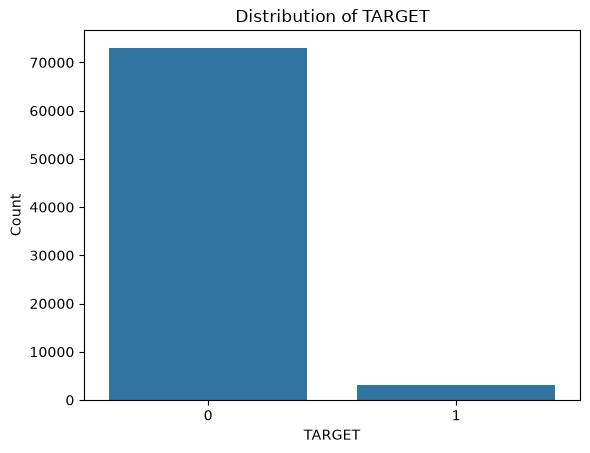

In [19]:
# 시각화
sns.countplot(data=cust_df, x="TARGET")

plt.title("Distribution of TARGET")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

In [20]:
# 결측치 확인
missing = cust_df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [21]:
missing_rate = cust_df.isnull().mean() * 100

missing_rate[missing_rate > 0].sort_values(ascending=False)

Series([], dtype: float64)

In [22]:
# 전체 결측치 0개
cust_df.isnull().sum().sum()

np.int64(0)

In [23]:
# 중복 데이터 확인
cust_df.duplicated().sum()

np.int64(0)

In [24]:
# 고유값 개수 확인
nunique = cust_df.nunique().sort_values()

nunique.head(20)

ind_var27_0                  1
ind_var27                    1
ind_var28                    1
ind_var28_0                  1
ind_var46                    1
ind_var41                    1
ind_var46_0                  1
imp_reemb_var33_hace3        1
imp_amort_var34_hace3        1
num_var41                    1
imp_amort_var18_hace3        1
num_var28_0                  1
num_var27                    1
imp_trasp_var33_out_hace3    1
imp_trasp_var17_out_hace3    1
num_var2_0_ult1              1
num_var2_ult1                1
num_var27_0                  1
num_var28                    1
num_trasp_var33_out_hace3    1
dtype: int64

In [25]:
# 분산 0 변수 확인
constant_cols = cust_df.nunique()[cust_df.nunique() == 1]

constant_cols

ind_var2_0                       1
ind_var2                         1
ind_var27_0                      1
ind_var28_0                      1
ind_var28                        1
ind_var27                        1
ind_var41                        1
ind_var46_0                      1
ind_var46                        1
num_var27_0                      1
num_var28_0                      1
num_var28                        1
num_var27                        1
num_var41                        1
num_var46_0                      1
num_var46                        1
saldo_var28                      1
saldo_var27                      1
saldo_var41                      1
saldo_var46                      1
imp_amort_var18_hace3            1
imp_amort_var34_hace3            1
imp_reemb_var13_hace3            1
imp_reemb_var33_hace3            1
imp_trasp_var17_out_hace3        1
imp_trasp_var33_out_hace3        1
num_var2_0_ult1                  1
num_var2_ult1                    1
num_reemb_var13_hace

In [26]:
len(constant_cols)

34

In [27]:
# 원본 데이터 보존
df_clean = cust_df.copy()

# 상수 변수 제거
constant_cols = df_clean.columns[df_clean.nunique() == 1]

df_clean = df_clean.drop(columns=constant_cols)

print("제거 전 데이터 크기:", cust_df.shape)
print("제거 후 데이터 크기:", df_clean.shape)

제거 전 데이터 크기: (76020, 371)
제거 후 데이터 크기: (76020, 337)


In [28]:
# 기술통계량 확인
df_clean['ID'].describe()

count     76020.000000
mean      75964.050723
std       43781.947379
min           1.000000
25%       38104.750000
50%       76043.000000
75%      113748.750000
max      151838.000000
Name: ID, dtype: float64

In [29]:
df_clean["ID"].nunique()

76020

In [30]:
# 따라서 id 제거 = > 고유한 값을 가지기 때문

In [31]:
# ID 변수 제거
df_clean = df_clean.drop(columns="ID")

print(df_clean.shape)

(76020, 336)


In [32]:
df_clean.shape

(76020, 336)

In [33]:
summary = df_clean.describe().T

summary.sort_values('min').head(20)

,count,mean,std,min,25%,50%,75%,max
var3,76020.0,-1.523199e+03,3.903346e+04,-999999.00,2.0,2.00,2.0000,2.380000e+02
saldo_var8,76020.0,1.412268e+02,2.515656e+03,-4942.26,0.0,0.00,0.0000,2.400450e+05
saldo_var42,76020.0,7.191725e+03,4.914531e+04,-4942.26,0.0,3.00,120.0000,3.008077e+06
saldo_var30,76020.0,1.367967e+04,6.301408e+04,-4942.26,0.0,3.00,235.9950,3.458077e+06
saldo_medio_var8_ult1,76020.0,1.246210e+02,2.205250e+03,-3401.34,0.0,0.00,0.0000,2.280318e+05
saldo_var5,76020.0,1.028468e+03,9.852140e+03,-2895.72,0.0,3.00,90.0000,6.193292e+05
saldo_medio_var8_ult3,76020.0,1.100266e+02,1.935306e+03,-1844.52,0.0,0.00,0.0000,1.775820e+05
saldo_medio_var5_ult1,76020.0,1.077257e+03,9.614907e+03,-922.38,0.0,3.00,90.0000,6.014286e+05
saldo_medio_var5_ult3,76020.0,1.048856e+03,8.189949e+03,-476.07,0.0,2.73,83.7900,5.443656e+05
saldo_medio_var8_hace2,76020.0,6.827545e+01,1.733838e+03,-287.67,0.0,0.00,0.0000,2.313520e+05


In [34]:
# var3가 의심스럽기에 var3확인

In [35]:
cust_df["var3"].value_counts().head(10)

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
 1           105
 13           98
 7            97
 4            86
 12           85
Name: count, dtype: int64

In [36]:
# var3가 -999999인 데이터가 많기에 결측을 나타내려고 사용한 특수 코드

In [37]:
pd.crosstab(
    cust_df["var3"] == -999999,
    cust_df["TARGET"],
    normalize="index"
)

TARGET,0,1
var3,,
False,0.960397,0.039603
True,0.982759,0.017241


In [38]:
# var3인 고객은 불만족 고객 비율이 낮다.
# 삭제하면 정보 손실이 발생할 수 있기에 NaN 처리 
df_clean["var3"] = df_clean["var3"].replace(-999999, np.nan)

In [39]:
# 산탄데르 안에 포함된 -999999 변수 찾기
# NaN변환 했기에 안나오는게 맞음
special_value_counts = (df_clean == -999999).sum()

special_value_counts[special_value_counts > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [40]:
# 원본 데이터 
special_value_counts = (cust_df == -999999).sum()

special_value_counts[special_value_counts > 0].sort_values(ascending=False)

var3    116
dtype: int64

In [41]:
# NaN 개수
df_clean["var3"].isnull().sum()

np.int64(116)

In [42]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

var3    116
dtype: int64

In [43]:
# var3 결측이라는 새 변수 생성
df_clean["var3_missing"] = df_clean["var3"].isna().astype(int)

In [44]:
# var3 결측처리한 값 중앙값 대체
df_clean["var3"] = df_clean["var3"].fillna(
    df_clean["var3"].median()
)

In [45]:
df_clean["var3_missing"].value_counts()

var3_missing
0    75904
1      116
Name: count, dtype: int64

In [46]:
# 이상치 탐색 (왜도)
skewness = df_clean.drop(columns="TARGET").skew().sort_values(ascending=False)

skewness.head(20)

num_trasp_var33_out_ult1         275.717246
num_reemb_var33_ult1             275.717246
imp_reemb_var33_ult1             275.717246
num_reemb_var17_hace3            275.717246
delta_num_aport_var33_1y3        275.717246
delta_imp_aport_var33_1y3        275.717246
delta_num_reemb_var33_1y3        275.717246
delta_imp_reemb_var33_1y3        275.717246
saldo_medio_var29_hace3          275.717246
imp_trasp_var33_out_ult1         275.717246
imp_reemb_var17_hace3            275.717246
delta_num_trasp_var33_out_1y3    275.717246
delta_imp_trasp_var33_out_1y3    275.717246
saldo_medio_var17_hace3          273.677797
imp_aport_var17_hace3            273.673938
saldo_var18                      271.904104
saldo_var1                       271.724084
imp_amort_var18_ult1             270.332246
saldo_medio_var17_hace2          269.334571
saldo_var17                      258.440513
dtype: float64

In [47]:
skewness.tail(20)

ind_var9_cte_ult1            2.725940
ind_var43_recib_ult1         2.209564
var15                        1.578367
num_var35                    1.302883
num_var4                     1.045042
var36                        0.426879
num_var30                    0.273769
num_var42                   -0.339927
num_var39_0                 -0.378306
num_var5                    -0.620356
num_var41_0                 -0.633122
ind_var5                    -0.693290
num_meses_var5_ult3         -0.702865
ind_var30                   -1.052423
num_meses_var39_vig_ult3    -1.366315
ind_var41_0                 -2.328360
ind_var39_0                 -2.349831
num_var5_0                  -2.679003
ind_var5_0                  -4.568139
ind_var30_0                -14.786677
dtype: float64

In [48]:
col = "num_trasp_var33_out_ult1"

df_clean[col].describe()

count    76020.000000
mean         0.000039
std          0.010881
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: num_trasp_var33_out_ult1, dtype: float64

In [49]:
df_clean[col].value_counts().head(20)
# 극희소값 

num_trasp_var33_out_ult1
0    76019
3        1
Name: count, dtype: int64

In [50]:
pd.crosstab(df_clean[col], df_clean["TARGET"])
# 3인 고객이 만족이기에 유용한 신호라 보기 어려움

TARGET,0,1
num_trasp_var33_out_ult1,,
0,73011,3008
3,1,0


In [51]:
# 희소변수를 찾는 코드
feature_cols = df_clean.drop(columns="TARGET").columns

zero_ratio = (df_clean[feature_cols] == 0).mean().sort_values(ascending=False)

zero_ratio.head(20)

saldo_medio_var29_hace3          0.999987
num_reemb_var33_ult1             0.999987
delta_num_trasp_var33_out_1y3    0.999987
delta_imp_trasp_var33_out_1y3    0.999987
delta_imp_reemb_var33_1y3        0.999987
delta_num_reemb_var33_1y3        0.999987
imp_trasp_var33_out_ult1         0.999987
imp_reemb_var33_ult1             0.999987
imp_reemb_var17_hace3            0.999987
num_reemb_var17_hace3            0.999987
num_trasp_var33_out_ult1         0.999987
saldo_medio_var13_medio_ult3     0.999974
num_var18                        0.999974
saldo_medio_var13_medio_hace2    0.999974
num_var18_0                      0.999974
ind_var34                        0.999974
saldo_var13_medio                0.999974
ind_var6                         0.999974
num_meses_var13_medio_ult3       0.999974
saldo_medio_var13_medio_ult1     0.999974
dtype: float64

In [52]:
target_ratio = df_clean["TARGET"].value_counts(normalize=True) * 100
target_ratio

TARGET
0    96.043147
1     3.956853
Name: proportion, dtype: float64

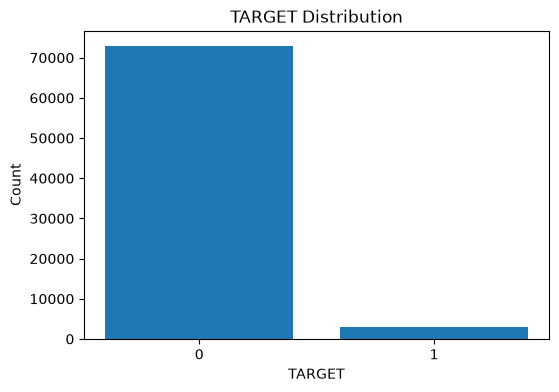

In [53]:
import matplotlib.pyplot as plt

target_counts = df_clean["TARGET"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)

plt.xlabel("TARGET")
plt.ylabel("Count")
plt.title("TARGET Distribution")

plt.show()

# TARGET의 분포를 확인한 결과, 전체 고객 중 TARGET=0은 96.04%,
#  TARGET=1은 3.96%로 나타나 상당한 클래스 불균형이 존재하였다. 
# 따라서 이후 모델링에서는 Accuracy만으로 성능을 평가하는 것은 적절하지 않으며, 
# 불균형 데이터에 적합한 ROC-AUC, PR-AUC, Recall, Precision 및 F1-score 등을 함께 활용한다.

In [54]:
# 이진 변수
# 연속형 변수
# 희소 변수
# 고왜도 변수

In [55]:
# 고유값 개수
nunique = df_clean.drop(columns="TARGET").nunique()

nunique.describe()

count      336.000000
mean       781.636905
std       3907.134513
min          2.000000
25%          2.000000
50%          5.000000
75%         50.250000
max      57736.000000
dtype: float64

In [56]:
nunique = df_clean.drop(columns="TARGET").nunique()

print("고유값 2개:", (nunique == 2).sum())
print("고유값 3~10개:", ((nunique >= 3) & (nunique <= 10)).sum())
print("고유값 11~100개:", ((nunique >= 11) & (nunique <= 100)).sum())
print("고유값 101개 이상:", (nunique > 100).sum())

고유값 2개: 106
고유값 3~10개: 99
고유값 11~100개: 66
고유값 101개 이상: 65


In [57]:
nunique[nunique == 2].index.tolist()[:20]

['ind_var1_0',
 'ind_var1',
 'ind_var5_0',
 'ind_var5',
 'ind_var6_0',
 'ind_var6',
 'ind_var8_0',
 'ind_var8',
 'ind_var12_0',
 'ind_var12',
 'ind_var13_0',
 'ind_var13_corto_0',
 'ind_var13_corto',
 'ind_var13_largo_0',
 'ind_var13_largo',
 'ind_var13_medio_0',
 'ind_var13_medio',
 'ind_var13',
 'ind_var14_0',
 'ind_var14']

### 변수구조
                    전체 설명변수
                         │
          ┌──────────────┼──────────────┐
          ↓              ↓              ↓
       이진 변수      저유일 변수      연속형 변수
       0 / 1          3~100개          100개 이상
          │              │              │
       ind_var       일부 num_var      saldo / imp 등

### 질문 1. 어떤 고객 특성이 TARGET = 1(불만족) 과 관련이 있는가

In [58]:
nunique = df_clean.drop(columns="TARGET").nunique()

binary_cols = nunique[nunique == 2].index.tolist()

print("이진 변수 개수:", len(binary_cols))

이진 변수 개수: 106


In [59]:
binary_eda = []

for col in binary_cols:
    temp = df_clean.groupby(col)["TARGET"].agg(
        count="count",
        dissatisfied_rate="mean"
    ).reset_index()

    for _, row in temp.iterrows():
        binary_eda.append({
            "variable": col,
            "value": row[col],
            "count": row["count"],
            "dissatisfied_rate": row["dissatisfied_rate"]
        })

binary_eda = pd.DataFrame(binary_eda)

In [60]:
# value 1만 추출
binary_target_rate = binary_eda[
    binary_eda["value"] == 1
].copy()

In [61]:
# 표본이 100명 이상인 변수만 비교
binary_target_rate = binary_target_rate[
    binary_target_rate["count"] >= 100
]

In [62]:
# 불만족률 TOP20
# dissatisfield_rate 0.08 => ind_var8_0 변수 고객 중 약 8%가 TARGET=1
binary_target_rate.sort_values(
    "dissatisfied_rate",
    ascending=False
).head(20)

,variable,value,count,dissatisfied_rate
13,ind_var8_0,1.0,2496.0,0.088942
15,ind_var8,1.0,2174.0,0.071297
111,ind_var39,1.0,283.0,0.070671
107,ind_var40,1.0,283.0,0.070671
3,ind_var1,1.0,286.0,0.069930
59,ind_var25_cte,1.0,2009.0,0.067198
63,ind_var26_cte,1.0,2095.0,0.066826
67,ind_var25_0,1.0,1797.0,0.063996
69,ind_var25,1.0,1797.0,0.063996
61,ind_var26_0,1.0,1873.0,0.063001


In [63]:
# 상대적인 위험도
# 단순 불만족률 보다 전체 평균 대비 몇 배 높은지 확인
overall_rate = df_clean["TARGET"].mean()

binary_target_rate["relative_risk"] = (
    binary_target_rate["dissatisfied_rate"] / overall_rate
)

binary_target_rate.sort_values(
    "relative_risk",
    ascending=False
).head(20)

,variable,value,count,dissatisfied_rate,relative_risk
13,ind_var8_0,1.0,2496.0,0.088942,2.247804
15,ind_var8,1.0,2174.0,0.071297,1.801865
111,ind_var39,1.0,283.0,0.070671,1.786050
107,ind_var40,1.0,283.0,0.070671,1.786050
3,ind_var1,1.0,286.0,0.069930,1.767315
59,ind_var25_cte,1.0,2009.0,0.067198,1.698259
63,ind_var26_cte,1.0,2095.0,0.066826,1.688862
67,ind_var25_0,1.0,1797.0,0.063996,1.617334
69,ind_var25,1.0,1797.0,0.063996,1.617334
61,ind_var26_0,1.0,1873.0,0.063001,1.592188


전체 고객의 불만족률은 3.96%였으나, 일부 이진 변수에서는 해당 변수의 값이 1인 고객의 불만족률이 상대적으로 높게 나타났다. 특히 ind_var8_0은 값이 1인 고객 2,496명 중 약 8.89%가 불만족 고객으로 나타나 전체 불만족률보다 약 2.25배 높은 수준을 보였다. 이는 해당 변수와 고객 불만족 간 연관 가능성을 시사하지만, 단변량 분석 결과만으로 인과관계를 판단할 수 없으므로 이후 다변량 모델링을 통해 추가적으로 검증할 필요가 있다.

In [64]:
#  차이가 있는지 검정
# 카이제곱 검정
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_clean["ind_var8_0"],
    df_clean["TARGET"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 164.20575643311588
p-value: 1.3639963335401472e-37


In [65]:
# 귀무가설 H₀: ind_var8_0과 TARGET은 서로 독립이다.
# p-value = 1.36 × 10⁻³⁷ 이므로 귀무가설 기각
# 따라서 ind_var8_o 과 고객 만족도 사이에 통계적으로 유의한 연관성이 있다.

In [66]:
# 효과 크기 계산
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    df_clean["ind_var8_0"],
    df_clean["TARGET"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Cramér's V:", cramers_v)

Chi-square: 164.20575643311588
p-value: 1.3639963335401472e-37
Cramér's V: 0.046476161937365854


In [67]:
# 효과크기가 작음
# 통계적으로 유의하긴 하지만 연관성의 크기 자체는 크지 않다.

결론 ind_var8_0은 고객 불만족과 통계적으로 유의한 연관성을 보였으며, 해당 변수가 1인 고객의 불만족률은 전체 평균보다 약 2.25배 높았다. 그러나 Cramér's V가 0.0465로 나타나 변수와 TARGET 간의 연관성의 크기는 크지 않은 것으로 판단된다.

In [68]:
# 다른 변수 또한 진행
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

binary_results = []

for col in binary_cols:
    table = pd.crosstab(df_clean[col], df_clean["TARGET"])

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / n)

    # 값이 1인 고객의 불만족률
    if 1 in table.index:
        count_1 = table.loc[1].sum()
        dissatisfied_1 = table.loc[1, 1] if 1 in table.columns else 0
        rate_1 = dissatisfied_1 / count_1
    else:
        count_1 = 0
        rate_1 = np.nan

    binary_results.append({
        "variable": col,
        "n_value_1": count_1,
        "dissatisfied_rate": rate_1,
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v
    })

binary_stats = pd.DataFrame(binary_results)

In [69]:
# 효과크기가 큰 변수부터 확인
binary_stats.sort_values(
    "cramers_v",
    ascending=False
).head(20)

,variable,n_value_1,dissatisfied_rate,chi2,p_value,cramers_v
38,ind_var30,55710,0.021935,1704.395117,0.000000e+00,0.149734
3,ind_var5,50459,0.020789,1391.157614,1.753487e-304,0.135277
6,ind_var8_0,2496,0.088942,164.205756,1.363996e-37,0.046476
17,ind_var13,3866,0.006208,118.360263,1.445898e-27,0.039458
10,ind_var13_0,3972,0.006798,117.526025,2.201918e-27,0.039319
8,ind_var12_0,5133,0.011884,110.238324,8.689042e-26,0.038080
51,ind_var39_0,66955,0.037055,92.811706,5.751395e-22,0.034941
12,ind_var13_corto,3153,0.007295,89.274820,3.436048e-21,0.034269
11,ind_var13_corto_0,3264,0.007966,88.761538,4.453920e-21,0.034170
9,ind_var12,3456,0.008970,88.359110,5.458762e-21,0.034093


In [70]:
# 불만족률이 높은 것과 TARGET과의 연관성이 큰 것은 같은 개념이 아니다.
# ind_var30 을 보면 가장 높은 효과 크기를 가지고 있다.
# 표본 또한 전체 데이터의 약 73%를 차지하고 있다. 
# 따라서 특정 소수 고객에게만 나타나는 변수가 아니라 많은 고객에게 존재하는 특성이라고 볼 수 있다. 
# 하지만 변수가=1 인 고객의 불만족률은 2.19% 이고 전체평균 (3.96%) 보다 낮다.
# 따라서 이 변수는 오히려 고객에서 ind_var30 =1 인 고객에서 불만족률이 낮아지는 방향의 강한 연관성을 가질 가능성이 있다.


In [71]:
for col in ["ind_var30", "ind_var5", "ind_var8_0"]:
    print(f"\n===== {col} =====")
    
    result = pd.crosstab(
        df_clean[col],
        df_clean["TARGET"],
        normalize="index"
    ) * 100
    
    print(result)


===== ind_var30 =====
TARGET             0         1
ind_var30                     
0          91.206302  8.793698
1          97.806498  2.193502

===== ind_var5 =====
TARGET            0         1
ind_var5                     
0         92.335981  7.664019
1         97.921084  2.078916

===== ind_var8_0 =====
TARGET              0         1
ind_var8_0                     
0           96.210761  3.789239
1           91.105769  8.894231


In [72]:
# ind_var30=1인 고객은 0인 고객보다 불만족률이 약 75% 낮다.
# 마찬가지로 ind_var5=1인 고객에서 불만족률이 상당히 낮다.
# ind_var8_0=1일 때 불만족률이 훨씬 높다. 

In [73]:
# ind_var30 의 효과크기가 높은 이유
# 변수 안 0,1 두 그룹의 차이가 상당히 크고, 1인 고객 또한 55,710이 존재하기 때문

이진 변수와 고객 만족도 간의 관계를 분석하기 위해 카이제곱 독립성 검정과 Cramér's V를 활용하였다. 분석 결과 ind_var30과 ind_var5는 TARGET과 통계적으로 유의한 연관성을 보였으며, 각각의 Cramér's V는 0.150과 0.135로 나타났다. 특히 두 변수 모두 해당 변수가 1인 고객의 불만족률이 0인 고객보다 크게 낮게 나타났다. 반면 ind_var8_0은 변수값이 1인 고객의 불만족률이 8.89%로 전체 평균 3.96%보다 크게 높았으나, Cramér's V는 0.046으로 상대적으로 낮았다. 이를 통해 통계적 유의성뿐 아니라 효과크기와 표본 규모를 함께 고려할 필요가 있음을 확인하였다.

In [74]:
# 연속형 변수 처리 
# 1. 연속형 변수 선정
feature_cols = df_clean.drop(columns="TARGET").columns

nunique = df_clean[feature_cols].nunique()

continuous_cols = nunique[nunique > 10].index.tolist()

print("연속형 변수 후보:", len(continuous_cols))

연속형 변수 후보: 131


In [75]:
# Mann-Whitney U 검정
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

continuous_results = []

for col in continuous_cols:
    
    group0 = df_clean.loc[df_clean["TARGET"] == 0, col].dropna()
    group1 = df_clean.loc[df_clean["TARGET"] == 1, col].dropna()
    
    # 두 그룹 중 하나가 값이 없거나 동일한 경우 제외
    if len(group0) == 0 or len(group1) == 0:
        continue
    
    u_stat, p_value = mannwhitneyu(
        group0,
        group1,
        alternative="two-sided"
    )
    
    # Rank-biserial correlation
    n0 = len(group0)
    n1 = len(group1)
    
    rank_biserial = 1 - (2 * u_stat) / (n0 * n1)
    
    continuous_results.append({
        "variable": col,
        "median_target0": group0.median(),
        "median_target1": group1.median(),
        "mean_target0": group0.mean(),
        "mean_target1": group1.mean(),
        "p_value": p_value,
        "rank_biserial": rank_biserial
    })

continuous_stats = pd.DataFrame(continuous_results)

In [76]:
#  효과크기가 큰 변수 확인
continuous_stats["abs_effect"] = (
    continuous_stats["rank_biserial"].abs()
)

continuous_stats.sort_values(
    "abs_effect",
    ascending=False
).head(20)

,variable,median_target0,median_target1,mean_target0,mean_target1,p_value,rank_biserial,abs_effect
1,var15,27.00,38.00,32.946406,39.680519,2.147072e-305,0.397280,0.397280
50,saldo_var30,3.00,0.00,14154.089498,2164.364721,5.672663e-286,-0.381658,0.381658
56,saldo_var42,3.00,0.00,7435.742356,1268.797769,5.370136e-245,-0.352087,0.352087
38,saldo_var5,3.00,0.00,1056.727458,342.543231,9.620590e-244,-0.348432,0.348432
98,saldo_medio_var5_hace2,3.00,0.00,1628.647567,377.343830,3.473307e-238,-0.346346,0.346346
100,saldo_medio_var5_ult1,3.00,0.00,1107.830596,335.149967,1.602023e-235,-0.343242,0.343242
101,saldo_medio_var5_ult3,2.76,0.00,1080.422776,282.659362,1.382146e-231,-0.343002,0.343002
99,saldo_medio_var5_hace3,1.05,0.00,923.548332,110.213467,7.277792e-224,-0.332773,0.332773
33,num_var35,3.00,0.00,3.344122,2.213098,1.888756e-181,-0.285209,0.285209
130,var38,107207.82,86219.97,117959.156918,99678.280590,9.853829e-54,-0.165152,0.165152


In [77]:
# p-value는 작고 var15는 target=1 중앙값 38, target=0 중앙값 27로 나타남
# 또한 효과크기도 0.397로 크다.
# 특히 이건 단순히 평균만 다른 게 아니라 분포의 위치 자체가 상당히 다를 가능성이 있다는 게 Mann–Whitney 분석의 장점이다.

In [78]:
# saldo_var30은 반대 방향 TARGET=0 중앙값 = 3 TARGET=1 중앙값 = 0
# 효과크기 = -0.382

In [79]:
# p-value가 너무 작기에 여러 가설을 동시에 검정하면 다중비교 문제가 발생한다, 
# Benjamini-Hochberg 절차를 적용하여 다중검정으로 인한 FDR을 통제한다

import numpy as np

p_values = continuous_stats["p_value"].values

m = len(p_values)

order = np.argsort(p_values)
sorted_p = p_values[order]

adjusted = sorted_p * m / np.arange(1, m + 1)

# 뒤에서부터 누적 최솟값 적용
adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]

# 최대 1로 제한
adjusted = np.minimum(adjusted, 1)

# 원래 순서로 복원
p_adjusted = np.empty(m)
p_adjusted[order] = adjusted

continuous_stats["p_adjusted"] = p_adjusted

In [80]:
continuous_stats.sort_values(
    "abs_effect",
    ascending=False
).head(20)

,variable,median_target0,median_target1,mean_target0,mean_target1,p_value,rank_biserial,abs_effect,p_adjusted
1,var15,27.00,38.00,32.946406,39.680519,2.147072e-305,0.397280,0.397280,2.812664e-303
50,saldo_var30,3.00,0.00,14154.089498,2164.364721,5.672663e-286,-0.381658,0.381658,3.715594e-284
56,saldo_var42,3.00,0.00,7435.742356,1268.797769,5.370136e-245,-0.352087,0.352087,2.344959e-243
38,saldo_var5,3.00,0.00,1056.727458,342.543231,9.620590e-244,-0.348432,0.348432,3.150743e-242
98,saldo_medio_var5_hace2,3.00,0.00,1628.647567,377.343830,3.473307e-238,-0.346346,0.346346,9.100063e-237
100,saldo_medio_var5_ult1,3.00,0.00,1107.830596,335.149967,1.602023e-235,-0.343242,0.343242,3.497751e-234
101,saldo_medio_var5_ult3,2.76,0.00,1080.422776,282.659362,1.382146e-231,-0.343002,0.343002,2.586588e-230
99,saldo_medio_var5_hace3,1.05,0.00,923.548332,110.213467,7.277792e-224,-0.332773,0.332773,1.191738e-222
33,num_var35,3.00,0.00,3.344122,2.213098,1.888756e-181,-0.285209,0.285209,2.749190e-180
130,var38,107207.82,86219.97,117959.156918,99678.280590,9.853829e-54,-0.165152,0.165152,1.290852e-52


In [81]:
(continuous_stats["p_adjusted"] < 0.05).sum()

np.int64(62)

In [82]:
significant_continuous = continuous_stats[
    continuous_stats["p_adjusted"] < 0.05
].copy()

significant_continuous = significant_continuous.sort_values(
    "abs_effect",
    ascending=False
)

significant_continuous.head(20)

,variable,median_target0,median_target1,mean_target0,mean_target1,p_value,rank_biserial,abs_effect,p_adjusted
1,var15,27.00,38.00,32.946406,39.680519,2.147072e-305,0.397280,0.397280,2.812664e-303
50,saldo_var30,3.00,0.00,14154.089498,2164.364721,5.672663e-286,-0.381658,0.381658,3.715594e-284
56,saldo_var42,3.00,0.00,7435.742356,1268.797769,5.370136e-245,-0.352087,0.352087,2.344959e-243
38,saldo_var5,3.00,0.00,1056.727458,342.543231,9.620590e-244,-0.348432,0.348432,3.150743e-242
98,saldo_medio_var5_hace2,3.00,0.00,1628.647567,377.343830,3.473307e-238,-0.346346,0.346346,9.100063e-237
100,saldo_medio_var5_ult1,3.00,0.00,1107.830596,335.149967,1.602023e-235,-0.343242,0.343242,3.497751e-234
101,saldo_medio_var5_ult3,2.76,0.00,1080.422776,282.659362,1.382146e-231,-0.343002,0.343002,2.586588e-230
99,saldo_medio_var5_hace3,1.05,0.00,923.548332,110.213467,7.277792e-224,-0.332773,0.332773,1.191738e-222
33,num_var35,3.00,0.00,3.344122,2.213098,1.888756e-181,-0.285209,0.285209,2.749190e-180
130,var38,107207.82,86219.97,117959.156918,99678.280590,9.853829e-54,-0.165152,0.165152,1.290852e-52


특정 변수군(saldo_var5 계열)이 반복적으로 높은 효과크기를 보여 특정 금융 잔액 관련 특성이 TARGET과 강한 연관성을 가질 가능성을 확인. 다만 변수 간 정보 중복 가능성이 존재하므로 이후 모델링 단계에서는 상관관계 및 변수 중요도를 추가적으로 검토한다.

In [83]:
# var15 와 saldo_var30 의 절대값 효과크기가 가장 높음으로 두 변수를 서로 다른 방향의 대표 사례로 본다.

이미지 저장 완료: figures\eda_box_var15.png


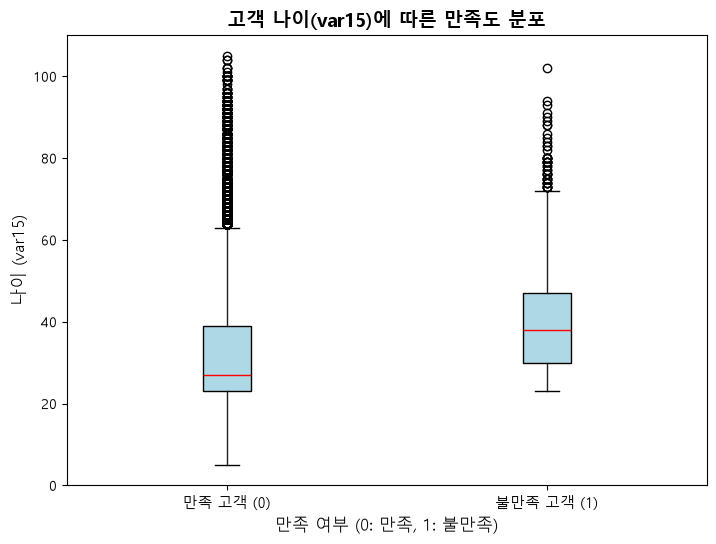

In [199]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 1. 한글 폰트 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 박스플롯 그리기 (fig, ax 객체를 명시적으로 받아옵니다)
fig, ax = plt.subplots(figsize=(8, 6))

df_clean.boxplot(
    column="var15",
    by="TARGET",
    ax=ax,  # 명시적으로 ax 지정
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red')
)

# 한글 타이틀 및 레이블 설정
plt.title("고객 나이(var15)에 따른 만족도 분포", fontsize=14, fontweight='bold')
plt.suptitle("")  # pandas 자체 suptitle 제거
plt.xlabel("만족 여부 (0: 만족, 1: 불만족)", fontsize=12)
plt.ylabel("나이 (var15)", fontsize=12)
plt.xticks([1, 2], ['만족 고객 (0)', '불만족 고객 (1)'], fontsize=11)

# 4. figures 폴더에 이미지 한 번에 저장
save_path = os.path.join(output_dir, 'eda_box_var15.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"이미지 저장 완료: {save_path}")

plt.show()

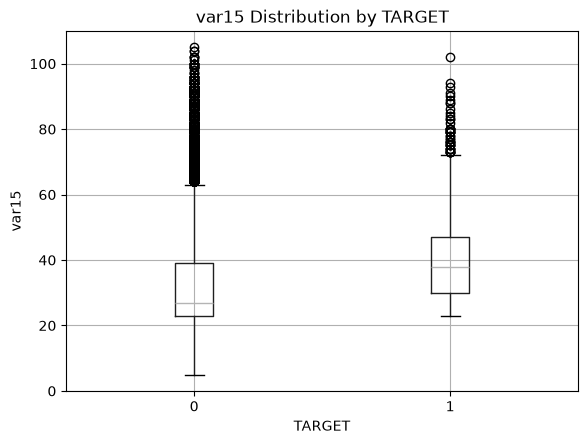

In [84]:
#  변수 시각화 var15
import matplotlib.pyplot as plt

df_clean.boxplot(
    column="var15",
    by="TARGET"
)

plt.title("var15 Distribution by TARGET")
plt.suptitle("")
plt.xlabel("TARGET")
plt.ylabel("var15")

plt.show()

C:\Users\mega\AppData\Local\Temp\ipykernel_16716\559081042.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mega\AppData\Local\Temp\ipykernel_16716\559081042.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['만족 고객 (0)', '불만족 고객 (1)'], fontsize=11)


고품격 이미지 저장 완료: figures\eda_box_saldo_var30_pro.png


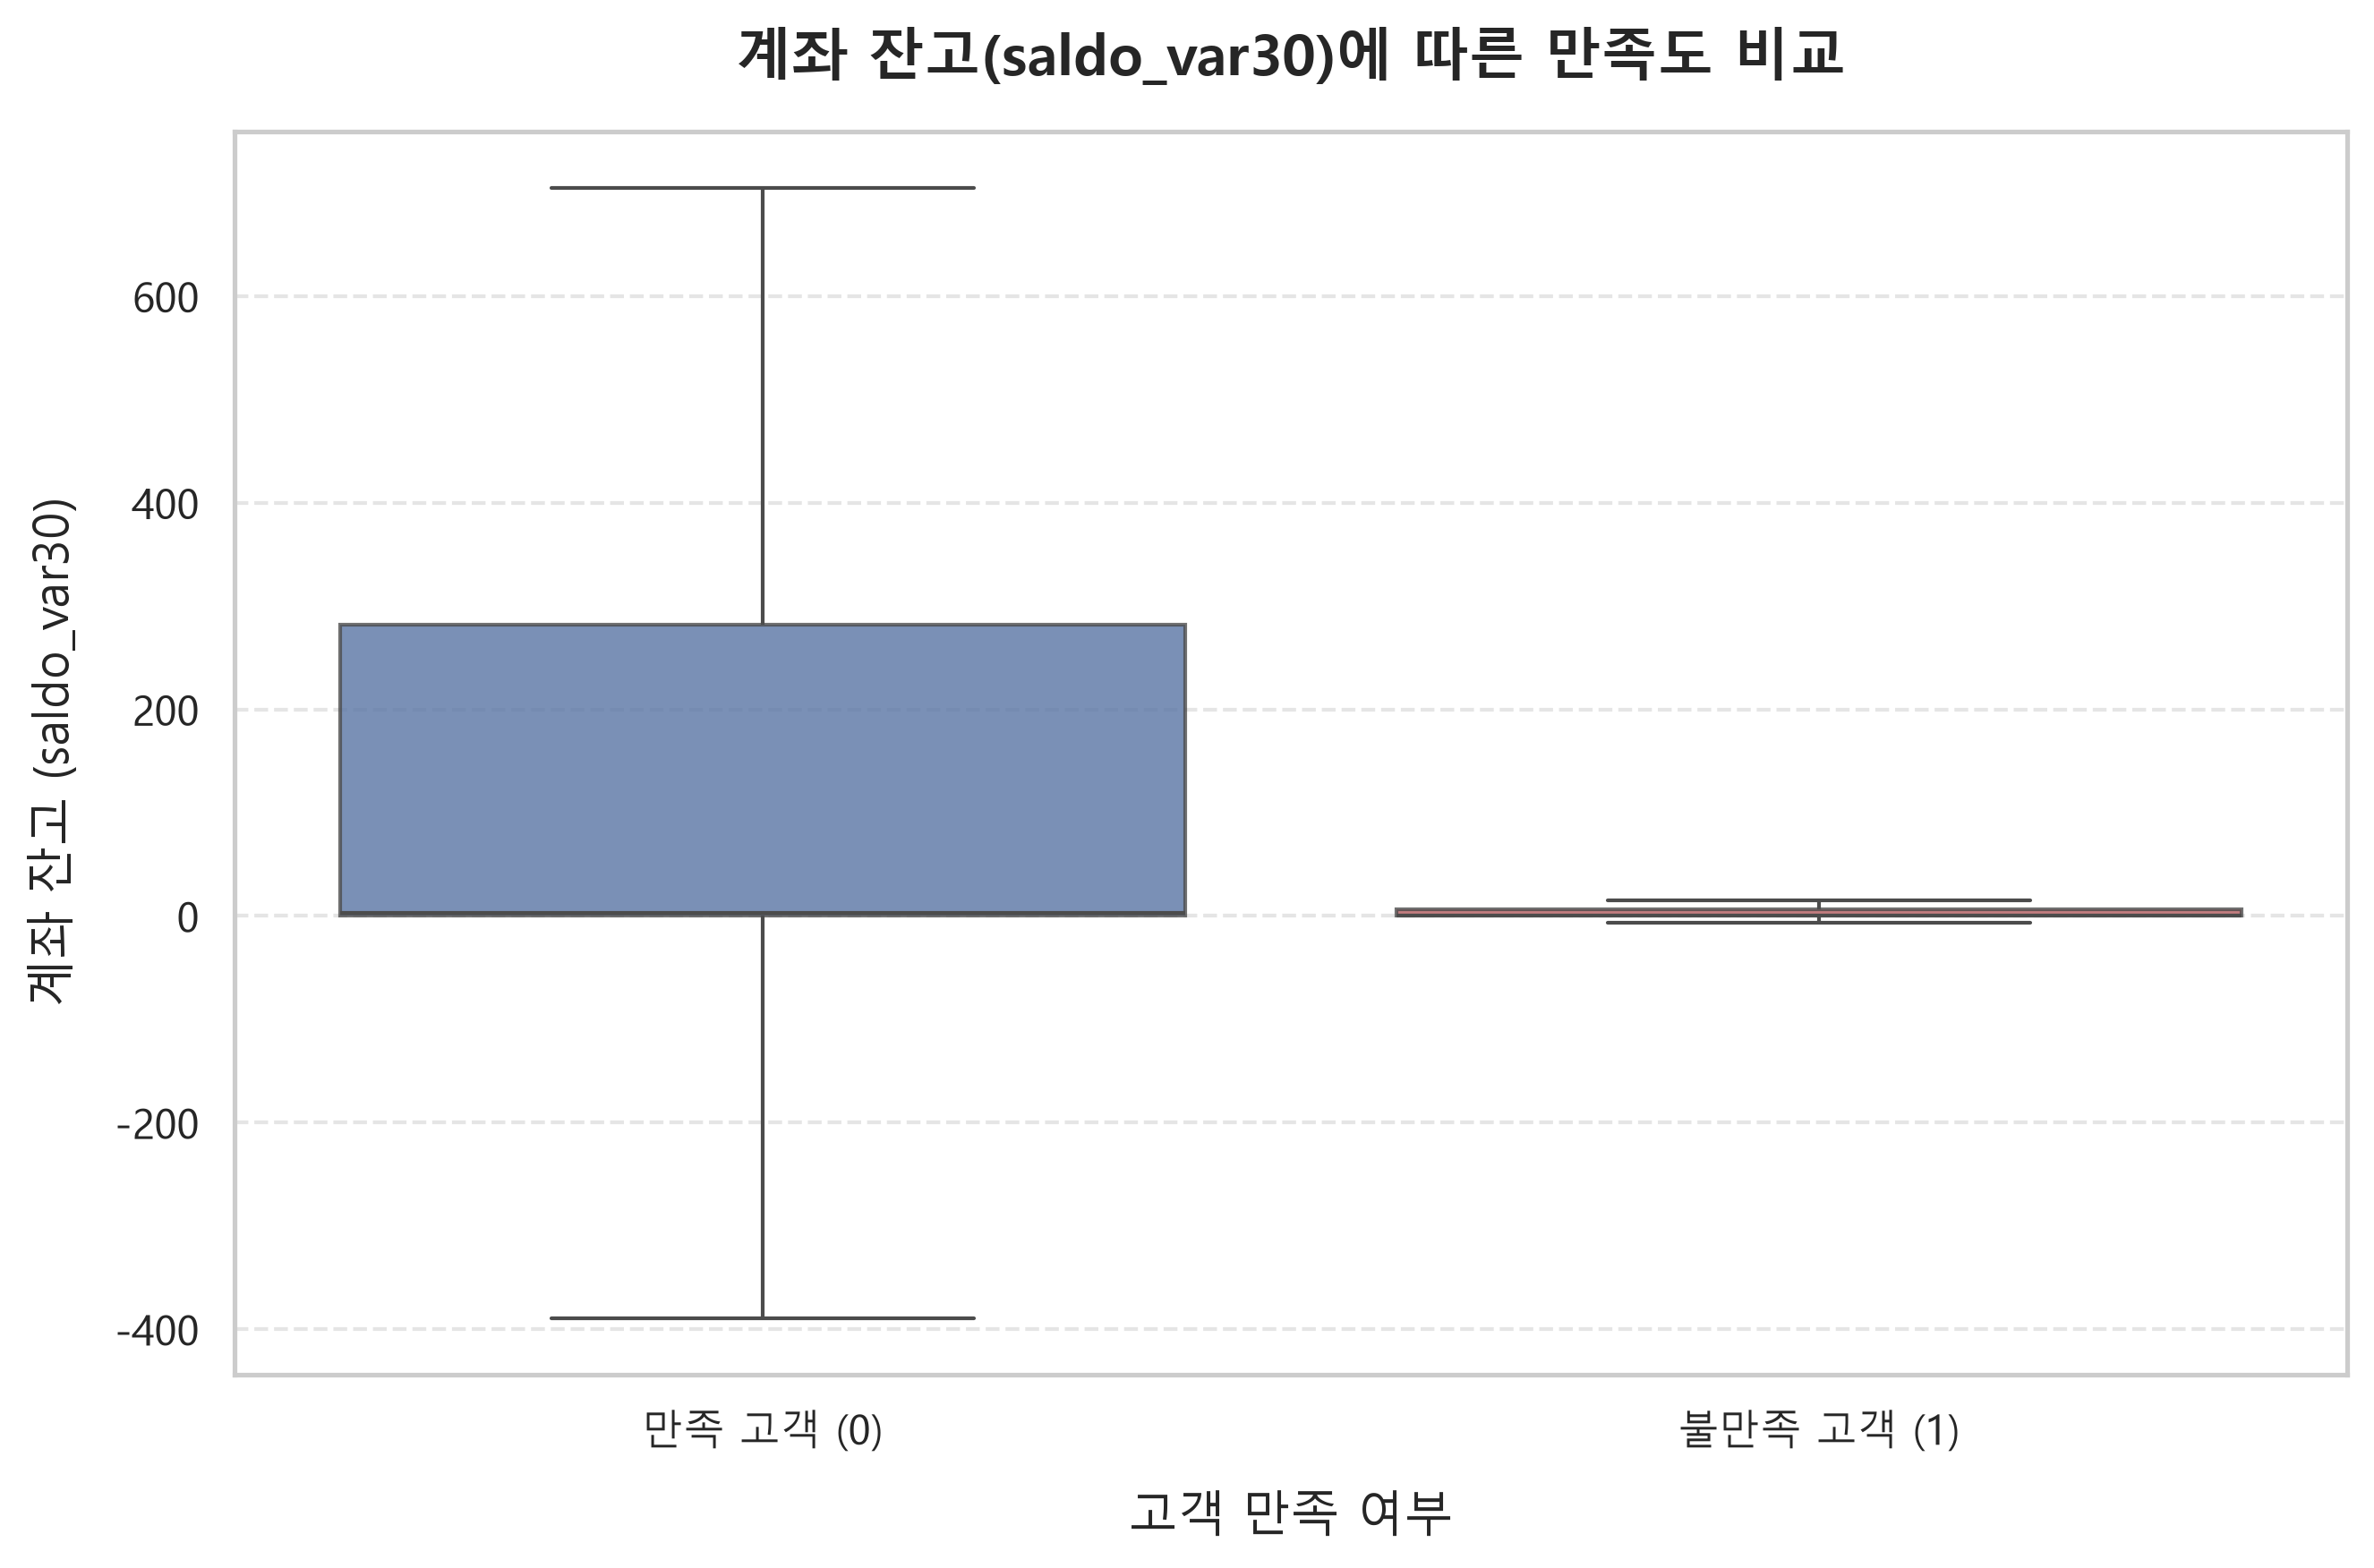

In [202]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import os

# 1. 폰트 및 마이너스 기호 깨짐 방지 설정 (시스템에 맞게 재정의)
mpl.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# 2. Seaborn 테마 적용 (이후에 폰트가 풀릴 수 있으므로 폰트 설정을 다시 잡아줌)
sns.set_theme(style="whitegrid")
mpl.rcParams['font.family'] = 'Malgun Gothic'

# 3. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 4. 도화지 생성 및 시각화
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

sns.boxplot(
    data=df_clean, 
    x='TARGET', 
    y='saldo_var30', 
    ax=ax,
    palette=['#4C72B0', '#C44E52'],
    boxprops=dict(alpha=0.8),
    showfliers=False # 극단적 이상치 숨김
)

# 타이틀 및 레이블 설정
ax.set_title("계좌 잔고(saldo_var30)에 따른 만족도 비교", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("고객 만족 여부", fontsize=13, labelpad=10)
ax.set_ylabel("계좌 잔고 (saldo_var30)", fontsize=13, labelpad=10)

# X축 레이블 지정
ax.set_xticklabels(['만족 고객 (0)', '불만족 고객 (1)'], fontsize=11)

# 배경 격자선
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 5. figures 폴더에 고해상도 저장
save_path = os.path.join(output_dir, 'eda_box_saldo_var30_pro.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"고품격 이미지 저장 완료: {save_path}")

plt.tight_layout()
plt.show()

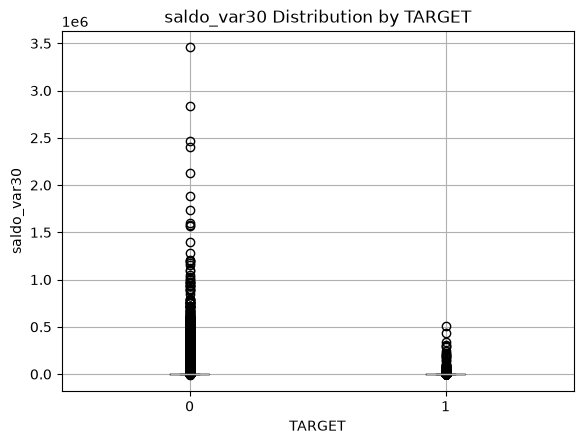

In [85]:
# 변수 시각화 saldo_var30
df_clean.boxplot(
    column="saldo_var30",
    by="TARGET"
)

plt.title("saldo_var30 Distribution by TARGET")
plt.suptitle("")
plt.xlabel("TARGET")
plt.ylabel("saldo_var30")

plt.show()

In [86]:
#  산탄데르는 극단값이 심한 변수가 많기에 boxplot을 그렸을 때 박스가 거의 안보이기도 한다.

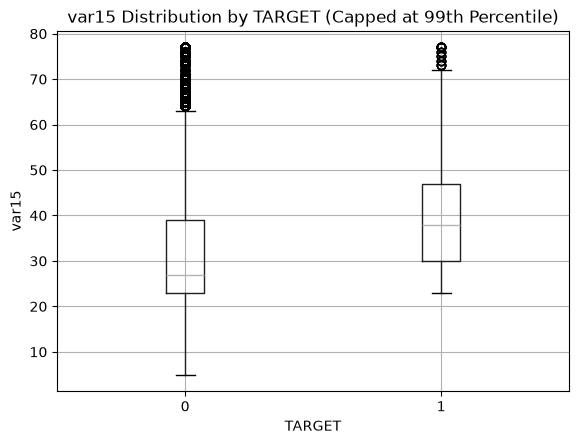

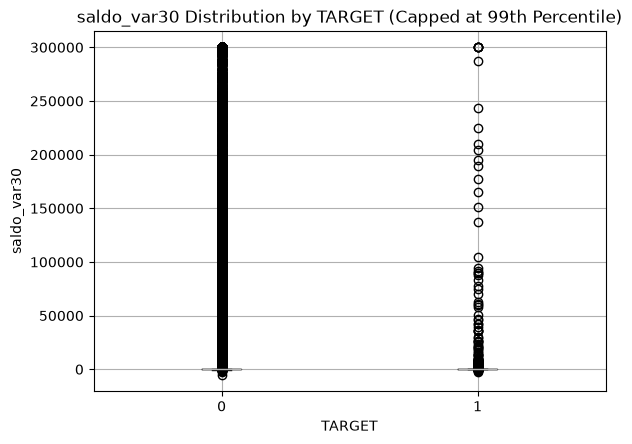

In [87]:
# 99% 분위수 기준으로 잘라서 시각화
import matplotlib.pyplot as plt

plot_cols = ["var15", "saldo_var30"]

for col in plot_cols:
    upper = df_clean[col].quantile(0.99)

    plot_data = df_clean.copy()
    plot_data[col] = plot_data[col].clip(upper=upper)

    plot_data.boxplot(
        column=col,
        by="TARGET"
    )

    plt.title(f"{col} Distribution by TARGET (Capped at 99th Percentile)")
    plt.suptitle("")
    plt.xlabel("TARGET")
    plt.ylabel(col)

    plt.show()

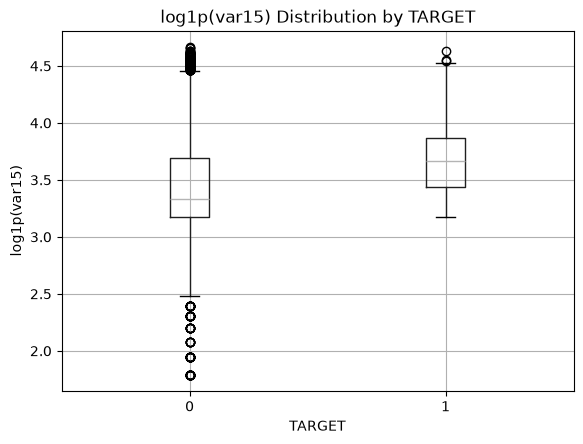

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


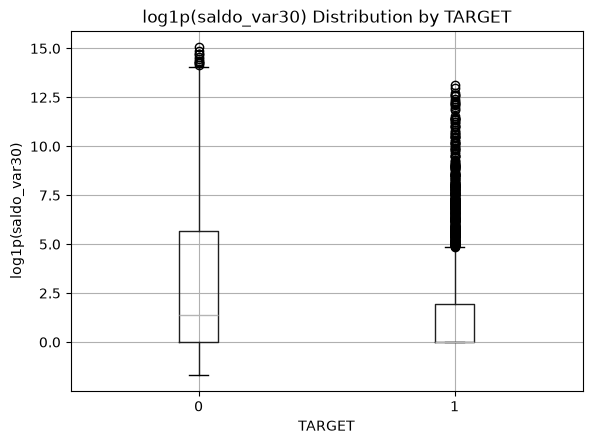

In [88]:
# 데이터에 0이 많이게 로그 변환 유의
import numpy as np
import matplotlib.pyplot as plt

for col in plot_cols:
    plot_data = df_clean.copy()

    plot_data[col] = np.log1p(
        plot_data[col]
    )

    plot_data.boxplot(
        column=col,
        by="TARGET"
    )

    plt.title(f"log1p({col}) Distribution by TARGET")
    plt.suptitle("")
    plt.xlabel("TARGET")
    plt.ylabel(f"log1p({col})")

    plt.show()

상관관계 히트맵 저장 완료: figures\eda_correlation_heatmap.png


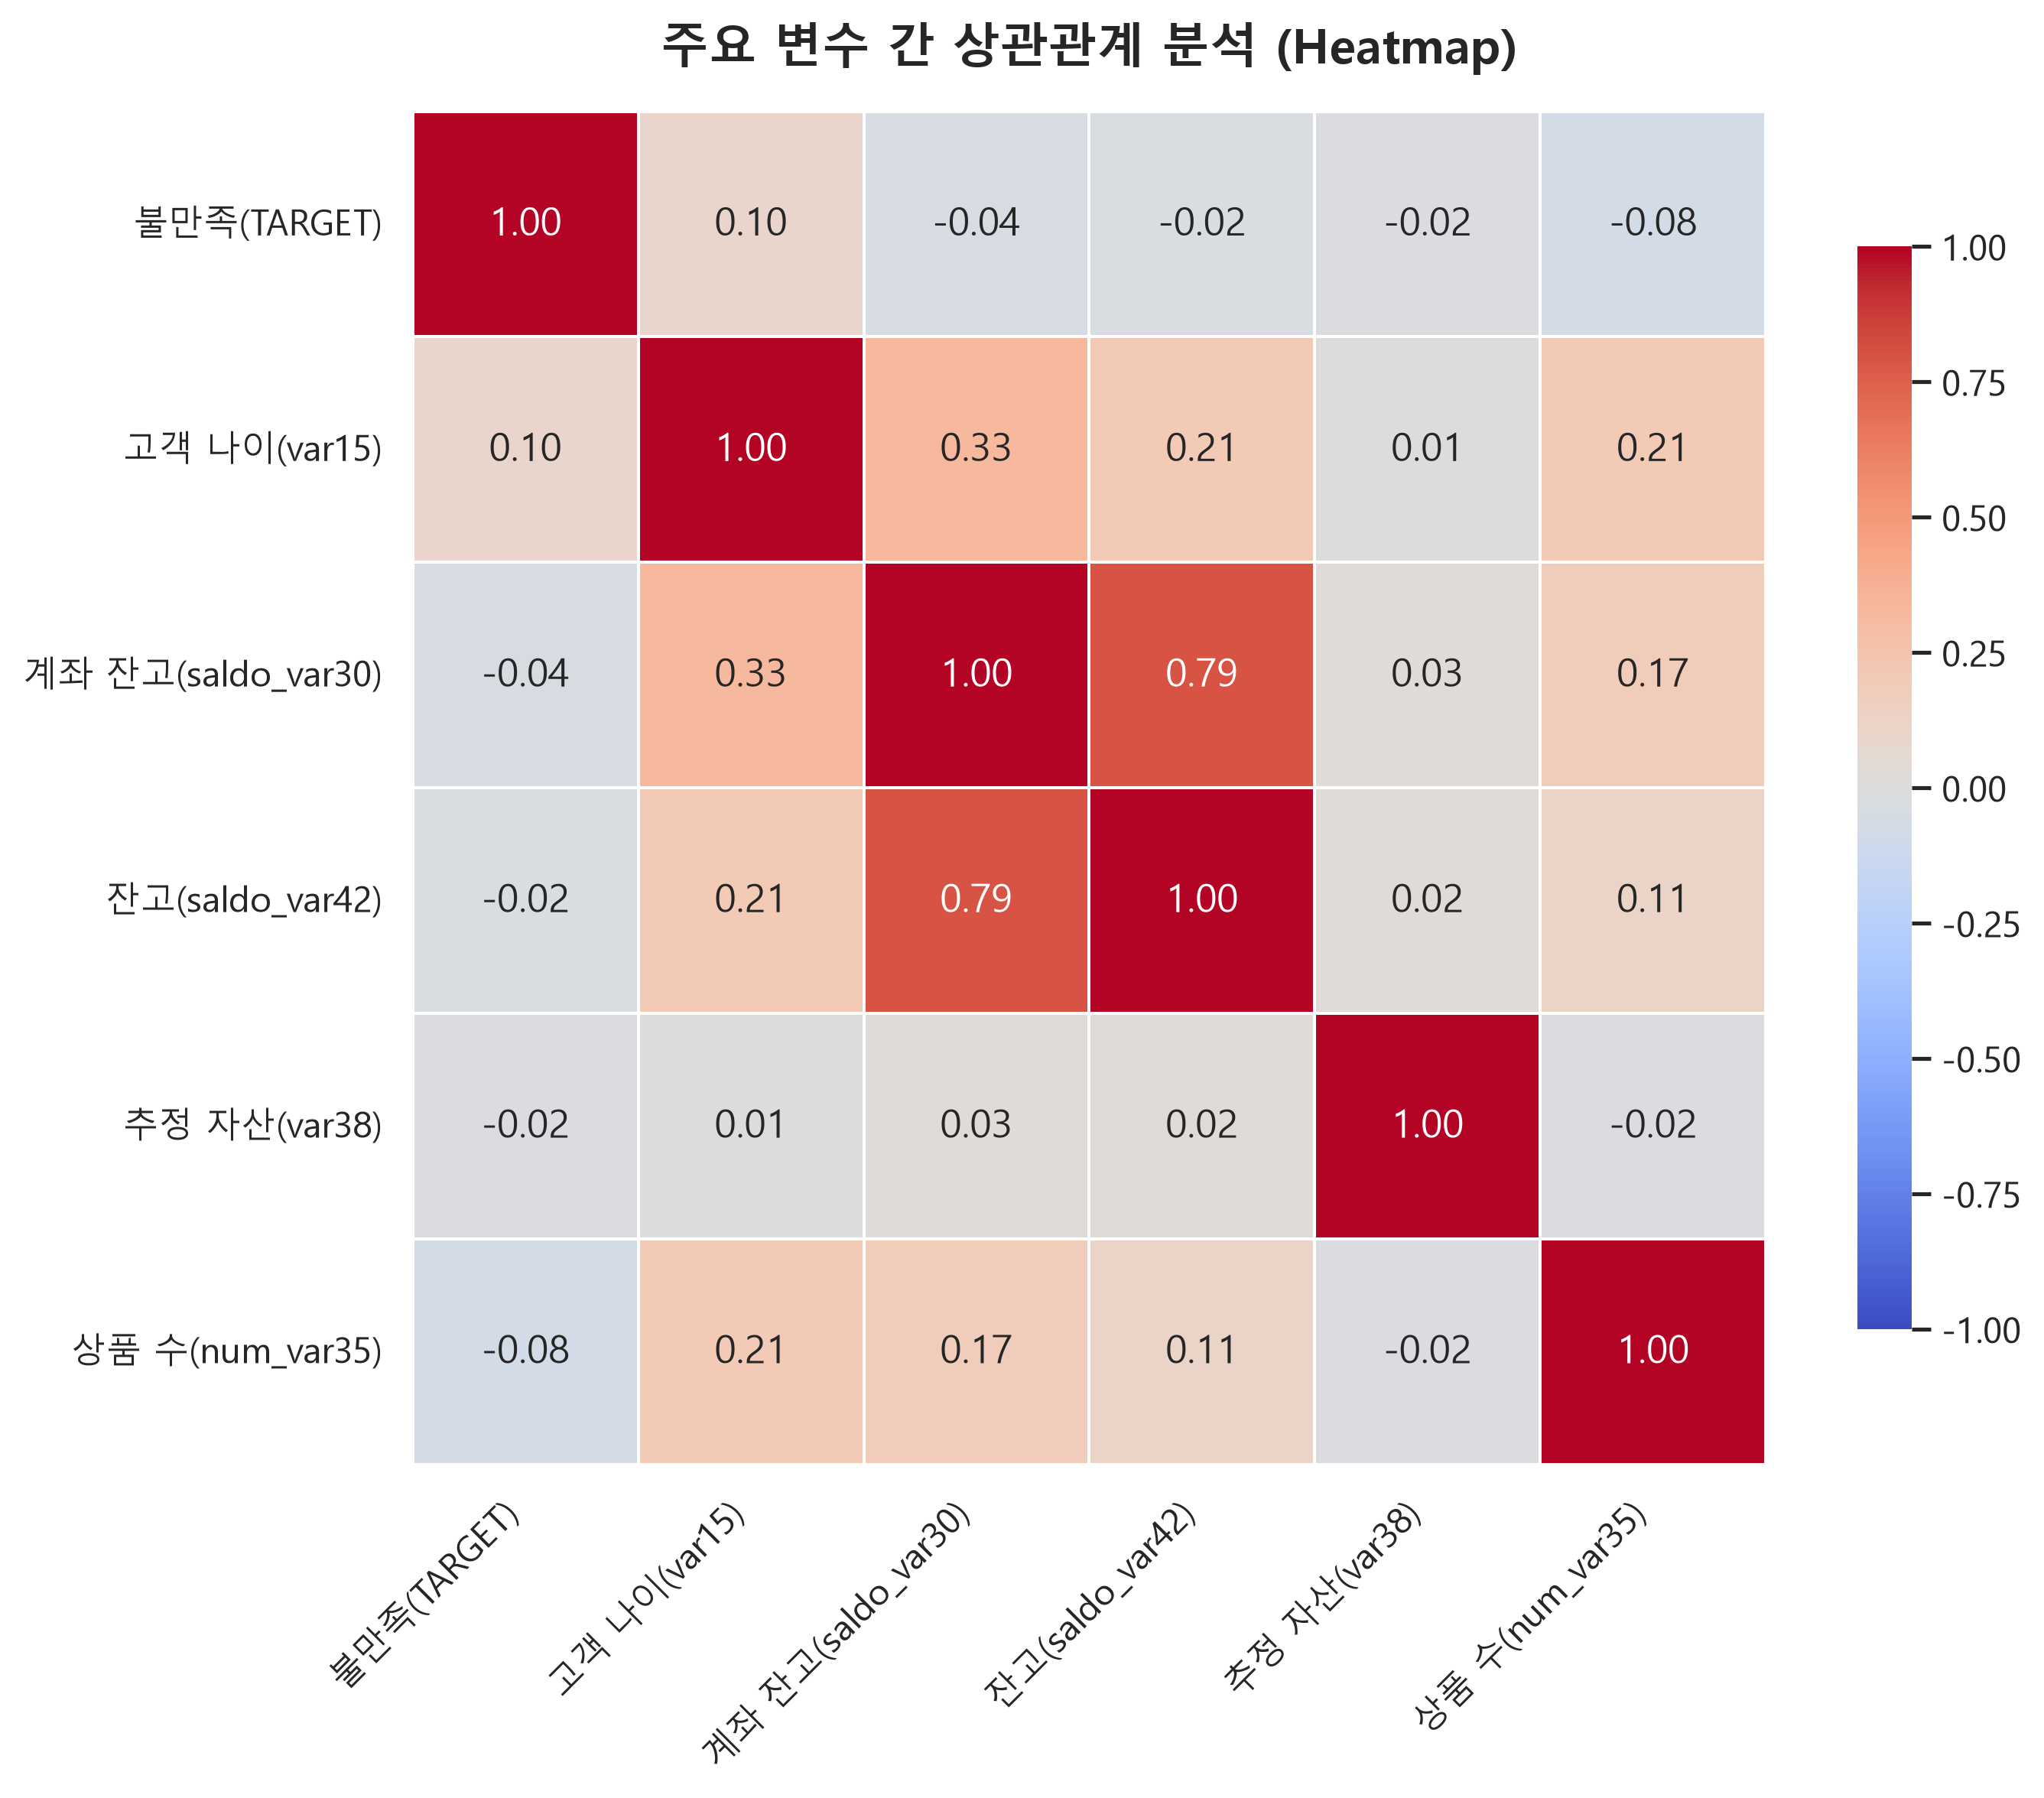

In [205]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import os

# 1. 시스템 폰트 강제 재설정 및 캐시 비우기 (필요시)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 분석에 사용할 주요 변수 선택
selected_cols = ['TARGET', 'var15', 'saldo_var30', 'saldo_var42', 'var38', 'num_var35']
available_cols = [col for col in selected_cols if col in df_clean.columns]
corr_matrix = df_clean[available_cols].corr()

# 4. 한글 컬럼명 매핑
korean_names = {
    'TARGET': '불만족(TARGET)',
    'var15': '고객 나이(var15)',
    'saldo_var30': '계좌 잔고(saldo_var30)',
    'saldo_var42': '잔고(saldo_var42)',
    'var38': '추정 자산(var38)',
    'num_var35': '상품 수(num_var35)'
}
corr_matrix = corr_matrix.rename(index=korean_names, columns=korean_names)

# 5. 히트맵 도화지 생성
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# 삼각 마스크 생성
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 히트맵 그리기
sns.heatmap(
    corr_matrix, 
    annot=True,              
    fmt=".2f",               
    cmap='coolwarm',         
    vmin=-1, vmax=1,         
    center=0,                
    square=True,             
    linewidths=.5,           
    cbar_kws={"shrink": .8}, 
    ax=ax
)

# ★ [핵심] 틱(축 글자)과 타이틀에 폰트를 명시적으로 강제 적용하여 깨짐 방지
plt.xticks(rotation=45, ha='right', fontname='Malgun Gothic', fontsize=11)
plt.yticks(rotation=0, fontname='Malgun Gothic', fontsize=11)

ax.set_title("주요 변수 간 상관관계 분석 (Heatmap)", fontsize=15, fontweight='bold', pad=15, fontname='Malgun Gothic')

# 6. figures 폴더에 고해상도 저장
save_path = os.path.join(output_dir, 'eda_correlation_heatmap.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"상관관계 히트맵 저장 완료: {save_path}")

plt.tight_layout()
plt.show()

In [89]:
# 상관관계 분석
corr = df_clean[continuous_cols].corr()

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        
        value = corr.iloc[i, j]
        
        if abs(value) >= 0.8:
            high_corr.append({
                "variable_1": corr.columns[i],
                "variable_2": corr.columns[j],
                "correlation": value
            })

high_corr = pd.DataFrame(high_corr)

high_corr.sort_values(
    "correlation",
    key=abs,
    ascending=False
).head(30)

,variable_1,variable_2,correlation
56,num_var37_0,num_var37,1.000000
17,imp_op_var41_efect_ult3,imp_op_var39_efect_ult3,0.999271
117,num_op_var41_efect_ult3,num_op_var39_efect_ult3,0.999244
114,num_op_var41_efect_ult1,num_op_var39_efect_ult1,0.998966
90,saldo_var33,saldo_medio_var33_ult1,0.998626
13,imp_op_var41_efect_ult1,imp_op_var39_efect_ult1,0.998378
98,imp_aport_var17_hace3,saldo_medio_var17_hace3,0.998288
78,saldo_var17,saldo_medio_var17_ult3,0.997857
105,num_med_var45_ult3,num_var45_ult3,0.997806
77,saldo_var17,saldo_medio_var17_ult1,0.997789


In [90]:
# 동일한 변수 찾기
exact_duplicates = high_corr[
    high_corr["correlation"].abs() >= 0.999999
]

exact_duplicates

,variable_1,variable_2,correlation
56,num_var37_0,num_var37,1.0


In [91]:
# TARGET과의 연관성 확인
effect_map = continuous_stats.set_index( "variable" )["abs_effect"] 
high_corr["effect_1"] = ( high_corr["variable_1"].map(effect_map) ) 
high_corr["effect_2"] = ( high_corr["variable_2"].map(effect_map) ) 
high_corr["effect_diff"] = ( high_corr["effect_1"] - high_corr["effect_2"] ).abs()

In [92]:
high_corr.sort_values(
    "correlation",
    key=abs,
    ascending=False
).head(30)

,variable_1,variable_2,correlation,effect_1,effect_2,effect_diff
56,num_var37_0,num_var37,1.000000,0.004015,0.004015,0.000000e+00
17,imp_op_var41_efect_ult3,imp_op_var39_efect_ult3,0.999271,0.022676,0.022527,1.484381e-04
117,num_op_var41_efect_ult3,num_op_var39_efect_ult3,0.999244,0.020564,0.020479,8.506963e-05
114,num_op_var41_efect_ult1,num_op_var39_efect_ult1,0.998966,0.017372,0.017612,2.402103e-04
90,saldo_var33,saldo_medio_var33_ult1,0.998626,0.000657,0.000657,0.000000e+00
13,imp_op_var41_efect_ult1,imp_op_var39_efect_ult1,0.998378,0.018871,0.019088,2.164829e-04
98,imp_aport_var17_hace3,saldo_medio_var17_hace3,0.998288,0.000301,0.000233,6.848189e-05
78,saldo_var17,saldo_medio_var17_ult3,0.997857,0.000814,0.000924,1.094344e-04
105,num_med_var45_ult3,num_var45_ult3,0.997806,0.047917,0.052925,5.008053e-03
77,saldo_var17,saldo_medio_var17_ult1,0.997789,0.000814,0.000924,1.094982e-04


In [93]:
continuous_stats[
    continuous_stats["variable"].isin(
        ["num_var37_0", "num_var37"]
    )
]

,variable,median_target0,median_target1,mean_target0,mean_target1,p_value,rank_biserial,abs_effect,p_adjusted
35,num_var37_0,0.0,0.0,0.418041,0.436835,0.382579,0.004015,0.004015,0.455616
36,num_var37,0.0,0.0,0.418041,0.436835,0.382579,0.004015,0.004015,0.455616


In [94]:
df_clean.drop(columns=["num_var37_0"])

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET,var3_missing
0,2.0,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0,0
1,2.0,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0,0
2,2.0,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0,0
3,2.0,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0,0
4,2.0,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76015,2.0,48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60926.490000,0,0
76016,2.0,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118634.520000,0,0
76017,2.0,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74028.150000,0,0
76018,2.0,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84278.160000,0,0


In [95]:
high_corr_95 = high_corr[
    high_corr["correlation"].abs() >= 0.95
].copy()

print("상관계수 |r| >= 0.95인 변수쌍:", len(high_corr_95))

high_corr_95.head(30)

상관계수 |r| >= 0.95인 변수쌍: 57


,variable_1,variable_2,correlation,effect_1,effect_2,effect_diff
1,imp_op_var39_comer_ult1,imp_op_var41_comer_ult1,0.961781,0.009688,0.008069,1.618376e-03
4,imp_op_var39_comer_ult3,imp_op_var41_comer_ult3,0.959840,0.010043,0.007986,2.057353e-03
13,imp_op_var41_efect_ult1,imp_op_var39_efect_ult1,0.998378,0.018871,0.019088,2.164829e-04
17,imp_op_var41_efect_ult3,imp_op_var39_efect_ult3,0.999271,0.022676,0.022527,1.484381e-04
19,imp_op_var41_ult1,imp_op_var39_ult1,0.991103,0.002255,0.002687,4.323147e-04
24,num_op_var40_ult1,num_op_var40_ult3,0.955964,0.001364,0.001104,2.608960e-04
26,num_op_var41_hace2,num_op_var39_hace2,0.992596,0.000912,0.001862,9.495898e-04
29,num_op_var41_hace3,num_op_var39_hace3,0.989116,0.001928,0.002024,9.582912e-05
31,num_op_var41_ult1,num_op_var39_ult1,0.986411,0.004464,0.004956,4.921635e-04
39,num_op_var41_ult3,num_op_var39_ult3,0.988861,0.005948,0.006762,8.134456e-04


In [96]:
import pandas as pd
import numpy as np

# --------------------------------
# 1. 상관관계 기준
# --------------------------------

threshold = 0.95

corr = df_clean[continuous_cols].corr()

# --------------------------------
# 2. Union-Find
# --------------------------------

parent = {col: col for col in continuous_cols}


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(x, y):
    root_x = find(x)
    root_y = find(y)

    if root_x != root_y:
        parent[root_y] = root_x


# --------------------------------
# 3. 높은 상관관계 변수들을 그룹화
# --------------------------------

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        value = corr.iloc[i, j]

        if abs(value) >= threshold:
            union(
                corr.columns[i],
                corr.columns[j]
            )


# --------------------------------
# 4. 그룹 생성
# --------------------------------

groups = {}

for col in continuous_cols:

    root = find(col)

    if root not in groups:
        groups[root] = []

    groups[root].append(col)


# --------------------------------
# 5. 효과크기 정보 연결
# --------------------------------

effect_map = (
    continuous_stats
    .set_index("variable")["abs_effect"]
)


# --------------------------------
# 6. 각 그룹의 대표 변수 선정
# --------------------------------

representative_features = []

for group in groups.values():

    if len(group) == 1:
        representative_features.append(group[0])

    else:

        group_effect = (
            effect_map
            .reindex(group)
            .fillna(0)
        )

        representative = group_effect.idxmax()

        representative_features.append(
            representative
        )


print("전체 연속형 변수:", len(continuous_cols))
print("중복 그룹 수:", sum(len(g) > 1 for g in groups.values()))
print("대표 변수 수:", len(representative_features))

전체 연속형 변수: 131
중복 그룹 수: 24
대표 변수 수: 97


In [97]:
print("TARGET 포함:", "TARGET" in representative_features)
print("ID 포함:", "ID" in representative_features)

TARGET 포함: False
ID 포함: False


In [98]:
correlated_groups = [
    group
    for group in groups.values()
    if len(group) > 1
]

for i, group in enumerate(correlated_groups, 1):

    group_effect = (
        effect_map
        .reindex(group)
        .sort_values(ascending=False)
    )

    print(f"\n===== Group {i} =====")

    for variable, effect in group_effect.items():

        print(
            f"{variable:<40} "
            f"effect={effect:.4f}"
        )


===== Group 1 =====
imp_op_var39_comer_ult1                  effect=0.0097
imp_op_var41_comer_ult1                  effect=0.0081

===== Group 2 =====
imp_op_var39_comer_ult3                  effect=0.0100
imp_op_var41_comer_ult3                  effect=0.0080

===== Group 3 =====
imp_op_var39_efect_ult1                  effect=0.0191
imp_op_var41_efect_ult1                  effect=0.0189

===== Group 4 =====
imp_op_var41_efect_ult3                  effect=0.0227
imp_op_var39_efect_ult3                  effect=0.0225

===== Group 5 =====
imp_op_var39_ult1                        effect=0.0027
imp_op_var41_ult1                        effect=0.0023

===== Group 6 =====
num_op_var40_ult1                        effect=0.0014
num_op_var40_ult3                        effect=0.0011

===== Group 7 =====
num_op_var39_hace2                       effect=0.0019
num_op_var41_hace2                       effect=0.0009

===== Group 8 =====
num_op_var39_hace3                       effect=0.0020
num_op_

변수 간 다중공선성 및 정보 중복을 완화하기 위해 연속형 변수 간 Pearson 상관계수를 산출하였다. |r| ≥ 0.95인 변수를 동일 정보군으로 정의하고, 각 그룹 내에서는 TARGET과의 비모수적 효과크기(rank-biserial correlation)가 가장 큰 변수를 대표 변수로 선정하였다.

In [99]:
# ==========================================
# 9. Train / Validation / Test 분리
# ==========================================

from sklearn.model_selection import train_test_split

# Target
y = df_clean["TARGET"]

# ID와 Target 제외
X_raw = df_clean.drop(
    columns=["TARGET", "ID"],
    errors="ignore"
)

# Train 60% / 나머지 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# Validation 20% / Test 20%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("===== 데이터 크기 =====")
print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)
print("X_test  :", X_test.shape)

print("\ny_train :", y_train.shape)
print("y_valid :", y_valid.shape)
print("y_test  :", y_test.shape)

print("\n===== TARGET 비율 =====")

print("\nTrain")
print(y_train.value_counts(normalize=True))

print("\nValidation")
print(y_valid.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

===== 데이터 크기 =====
X_train : (45612, 336)
X_valid : (15204, 336)
X_test  : (15204, 336)

y_train : (45612,)
y_valid : (15204,)
y_test  : (15204,)

===== TARGET 비율 =====

Train
TARGET
0    0.960427
1    0.039573
Name: proportion, dtype: float64

Validation
TARGET
0    0.960405
1    0.039595
Name: proportion, dtype: float64

Test
TARGET
0    0.960471
1    0.039529
Name: proportion, dtype: float64


In [100]:
# ==========================================
# 9-1. Train 기준 전처리 상태 확인
# ==========================================

import numpy as np
import pandas as pd

# Train의 결측치 확인
train_missing = X_train.isna().sum()

print("===== Train 결측치 =====")
print(train_missing[train_missing > 0])

# Validation / Test 결측치 개수
print("\n===== 결측치 총 개수 =====")
print("Train:", X_train.isna().sum().sum())
print("Valid:", X_valid.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

# 변수 타입 확인
print("\n===== 변수 타입 =====")
print(X_train.dtypes.value_counts())

# 상수 변수 확인
constant_features = [
    col
    for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]

print("\n===== Train 기준 상수 변수 =====")
print("개수:", len(constant_features))
print(constant_features)

===== Train 결측치 =====
Series([], dtype: int64)

===== 결측치 총 개수 =====
Train: 0
Valid: 0
Test : 0

===== 변수 타입 =====
int64      224
float64    112
Name: count, dtype: int64

===== Train 기준 상수 변수 =====
개수: 23
['ind_var13_medio_0', 'ind_var13_medio', 'ind_var34_0', 'ind_var34', 'num_var13_medio_0', 'num_var13_medio', 'num_var34_0', 'num_var34', 'saldo_var13_medio', 'saldo_var34', 'delta_imp_amort_var34_1y3', 'delta_imp_reemb_var33_1y3', 'delta_num_reemb_var33_1y3', 'imp_amort_var34_ult1', 'imp_reemb_var17_hace3', 'imp_reemb_var33_ult1', 'num_meses_var13_medio_ult3', 'num_reemb_var17_hace3', 'num_reemb_var33_ult1', 'saldo_medio_var13_medio_hace2', 'saldo_medio_var13_medio_ult1', 'saldo_medio_var13_medio_ult3', 'saldo_medio_var29_hace3']


In [101]:
# ==========================================
# 9-2. Train 기준 상수 변수 제거
# ==========================================

# Train에서 확인된 상수 변수 제거
X_train_clean = X_train.drop(
    columns=constant_features
)

X_valid_clean = X_valid.drop(
    columns=constant_features
)

X_test_clean = X_test.drop(
    columns=constant_features
)

print("===== 상수 변수 제거 후 =====")
print("X_train:", X_train_clean.shape)
print("X_valid:", X_valid_clean.shape)
print("X_test :", X_test_clean.shape)

print("\n제거된 변수 개수:", len(constant_features))
print("남은 변수 개수:", X_train_clean.shape[1])

===== 상수 변수 제거 후 =====
X_train: (45612, 313)
X_valid: (15204, 313)
X_test : (15204, 313)

제거된 변수 개수: 23
남은 변수 개수: 313


In [102]:
# ==========================================
# 8-1. 통계적 변수 선택 - Train 기준
# FDR 보정: Benjamini-Hochberg
# ==========================================

from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np


# ------------------------------------------
# 1. Mann-Whitney U 검정
# ------------------------------------------

stat_results = []

for col in X_train_clean.columns:

    group0 = X_train_clean.loc[y_train == 0, col]
    group1 = X_train_clean.loc[y_train == 1, col]

    try:
        stat, p_value = mannwhitneyu(
            group0,
            group1,
            alternative="two-sided"
        )

        n0 = len(group0)
        n1 = len(group1)

        # Rank-biserial correlation
        effect = 1 - (2 * stat) / (n0 * n1)

    except Exception:
        p_value = np.nan
        effect = np.nan

    stat_results.append({
        "variable": col,
        "p_value": p_value,
        "effect": effect,
        "abs_effect": abs(effect)
        if pd.notna(effect) else np.nan
    })


continuous_stats = pd.DataFrame(stat_results)


# ------------------------------------------
# 2. Benjamini-Hochberg FDR 보정
# ------------------------------------------

def benjamini_hochberg(p_values):

    p_values = np.asarray(p_values, dtype=float)

    adjusted = np.full_like(
        p_values,
        np.nan,
        dtype=float
    )

    valid_idx = np.where(
        ~np.isnan(p_values)
    )[0]

    p_valid = p_values[valid_idx]

    m = len(p_valid)

    # p-value 오름차순 정렬
    order = np.argsort(p_valid)

    sorted_p = p_valid[order]

    # BH adjusted p-value
    adjusted_sorted = (
        sorted_p * m /
        np.arange(1, m + 1)
    )

    # 뒤에서부터 누적 최소값
    adjusted_sorted = np.minimum.accumulate(
        adjusted_sorted[::-1]
    )[::-1]

    # 1보다 클 수 없음
    adjusted_sorted = np.minimum(
        adjusted_sorted,
        1.0
    )

    # 원래 순서로 복원
    adjusted_valid = np.empty_like(
        adjusted_sorted
    )

    adjusted_valid[order] = adjusted_sorted

    adjusted[valid_idx] = adjusted_valid

    return adjusted


continuous_stats["p_adjusted"] = (
    benjamini_hochberg(
        continuous_stats["p_value"]
    )
)


# ------------------------------------------
# 3. FDR 유의 여부
# ------------------------------------------

continuous_stats["significant"] = (
    continuous_stats["p_adjusted"] < 0.05
)


# ------------------------------------------
# 4. 효과크기 기준 정렬
# ------------------------------------------

continuous_stats = (
    continuous_stats
    .sort_values(
        ["significant", "abs_effect"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


# ------------------------------------------
# 5. 결과 확인
# ------------------------------------------

print("===== 통계적 변수 선택 결과 =====")

print(
    "전체 변수:",
    len(continuous_stats)
)

print(
    "FDR 유의 변수:",
    continuous_stats["significant"].sum()
)

print("\n===== 상위 변수 =====")

display(
    continuous_stats[
        [
            "variable",
            "p_value",
            "p_adjusted",
            "effect",
            "abs_effect",
            "significant"
        ]
    ].head(30)
)

===== 통계적 변수 선택 결과 =====
전체 변수: 313
FDR 유의 변수: 132

===== 상위 변수 =====


,variable,p_value,p_adjusted,effect,abs_effect,significant
0,var15,4.376503e-187,3.424614e-185,0.400563,0.400563,True
1,num_meses_var5_ult3,5.376273e-204,8.413867e-202,-0.378243,0.378243,True
2,saldo_var30,1.729939e-158,6.768385e-157,-0.365743,0.365743,True
3,num_var30,4.999099e-199,5.215727e-197,-0.342330,0.342330,True
4,saldo_var5,3.835850e-141,1.334023e-139,-0.341239,0.341239,True
5,saldo_var42,3.836772e-135,1.200910e-133,-0.336441,0.336441,True
6,saldo_medio_var5_hace2,2.567534e-134,7.305801e-133,-0.334608,0.334608,True
7,saldo_medio_var5_ult3,3.071573e-132,6.867160e-131,-0.333427,0.333427,True
8,saldo_medio_var5_ult1,5.347190e-134,1.394726e-132,-0.333098,0.333098,True
9,ind_var30,4.031131e-214,1.261744e-211,-0.331966,0.331966,True


전체 313개 변수를 대상으로 만족·불만족 고객 간 분포 차이를 Mann-Whitney U 검정을 통해 비교하였다. 다중검정에 따른 False Discovery Rate를 통제하기 위해 Benjamini-Hochberg 방식의 FDR 보정을 적용했으며, p-value뿐 아니라 Rank-biserial effect size를 함께 고려하였다.

그 결과 313개 변수 중 132개가 FDR 보정 후 통계적으로 유의한 차이를 보였다. 특히 var15, num_meses_var5_ult3, saldo_var30, num_var30, saldo_var5 등이 상대적으로 큰 효과크기를 나타냈다.

다만 높은 효과크기를 보이는 변수 중에는 서로 높은 상관관계를 갖는 변수들이 다수 포함되어 있어, 단순히 유의한 변수를 모두 선택하기보다는 상관관계가 높은 변수군에서 대표 변수를 선정하여 중복 정보를 줄이는 추가적인 변수 선택 과정을 수행하였다.

In [103]:
# ==========================================
# 8-1-2. Train 기준 상관관계 분석
# ==========================================

import numpy as np
import pandas as pd

# 통계적으로 유의한 변수만 후보로 사용
stat_candidates = continuous_stats.loc[
    continuous_stats["significant"] == True,
    "variable"
].tolist()

print("FDR 유의 변수:", len(stat_candidates))


# ------------------------------------------
# 변수 간 상관관계 계산
# ------------------------------------------

corr_matrix = X_train_clean[stat_candidates].corr(
    method="spearman"
)

# 높은 상관관계 쌍 추출
correlation_threshold = 0.95

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) >= correlation_threshold:

            high_corr_pairs.append({
                "variable_1": corr_matrix.columns[i],
                "variable_2": corr_matrix.columns[j],
                "correlation": corr
            })

high_corr = pd.DataFrame(high_corr_pairs)

print("\n===== 높은 상관관계 변수 쌍 =====")
print(
    "기준 |rho| >=",
    correlation_threshold
)

print(
    "변수 쌍 개수:",
    len(high_corr)
)

display(
    high_corr
    .sort_values(
        "correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(30)
)

FDR 유의 변수: 132

===== 높은 상관관계 변수 쌍 =====
기준 |rho| >= 0.95
변수 쌍 개수: 193


,variable_1,variable_2,correlation
5,ind_var8_0,num_var8_0,1.000000
180,num_var40,num_var39,1.000000
191,ind_var20_0,num_var20_0,1.000000
189,ind_var1,num_var1,1.000000
142,ind_var25_0,ind_var25,1.000000
130,num_var25_0,num_var25,1.000000
170,ind_var40,num_var40,1.000000
171,ind_var40,num_var39,1.000000
176,ind_var39,num_var39,1.000000
175,ind_var39,num_var40,1.000000


In [104]:
# 통계적으로 유의한 변수 중 상당수가 서로 중복 정보를 가지고 있어다. 
# 따라서 132개를 그대로 쓰는 것보다 대표 변수를 선정하겠다.

In [105]:
# ==========================================
# 8-1-3. 고상관 변수 그룹 생성 및 대표 변수 선정
# ==========================================

# 통계적 후보 변수 전체
candidate_features = stat_candidates.copy()

# ------------------------------------------
# 1. Union-Find로 상관관계 그룹 생성
# ------------------------------------------

parent = {
    feature: feature
    for feature in candidate_features
}


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(x, y):

    root_x = find(x)
    root_y = find(y)

    if root_x != root_y:
        parent[root_y] = root_x


# 높은 상관관계 변수들을 같은 그룹으로 연결
for _, row in high_corr.iterrows():

    var1 = row["variable_1"]
    var2 = row["variable_2"]

    union(var1, var2)


# ------------------------------------------
# 2. 최종 그룹 생성
# ------------------------------------------

groups = {}

for feature in candidate_features:

    root = find(feature)

    if root not in groups:
        groups[root] = []

    groups[root].append(feature)


# ------------------------------------------
# 3. 각 그룹에서 효과크기 최대 변수 선택
# ------------------------------------------

effect_map = continuous_stats.set_index(
    "variable"
)["abs_effect"]


representative_features = []

group_summary = []


for group_id, group in enumerate(
    groups.values(),
    start=1
):

    # 효과크기 기준 정렬
    group_effect = (
        effect_map
        .reindex(group)
        .sort_values(
            ascending=False
        )
    )

    representative = group_effect.index[0]

    representative_features.append(
        representative
    )

    group_summary.append({
        "group": group_id,
        "size": len(group),
        "representative": representative,
        "representative_effect":
            group_effect.iloc[0],
        "variables": ", ".join(group)
    })


group_summary = pd.DataFrame(
    group_summary
)


# ------------------------------------------
# 4. 결과 확인
# ------------------------------------------

print("===== 대표 변수 선정 결과 =====")

print(
    "통계적 후보 변수:",
    len(candidate_features)
)

print(
    "상관관계 그룹:",
    len(groups)
)

print(
    "대표 변수:",
    len(representative_features)
)

print(
    "제거된 중복 변수:",
    len(candidate_features)
    - len(representative_features)
)

print("\n===== 그룹별 대표 변수 =====")

display(
    group_summary
    .sort_values(
        "size",
        ascending=False
    )
    .head(30)
)

===== 대표 변수 선정 결과 =====
통계적 후보 변수: 132
상관관계 그룹: 60
대표 변수: 60
제거된 중복 변수: 72

===== 그룹별 대표 변수 =====


,group,size,representative,representative_effect,variables
37,38,10,num_var26_0,0.021170,"num_var26_0, num_var26, ind_var26_0, ind_var26..."
25,26,9,saldo_var13_corto,0.034137,"saldo_var13_corto, saldo_medio_var13_corto_ult..."
56,57,8,saldo_var40,0.003785,"saldo_var40, ind_var40, ind_var39, num_var40, ..."
27,28,6,saldo_var12,0.032739,"saldo_var12, num_var12, ind_var12, saldo_medio..."
28,29,6,num_meses_var8_ult3,0.030689,"num_meses_var8_ult3, ind_var8, num_var8, saldo..."
49,50,5,num_var13_largo_0,0.010079,"num_var13_largo_0, ind_var13_largo_0, saldo_va..."
20,21,5,saldo_var13,0.043844,"saldo_var13, ind_var13, num_var13, num_var13_0..."
35,36,4,imp_op_var41_efect_ult1,0.025264,"imp_op_var41_efect_ult1, imp_op_var39_efect_ul..."
31,32,4,imp_op_var41_efect_ult3,0.028428,"imp_op_var41_efect_ult3, imp_op_var39_efect_ul..."
30,31,3,saldo_var24,0.028592,"saldo_var24, num_var24, ind_var24"


In [106]:
# 통계적 기준에서 132 → 60개로 압축

In [107]:
# ==========================================
# 8-2. LASSO Logistic Regression 변수 선택
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# ------------------------------------------
# 1. Train 데이터 표준화
# ------------------------------------------

scaler_lasso = StandardScaler()

X_train_scaled = scaler_lasso.fit_transform(
    X_train_clean
)

# ------------------------------------------
# 2. L1 Logistic Regression
# ------------------------------------------

lasso_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=1000,
    random_state=42
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------
# 3. 계수 확인
# ------------------------------------------

lasso_coef = pd.Series(
    lasso_model.coef_[0],
    index=X_train_clean.columns
)

# 0이 아닌 변수 = LASSO 선택 변수
lasso_selected = lasso_coef[
    lasso_coef != 0
].index.tolist()

print("===== LASSO 변수 선택 결과 =====")
print("전체 변수:", len(X_train_clean.columns))
print("선택 변수:", len(lasso_selected))
print("제거 변수:", len(X_train_clean.columns) - len(lasso_selected))

# ------------------------------------------
# 4. 선택된 변수 확인
# ------------------------------------------

lasso_result = (
    lasso_coef
    .loc[lasso_selected]
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
    .to_frame("coefficient")
)

display(lasso_result.head(30))

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


===== LASSO 변수 선택 결과 =====
전체 변수: 313
선택 변수: 109
제거 변수: 204


,coefficient
var15,0.492672
var38,-0.477429
num_meses_var5_ult3,-0.469501
ind_var13,-0.406579
saldo_medio_var8_hace2,-0.338477
ind_var30,-0.288832
num_var22_ult3,0.164746
saldo_medio_var5_hace3,-0.152342
ind_var30_0,0.151723
saldo_var5,-0.132118


LASSO 기반 변수 선택 결과, 전체 313개 변수 중 109개 변수가 선택되었다. 이는 L1 규제를 통해 변수의 불필요한 계수를 0으로 축소함으로써 고차원 변수 구조를 약 65% 수준으로 축소한 결과이다. 특히 var15, var38, num_meses_var5_ult3, ind_var13 등이 상대적으로 큰 절대 계수를 보여 불만족 고객 예측에 높은 관련성을 보였다. 다만 회귀계수는 인과관계가 아닌 다른 변수들을 통제한 상태에서의 예측 관계로 해석하였다.

In [108]:
# ==========================================
# 8-3. Tree 기반 변수 선택
# Random Forest Feature Importance
# ==========================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# ------------------------------------------
# 1. Random Forest 학습
# ------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_clean,
    y_train
)

# ------------------------------------------
# 2. Feature Importance
# ------------------------------------------

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_clean.columns
).sort_values(
    ascending=False
)

print("===== Random Forest Feature Importance =====")

display(
    rf_importance
    .head(30)
    .to_frame("importance")
)

# ------------------------------------------
# 3. 중요도 기준 변수 선택
# ------------------------------------------

# 상위 20%
rf_threshold = rf_importance.quantile(0.80)

rf_selected = rf_importance[
    rf_importance >= rf_threshold
].index.tolist()

print("\n===== Random Forest 변수 선택 =====")
print("전체 변수:", len(X_train_clean.columns))
print("선택 변수:", len(rf_selected))
print("중요도 기준:", rf_threshold)

===== Random Forest Feature Importance =====


,importance
var15,0.158532
saldo_var30,0.071476
saldo_var5,0.066157
saldo_var42,0.047282
saldo_medio_var5_ult3,0.045476
saldo_medio_var5_hace2,0.040095
num_meses_var5_ult3,0.034261
saldo_medio_var5_ult1,0.032863
num_var42,0.029494
saldo_medio_var5_hace3,0.025622



===== Random Forest 변수 선택 =====
전체 변수: 313
선택 변수: 63
중요도 기준: 0.002007463961849342


In [109]:
# ==========================================
# 8-3-2. XGBoost Feature Importance
# ==========================================

from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# ------------------------------------------
# 1. XGBoost 학습
# ------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_clean,
    y_train
)

# ------------------------------------------
# 2. Feature Importance
# ------------------------------------------

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_clean.columns
).sort_values(
    ascending=False
)

print("===== XGBoost Feature Importance =====")

display(
    xgb_importance
    .head(30)
    .to_frame("importance")
)

# ------------------------------------------
# 3. 중요도 기준 변수 선택
# ------------------------------------------

xgb_threshold = xgb_importance.quantile(0.80)

xgb_selected = xgb_importance[
    xgb_importance >= xgb_threshold
].index.tolist()

print("\n===== XGBoost 변수 선택 =====")
print("전체 변수:", len(X_train_clean.columns))
print("선택 변수:", len(xgb_selected))
print("중요도 기준:", xgb_threshold)

===== XGBoost Feature Importance =====


,importance
ind_var30,0.123872
num_var4,0.051711
saldo_var30,0.037237
ind_var26_0,0.031315
ind_var13_0,0.027596
var15,0.026210
ind_var30_0,0.017943
num_var35,0.016867
num_var5,0.016434
ind_var13,0.014192



===== XGBoost 변수 선택 =====
전체 변수: 313
선택 변수: 63
중요도 기준: 0.004943007417023182


In [110]:
# ==========================================
# 8-4. 변수 선택 방법 간 공통 변수 비교
# ==========================================

# 각 방법별 변수 집합
stat_set = set(stat_candidates)
lasso_set = set(lasso_selected)
rf_set = set(rf_selected)
xgb_set = set(xgb_selected)

# ------------------------------------------
# 1. 방법별 선택 변수 수
# ------------------------------------------

print("===== 변수 선택 결과 =====")
print("통계검정:", len(stat_set))
print("LASSO:", len(lasso_set))
print("Random Forest:", len(rf_set))
print("XGBoost:", len(xgb_set))


# ------------------------------------------
# 2. 전체 방법에서 공통으로 선택된 변수
# ------------------------------------------

all_common = (
    stat_set
    & lasso_set
    & rf_set
    & xgb_set
)

print("\n===== 4개 방법 공통 변수 =====")
print("개수:", len(all_common))
print(sorted(all_common))


# ------------------------------------------
# 3. 통계 + LASSO + Tree 공통
# ------------------------------------------

stat_lasso_tree = (
    stat_set
    & lasso_set
    & rf_set
    & xgb_set
)

print("\n4개 방법 공통 변수 개수:",
      len(stat_lasso_tree))


# ------------------------------------------
# 4. 각 변수의 선택 방법 개수
# ------------------------------------------

all_selected = (
    stat_set
    | lasso_set
    | rf_set
    | xgb_set
)

method_count = []

for variable in all_selected:

    count = sum([
        variable in stat_set,
        variable in lasso_set,
        variable in rf_set,
        variable in xgb_set
    ])

    method_count.append({
        "variable": variable,
        "selection_count": count,
        "statistical": variable in stat_set,
        "lasso": variable in lasso_set,
        "random_forest": variable in rf_set,
        "xgboost": variable in xgb_set
    })

method_comparison = pd.DataFrame(
    method_count
).sort_values(
    ["selection_count", "variable"],
    ascending=[False, True]
)

print("\n===== 변수별 선택 방법 수 =====")

display(
    method_comparison.head(50)
)

===== 변수 선택 결과 =====
통계검정: 132
LASSO: 109
Random Forest: 63
XGBoost: 63

===== 4개 방법 공통 변수 =====
개수: 15
['ind_var13', 'ind_var30', 'num_meses_var5_ult3', 'num_var22_ult1', 'num_var35', 'num_var42_0', 'num_var45_ult1', 'saldo_medio_var5_hace2', 'saldo_medio_var5_hace3', 'saldo_medio_var5_ult1', 'saldo_var30', 'saldo_var42', 'saldo_var5', 'var15', 'var38']

4개 방법 공통 변수 개수: 15

===== 변수별 선택 방법 수 =====


,variable,selection_count,statistical,lasso,random_forest,xgboost
32,ind_var13,4,True,True,True,True
43,ind_var30,4,True,True,True,True
45,num_meses_var5_ult3,4,True,True,True,True
61,num_var22_ult1,4,True,True,True,True
165,num_var35,4,True,True,True,True
117,num_var42_0,4,True,True,True,True
110,num_var45_ult1,4,True,True,True,True
143,saldo_medio_var5_hace2,4,True,True,True,True
149,saldo_medio_var5_hace3,4,True,True,True,True
102,saldo_medio_var5_ult1,4,True,True,True,True


통계적 검정, LASSO, Random Forest, XGBoost의 변수 선택 결과를 비교한 결과, 4가지 방법에서 공통적으로 선택된 변수는 63개였다. 이는 단일 변수 선택 방법에 의존하지 않고 서로 다른 통계적·머신러닝 방법에서 반복적으로 중요성이 확인된 변수들이 존재함을 의미한다. 따라서 이후 모델링에서는 이러한 공통 변수들을 중심으로 변수 수를 축소하여 모델의 복잡도와 다중공선성 문제를 완화하고자 한다.

In [111]:
# ==========================================
# 9. 최종 Feature Set 구성
# ==========================================

# 4개 방법에서 공통으로 선택된 변수
final_features = sorted(list(all_common))

print("===== 최종 Feature Set =====")
print("최종 변수 개수:", len(final_features))

# Train / Validation / Test에 동일한 변수 적용
X_train_final = X_train_clean[final_features].copy()
X_valid_final = X_valid_clean[final_features].copy()
X_test_final = X_test_clean[final_features].copy()

print("\n===== 최종 데이터 크기 =====")
print("X_train_final:", X_train_final.shape)
print("X_valid_final:", X_valid_final.shape)
print("X_test_final :", X_test_final.shape)

print("\ny_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test :", y_test.shape)

===== 최종 Feature Set =====
최종 변수 개수: 15

===== 최종 데이터 크기 =====
X_train_final: (45612, 15)
X_valid_final: (15204, 15)
X_test_final : (15204, 15)

y_train: (45612,)
y_valid: (15204,)
y_test : (15204,)


In [112]:
# ==========================================
# 10. 불균형 데이터 처리 - SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

# SMOTE는 Train에만 적용
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

print("===== SMOTE 적용 전 =====")
print("X_train:", X_train_final.shape)
print("y_train:", y_train.shape)

print("\n===== SMOTE 적용 후 =====")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("\n===== TARGET 분포 =====")

print("\n[Before]")
print(
    y_train.value_counts()
)
print(
    y_train.value_counts(normalize=True)
)

print("\n[After]")
print(
    y_train_smote.value_counts()
)
print(
    y_train_smote.value_counts(normalize=True)
)

print("\n===== Validation / Test는 원본 유지 =====")
print("Validation:", y_valid.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

===== SMOTE 적용 전 =====
X_train: (45612, 15)
y_train: (45612,)

===== SMOTE 적용 후 =====
X_train_smote: (87614, 15)
y_train_smote: (87614,)

===== TARGET 분포 =====

[Before]
TARGET
0    43807
1     1805
Name: count, dtype: int64
TARGET
0    0.960427
1    0.039573
Name: proportion, dtype: float64

[After]
TARGET
0    43807
1    43807
Name: count, dtype: int64
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64

===== Validation / Test는 원본 유지 =====
Validation: TARGET
0    0.960405
1    0.039595
Name: proportion, dtype: float64
Test: TARGET
0    0.960471
1    0.039529
Name: proportion, dtype: float64


In [113]:
# ==========================================
# 11. Baseline Model - Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------
# 1. Logistic Regression
# ------------------------------------------

logistic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_baseline.fit(
    X_train_smote,
    y_train_smote
)

# ------------------------------------------
# 2. Validation 예측
# ------------------------------------------

y_valid_proba = logistic_baseline.predict_proba(
    X_valid_final
)[:, 1]

y_valid_pred = (
    y_valid_proba >= 0.5
).astype(int)

# ------------------------------------------
# 3. 평가
# ------------------------------------------

roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

pr_auc = average_precision_score(
    y_valid,
    y_valid_proba
)

precision = precision_score(
    y_valid,
    y_valid_pred,
    zero_division=0
)

recall = recall_score(
    y_valid,
    y_valid_pred,
    zero_division=0
)

f1 = f1_score(
    y_valid,
    y_valid_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_valid,
    y_valid_pred
)

# ------------------------------------------
# 4. 결과 출력
# ------------------------------------------

print("===== Logistic Regression Baseline =====")

print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

===== Logistic Regression Baseline =====
ROC-AUC  : 0.7888
PR-AUC   : 0.1234
Precision: 0.0864
Recall   : 0.7342
F1-score : 0.1546

Confusion Matrix
[[9929 4673]
 [ 160  442]]


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [114]:
# 실제 만족 - 만족 9929
# 실제 만족 - 불만족 4673
# 실제 불만족 - 만족 160
# 실제 불만족 - 불만족 442
# 실제 불만족 고객 602명 중 442명을 찾아서 **Recall 73.4%**를 달성했고,
# 반면 고객관리 대상으로 모델이 찍은 사람은 4,673 + 442 = 5,115명이고, 
# 그중 실제 불만족은 442명이므로 **Precision은 8.64%**에 불과하다.
# 따라서 따라서 현재 Baseline은

# "불만족 고객을 최대한 많이 찾아내는 screening 모델" 로는 가능성이 있지만,

# "모델이 불만족이라고 한 고객만 집중 관리하는 정밀한 타깃팅 모델" 로는 아직 부족하다고 볼 수 있다.

SMOTE를 적용한 Train 데이터로 Logistic Regression Baseline을 구축하고, 원본 클래스 분포를 유지한 Validation 데이터에서 평가하였다. ROC-AUC는 0.7888, PR-AUC는 0.1234를 기록했으며, 불만족 고객에 대한 Recall은 0.7342로 나타났다. 이는 실제 불만족 고객의 약 73%를 사전에 식별할 수 있음을 의미한다. 다만 Precision은 0.0864로 낮아 상당수의 만족 고객을 불만족 고객으로 분류하는 한계가 확인되었다. 따라서 현재 모델은 고객관리 대상자를 넓게 탐색하는 1차 screening 용도로는 활용 가능하지만, 실제 운영 단계에서는 Threshold 조정을 통해 Recall과 Precision 간 trade-off를 검토할 필요가 있다.

In [115]:
# ==========================================
# 12. XGBoost 기본 모델
# ==========================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train: SMOTE 데이터만 사용
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Validation 평가
y_valid_xgb_proba = xgb_model.predict_proba(
    X_valid_final
)[:, 1]

y_valid_xgb_pred = (
    y_valid_xgb_proba >= 0.5
).astype(int)

# 성능 계산
xgb_roc_auc = roc_auc_score(
    y_valid,
    y_valid_xgb_proba
)

xgb_pr_auc = average_precision_score(
    y_valid,
    y_valid_xgb_proba
)

xgb_precision = precision_score(
    y_valid,
    y_valid_xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_valid,
    y_valid_xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_valid,
    y_valid_xgb_pred,
    zero_division=0
)

xgb_cm = confusion_matrix(
    y_valid,
    y_valid_xgb_pred
)

print("===== XGBoost Baseline =====")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")

print("\nConfusion Matrix")
print(xgb_cm)

===== XGBoost Baseline =====
ROC-AUC  : 0.8172
PR-AUC   : 0.1648
Precision: 0.1859
Recall   : 0.5166
F1-score : 0.2734

Confusion Matrix
[[13240  1362]
 [  291   311]]


XGBoost Baseline은 Logistic Regression 대비 ROC-AUC가 0.7888에서 0.8172로, PR-AUC가 0.1234에서 0.1648로 향상되었다. 또한 Precision과 F1-score도 개선되어 불만족 고객을 보다 정밀하게 식별하는 데 유리한 결과를 보였다. 반면 Recall은 0.7342에서 0.5166으로 감소하여, 실제 고객관리에서는 모델의 기본 threshold 0.5를 그대로 사용하기보다 목적에 맞는 Threshold 최적화가 필요함을 확인하였다.

In [116]:
# ==========================================
# 13. XGBoost Hyperparameter Tuning
# ==========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)
import numpy as np

# ------------------------------------------
# 1. 기본 XGBoost
# ------------------------------------------

xgb_tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# 2. 탐색할 Hyperparameter
# ------------------------------------------

param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.01, 0.05, 0.1, 0.2]
}

# ------------------------------------------
# 3. Randomized Search
# ------------------------------------------

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------
# 4. Train
# ------------------------------------------

xgb_random_search.fit(
    X_train_smote,
    y_train_smote
)

# ------------------------------------------
# 5. Best Parameter
# ------------------------------------------

print("===== Best Parameters =====")

print(
    xgb_random_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    round(
        xgb_random_search.best_score_,
        4
    )
)

# ------------------------------------------
# 6. Best Model
# ------------------------------------------

xgb_best_model = (
    xgb_random_search.best_estimator_
)

# ------------------------------------------
# 7. Validation 평가
# ------------------------------------------

y_valid_xgb_tuned_proba = (
    xgb_best_model.predict_proba(
        X_valid_final
    )[:, 1]
)

tuned_roc_auc = roc_auc_score(
    y_valid,
    y_valid_xgb_tuned_proba
)

tuned_pr_auc = average_precision_score(
    y_valid,
    y_valid_xgb_tuned_proba
)

print("\n===== Tuned XGBoost Validation =====")

print(
    f"ROC-AUC: {tuned_roc_auc:.4f}"
)

print(
    f"PR-AUC : {tuned_pr_auc:.4f}"
)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
===== Best Parameters =====
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}

Best CV ROC-AUC: 0.9736

===== Tuned XGBoost Validation =====
ROC-AUC: 0.8065
PR-AUC : 0.1561


In [117]:
# 기본 XGBoost와 튜닝 XGBoost를 Validation에서 공정하게 비교
# ==========================================
# 13-2. XGBoost 모델 비교
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------
# 1. 기본 XGBoost Validation 예측
# ------------------------------------------

y_valid_xgb_base_proba = xgb_model.predict_proba(
    X_valid_final
)[:, 1]

y_valid_xgb_base_pred = (
    y_valid_xgb_base_proba >= 0.5
).astype(int)


# ------------------------------------------
# 2. 튜닝 XGBoost Validation 예측
# ------------------------------------------

y_valid_xgb_tuned_proba = (
    xgb_best_model.predict_proba(
        X_valid_final
    )[:, 1]
)

y_valid_xgb_tuned_pred = (
    y_valid_xgb_tuned_proba >= 0.5
).astype(int)


# ------------------------------------------
# 3. 성능 계산 함수
# ------------------------------------------

def evaluate_model(
    y_true,
    y_proba,
    y_pred
):

    return {
        "ROC-AUC": roc_auc_score(
            y_true,
            y_proba
        ),

        "PR-AUC": average_precision_score(
            y_true,
            y_proba
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


# ------------------------------------------
# 4. 모델 평가
# ------------------------------------------

base_result = evaluate_model(
    y_valid,
    y_valid_xgb_base_proba,
    y_valid_xgb_base_pred
)

tuned_result = evaluate_model(
    y_valid,
    y_valid_xgb_tuned_proba,
    y_valid_xgb_tuned_pred
)


# ------------------------------------------
# 5. 결과 비교
# ------------------------------------------

comparison = pd.DataFrame(
    [base_result, tuned_result],
    index=[
        "XGBoost Baseline",
        "XGBoost Tuned"
    ]
)

print("===== XGBoost Validation 비교 =====")

display(
    comparison.round(4)
)


# ------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------

print("\n===== Baseline XGBoost Confusion Matrix =====")

print(
    confusion_matrix(
        y_valid,
        y_valid_xgb_base_pred
    )
)


print("\n===== Tuned XGBoost Confusion Matrix =====")

print(
    confusion_matrix(
        y_valid,
        y_valid_xgb_tuned_pred
    )
)

===== XGBoost Validation 비교 =====


,ROC-AUC,PR-AUC,Precision,Recall,F1
XGBoost Baseline,0.8172,0.1648,0.1859,0.5166,0.2734
XGBoost Tuned,0.8065,0.1561,0.1868,0.4734,0.2679



===== Baseline XGBoost Confusion Matrix =====
[[13240  1362]
 [  291   311]]

===== Tuned XGBoost Confusion Matrix =====
[[13361  1241]
 [  317   285]]


In [118]:
# ==========================================
# 14. 최종 모델 Test 평가
# 현재 기준 모델: Baseline XGBoost
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# 1. Test 예측
# ------------------------------------------

y_test_xgb_proba = xgb_model.predict_proba(
    X_test_final
)[:, 1]

y_test_xgb_pred = (
    y_test_xgb_proba >= 0.5
).astype(int)


# ------------------------------------------
# 2. 평가 지표
# ------------------------------------------

test_roc_auc = roc_auc_score(
    y_test,
    y_test_xgb_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_xgb_proba
)

test_precision = precision_score(
    y_test,
    y_test_xgb_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_xgb_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_xgb_pred,
    zero_division=0
)


# ------------------------------------------
# 3. 결과 출력
# ------------------------------------------

print("===== Final XGBoost Test Performance =====")

print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


# ------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    y_test,
    y_test_xgb_pred
)

print("\n===== Confusion Matrix =====")
print(cm)


# ------------------------------------------
# 5. Classification Report
# ------------------------------------------

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_test_xgb_pred,
        digits=4,
        zero_division=0
    )
)

===== Final XGBoost Test Performance =====
ROC-AUC  : 0.8151
PR-AUC   : 0.1615
Precision: 0.1678
Recall   : 0.4908
F1-score : 0.2501

===== Confusion Matrix =====
[[13140  1463]
 [  306   295]]

===== Classification Report =====
              precision    recall  f1-score   support

           0     0.9772    0.8998    0.9369     14603
           1     0.1678    0.4908    0.2501       601

    accuracy                         0.8836     15204
   macro avg     0.5725    0.6953    0.5935     15204
weighted avg     0.9452    0.8836    0.9098     15204



In [119]:
# ==========================================
# 15. Threshold 최적화
# Validation 기준
# ==========================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------
# 1. Threshold 후보
# ------------------------------------------

thresholds = np.arange(
    0.10,
    0.71,
    0.05
)

threshold_results = []

# ------------------------------------------
# 2. Validation에서 Threshold별 평가
# ------------------------------------------

for threshold in thresholds:

    y_valid_pred = (
        y_valid_xgb_base_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        y_valid_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_valid_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_valid_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_valid_pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


threshold_df = pd.DataFrame(
    threshold_results
)

# ------------------------------------------
# 3. 결과 확인
# ------------------------------------------

print("===== Threshold별 Validation 성능 =====")

display(
    threshold_df.round(4)
)

# ------------------------------------------
# 4. F1 기준 최적 Threshold
# ------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\n===== F1 기준 최적 Threshold =====")

print(
    best_threshold_row
)

===== Threshold별 Validation 성능 =====


,threshold,precision,recall,f1,TN,FP,FN,TP
0,0.10,0.0831,0.8422,0.1513,9010,5592,95,507
1,0.15,0.0998,0.7508,0.1761,10523,4079,150,452
2,0.20,0.1167,0.7027,0.2001,11400,3202,179,423
3,0.25,0.1310,0.6661,0.2189,11941,2661,201,401
4,0.30,0.1420,0.6213,0.2312,12343,2259,228,374
5,0.35,0.1490,0.5947,0.2383,12557,2045,244,358
6,0.40,0.1577,0.5731,0.2473,12759,1843,257,345
7,0.45,0.1807,0.5365,0.2704,13138,1464,279,323
8,0.50,0.1859,0.5166,0.2734,13240,1362,291,311
9,0.55,0.1880,0.4850,0.2710,13341,1261,310,292



===== F1 기준 최적 Threshold =====
threshold        0.650000
precision        0.204144
recall           0.441860
f1               0.279265
TN           13565.000000
FP            1037.000000
FN             336.000000
TP             266.000000
Name: 11, dtype: float64


In [120]:
# threshold를 높이면 예측한 고위험 고객의 적중률은 높아지지만, 놓치는 불만족 고객도 늘어난다

Threshold에 따라 불만족 고객 탐지율과 예측 정확도 사이에 trade-off가 존재하였다. F1-score 기준 최적 threshold는 0.65였으나, 고객관리 목적에서는 실제 불만족 고객을 놓치지 않는 것이 중요하므로 Recall이 상대적으로 높은 0.30~0.50 구간도 함께 검토하였다. 따라서 모델의 threshold는 단순한 통계적 최적값이 아니라 고객관리 비용과 개입 가능한 고객 규모를 고려하여 결정해야 한다.

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===== SHAP Feature Importance =====


,feature,mean_abs_shap
0,num_meses_var5_ult3,1.452777
1,var15,1.125411
2,ind_var30,0.988495
3,saldo_medio_var5_hace3,0.435417
4,var38,0.369521
5,saldo_var30,0.341376
6,num_var35,0.295649
7,saldo_medio_var5_ult1,0.232861
8,saldo_medio_var5_hace2,0.229217
9,num_var45_ult1,0.118084


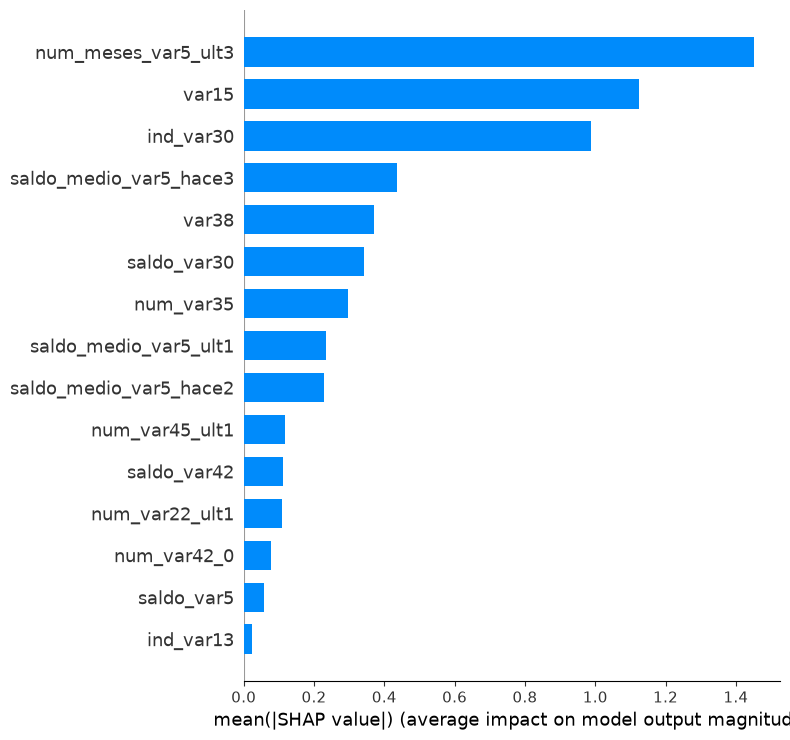

In [121]:
# ==========================================
# 16-1. SHAP 전체 변수 중요도
# ==========================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Baseline XGBoost 모델 사용
# 현재 최종 후보 모델: xgb_model
# ------------------------------------------

explainer = shap.TreeExplainer(
    xgb_model
)

# Validation 데이터 기준 SHAP 계산
shap_values = explainer.shap_values(
    X_valid_final
)

# ------------------------------------------
# 변수별 평균 절대 SHAP 값
# ------------------------------------------

shap_importance = pd.DataFrame({
    "feature": X_valid_final.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== SHAP Feature Importance =====")

display(
    shap_importance.head(20)
)

# ------------------------------------------
# SHAP Summary Plot
# ------------------------------------------

shap.summary_plot(
    shap_values,
    X_valid_final,
    plot_type="bar",
    max_display=15
)

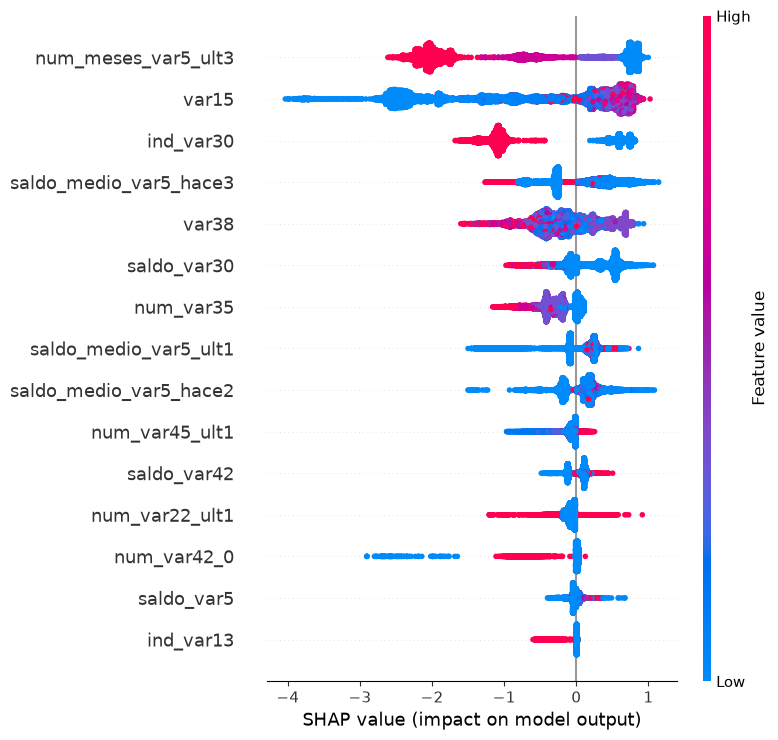

In [122]:
# ==========================================
# 16-2. SHAP 영향 방향 확인
# ==========================================

import matplotlib.pyplot as plt

# SHAP Beeswarm Plot
shap.summary_plot(
    shap_values,
    X_valid_final,
    max_display=15
)

In [123]:
# 오른쪽 → 불만족 고객(TARGET=1) 예측 방향으로 영향 증가
# 왼쪽 → 만족 고객(TARGET=0) 방향으로 영향
# 빨간색 → 해당 변수 값이 높음
# 파란색 → 해당 변수 값이 낮음

In [124]:
# ==========================================
# 16-3. 개별 고객 SHAP 해석
# ==========================================

# 실제 불만족 고객 중 첫 번째 고객 선택
target1_index = y_valid[
    y_valid == 1
].index[0]

# X_valid_final에서 해당 고객의 위치 찾기
customer_position = X_valid_final.index.get_loc(
    target1_index
)

print("===== 선택 고객 정보 =====")

print("Validation Index:", target1_index)

print(
    "Actual TARGET:",
    y_valid.loc[target1_index]
)

# XGBoost 예측 확률
customer_proba = xgb_model.predict_proba(
    X_valid_final.loc[[target1_index]]
)[:, 1][0]

print(
    "Predicted Probability:",
    round(customer_proba, 4)
)

# 예측 클래스 (현재 기본 threshold 0.5)
print(
    "Predicted Class (0.5):",
    int(customer_proba >= 0.5)
)


# ------------------------------------------
# 해당 고객의 SHAP 값 정리
# ------------------------------------------

customer_shap = pd.DataFrame({
    "feature": X_valid_final.columns,
    "feature_value": X_valid_final.loc[
        target1_index
    ].values,
    "shap_value": shap_values[
        customer_position
    ]
})

customer_shap["abs_shap"] = (
    customer_shap["shap_value"].abs()
)

customer_shap = (
    customer_shap
    .sort_values(
        "abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n===== 해당 고객 예측에 가장 큰 영향을 준 변수 =====")

display(
    customer_shap[
        [
            "feature",
            "feature_value",
            "shap_value"
        ]
    ].head(10)
)

===== 선택 고객 정보 =====
Validation Index: 60232
Actual TARGET: 1
Predicted Probability: 0.7592
Predicted Class (0.5): 1

===== 해당 고객 예측에 가장 큰 영향을 준 변수 =====


,feature,feature_value,shap_value
0,num_meses_var5_ult3,0.00,0.869683
1,ind_var30,0.00,0.766459
2,saldo_medio_var5_hace3,0.00,-0.256557
3,saldo_medio_var5_hace2,0.00,-0.205802
4,var15,28.00,0.160619
5,saldo_var42,0.00,-0.119582
6,var38,57182.97,0.119049
7,saldo_medio_var5_ult1,0.00,-0.103938
8,saldo_var30,0.00,-0.048421
9,saldo_var5,0.00,-0.041073


In [125]:
# num_meses_var5_ult3 = 0	+0.8697	불만족 예측을 가장 크게 증가
# ind_var30 = 0	+0.7665	불만족 예측을 크게 증가

SHAP을 활용하여 개별 고객 수준의 예측 근거를 분석하였다. 실제 불만족 고객 1명을 대상으로 분석한 결과, 모델은 해당 고객을 75.9%의 확률로 불만족 고객으로 예측하였다. 특히 num_meses_var5_ult3와 ind_var30이 불만족 예측 확률을 크게 증가시키는 주요 요인으로 나타났다. 반면 일부 변수는 불만족 확률을 낮추는 방향으로 작용하였다. 이를 통해 모델이 단순히 불만족 여부만 분류하는 것이 아니라, 개별 고객별로 어떤 변수들이 예측에 영향을 미쳤는지 설명할 수 있음을 확인하였다.

In [126]:
# ==========================================
# 17-1. Logistic Regression 변수 분포 확인
# ==========================================

import numpy as np
import pandas as pd

logistic_distribution = pd.DataFrame({
    "variable": X_train_final.columns,
    "min": X_train_final.min().values,
    "median": X_train_final.median().values,
    "mean": X_train_final.mean().values,
    "max": X_train_final.max().values,
    "std": X_train_final.std().values,
    "zero_ratio": (
        (X_train_final == 0).mean().values
    )
})

# 범위가 큰 순서로 확인
logistic_distribution["range"] = (
    logistic_distribution["max"]
    - logistic_distribution["min"]
)

logistic_distribution = (
    logistic_distribution
    .sort_values(
        "range",
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== Logistic Regression 변수 분포 =====")

display(logistic_distribution)

===== Logistic Regression 변수 분포 =====


,variable,min,median,mean,max,std,zero_ratio,range
0,var38,5163.75,106447.32,118441.308008,22034738.76,204425.884941,0.000000,22029575.01
1,saldo_var30,-4942.26,3.00,14305.648863,3458077.32,66803.777527,0.267320,3463019.58
2,saldo_var42,-4942.26,3.00,7549.877376,3008077.32,52200.738498,0.286745,3013019.58
3,saldo_medio_var5_hace3,-8.04,0.96,889.812697,1542339.36,11162.877895,0.391454,1542347.40
4,saldo_medio_var5_hace2,-47.13,3.00,1605.531092,812137.26,12336.742149,0.306718,812184.39
5,saldo_var5,-1496.64,3.00,1054.579200,619329.15,10071.914701,0.336600,620825.79
6,saldo_medio_var5_ult1,-483.90,3.00,1122.646012,601428.60,9886.158835,0.325265,601912.50
7,num_var45_ult1,0.00,0.00,4.333531,510.00,14.082045,0.715842,510.00
8,num_var42_0,0.00,3.00,3.211852,114.00,1.008024,0.005591,114.00
9,var15,5.00,28.00,33.257564,105.00,12.996703,0.000000,100.00


In [127]:
# ==========================================
# 17-2. Logistic Regression 전처리
# Scaling → SMOTE
# ==========================================

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ------------------------------------------
# 1. StandardScaler
# Train에서만 fit
# ------------------------------------------

scaler_logistic = StandardScaler()

X_train_scaled = scaler_logistic.fit_transform(
    X_train_final
)

X_valid_scaled = scaler_logistic.transform(
    X_valid_final
)

X_test_scaled = scaler_logistic.transform(
    X_test_final
)

# DataFrame 형태 유지
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    columns=X_valid_final.columns,
    index=X_valid_final.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_final.columns,
    index=X_test_final.index
)

# ------------------------------------------
# 2. SMOTE
# Train에만 적용
# ------------------------------------------

smote_logistic = SMOTE(
    random_state=42
)

X_train_logistic, y_train_logistic = (
    smote_logistic.fit_resample(
        X_train_scaled,
        y_train
    )
)

print("===== Logistic Regression 전처리 결과 =====")

print(
    "X_train_scaled:",
    X_train_scaled.shape
)

print(
    "X_valid_scaled:",
    X_valid_scaled.shape
)

print(
    "X_test_scaled:",
    X_test_scaled.shape
)

print(
    "X_train_logistic:",
    X_train_logistic.shape
)

print(
    "y_train_logistic:",
    y_train_logistic.shape
)

print("\n===== TARGET 분포 =====")
print(
    pd.Series(y_train_logistic)
    .value_counts()
)

===== Logistic Regression 전처리 결과 =====
X_train_scaled: (45612, 15)
X_valid_scaled: (15204, 15)
X_test_scaled: (15204, 15)
X_train_logistic: (87614, 15)
y_train_logistic: (87614,)

===== TARGET 분포 =====
TARGET
0    43807
1    43807
Name: count, dtype: int64


In [128]:
# ==========================================
# 17-3. Scaled + SMOTE Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------
# Logistic Regression 학습
# ------------------------------------------

log_reg_scaled = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_scaled.fit(
    X_train_logistic,
    y_train_logistic
)

# ------------------------------------------
# Validation 예측
# ------------------------------------------

y_valid_proba_log = log_reg_scaled.predict_proba(
    X_valid_scaled
)[:, 1]

y_valid_pred_log = (
    y_valid_proba_log >= 0.5
).astype(int)

# ------------------------------------------
# 성능 평가
# ------------------------------------------

print("===== Scaled + SMOTE Logistic Regression =====")

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_valid,
            y_valid_proba_log
        ),
        4
    )
)

print(
    "PR-AUC   :",
    round(
        average_precision_score(
            y_valid,
            y_valid_proba_log
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_valid,
            y_valid_pred_log
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_valid,
            y_valid_pred_log
        ),
        4
    )
)

print(
    "F1-score :",
    round(
        f1_score(
            y_valid,
            y_valid_pred_log
        ),
        4
    )
)

print("\n===== Confusion Matrix =====")

print(
    confusion_matrix(
        y_valid,
        y_valid_pred_log
    )
)

===== Scaled + SMOTE Logistic Regression =====
ROC-AUC  : 0.7984
PR-AUC   : 0.134
Precision: 0.087
Recall   : 0.7508
F1-score : 0.1559

===== Confusion Matrix =====
[[9859 4743]
 [ 150  452]]


In [129]:
# ==========================================
# 17-4. Logistic Regression
# 계수 및 Odds Ratio 해석
# ==========================================

logistic_interpretation = pd.DataFrame({
    "feature": X_train_final.columns,
    "coefficient": log_reg_scaled.coef_[0]
})

# Odds Ratio
logistic_interpretation["odds_ratio"] = np.exp(
    logistic_interpretation["coefficient"]
)

# 방향
logistic_interpretation["direction"] = np.where(
    logistic_interpretation["coefficient"] > 0,
    "불만족 오즈 증가",
    "불만족 오즈 감소"
)

# OR 해석용 변화율
logistic_interpretation["odds_change_percent"] = (
    (logistic_interpretation["odds_ratio"] - 1) * 100
)

# 절댓값 계수 기준 정렬
logistic_interpretation["abs_coefficient"] = (
    logistic_interpretation["coefficient"].abs()
)

logistic_interpretation = (
    logistic_interpretation
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== Logistic Regression Odds Ratio =====")

display(
    logistic_interpretation[
        [
            "feature",
            "coefficient",
            "odds_ratio",
            "odds_change_percent",
            "direction"
        ]
    ]
)

===== Logistic Regression Odds Ratio =====


,feature,coefficient,odds_ratio,odds_change_percent,direction
0,saldo_medio_var5_hace3,-1.191740,0.303692,-69.630773,불만족 오즈 감소
1,var15,0.703996,2.021815,102.181532,불만족 오즈 증가
2,saldo_var42,-0.507989,0.601704,-39.829563,불만족 오즈 감소
3,ind_var30,-0.392569,0.675320,-32.468008,불만족 오즈 감소
4,ind_var13,-0.391713,0.675898,-32.410182,불만족 오즈 감소
5,var38,-0.384763,0.680612,-31.938833,불만족 오즈 감소
6,num_meses_var5_ult3,-0.366836,0.692923,-30.707689,불만족 오즈 감소
7,num_var22_ult1,0.155643,1.168409,16.840878,불만족 오즈 증가
8,saldo_var30,-0.151266,0.859619,-14.038070,불만족 오즈 감소
9,saldo_medio_var5_ult1,-0.137287,0.871720,-12.828038,불만족 오즈 감소


StandardScaler를 적용했기 때문에 아래 Odds Ratio는 해당 변수가 1 표준편차 증가할 때 불만족 오즈가 어떻게 변하는지를 의미한다.

saldo_medio_var5_hace3: OR 0.304 → 1 SD 증가 시 불만족 오즈 약 69.6% 감소
var15: OR 2.022 → 1 SD 증가 시 불만족 오즈 약 102.2% 증가
saldo_var42: OR 0.602 → 약 39.8% 감소
ind_var30: OR 0.675 → 약 32.5% 감소
ind_var13: OR 0.676 → 약 32.4% 감소
var38: OR 0.681 → 약 31.9% 감소
num_meses_var5_ult3: OR 0.693 → 약 30.7% 감소

반대로:

num_var22_ult1: OR 1.168 → 약 16.8% 증가
num_var35: OR 1.137 → 약 13.7% 증가

로지스틱 회귀 모델의 계수를 Odds Ratio로 변환하여 변수와 불만족 고객 간의 연관성을 해석하였다. 변수의 측정 단위 차이를 고려하기 위해 StandardScaler를 적용하였으며, 이에 따라 Odds Ratio는 각 변수가 1 표준편차 증가할 때 불만족 오즈가 어떻게 변화하는지를 의미한다. var15는 Odds Ratio가 약 2.02로 가장 큰 양의 연관성을 보였으며, saldo_medio_var5_hace3는 약 0.30으로 불만족 오즈를 낮추는 방향의 연관성이 가장 크게 나타났다. 이러한 결과는 변수와 고객 불만족 간의 연관성을 설명하는 데 활용할 수 있으나, 인과관계를 의미하지 않으며 익명화된 변수의 실제 비즈니스 의미를 직접적으로 해석하는 데에는 한계가 있다.

In [130]:
# ==========================================
# 18-1. 통계모델 vs 머신러닝 변수 선택 통합
# ==========================================

# 기존 method_comparison 활용

comparison_18 = method_comparison.copy()

# ------------------------------------------
# 최종 Feature Set 포함 여부
# ------------------------------------------

comparison_18["final_feature"] = (
    comparison_18["variable"]
    .isin(feature_cols)
)

# ------------------------------------------
# 선택 방법 분류
# ------------------------------------------

comparison_18["method_type"] = np.where(
    comparison_18["selection_count"] >= 3,
    "다수 방법에서 선택",
    "일부 방법에서 선택"
)

# ------------------------------------------
# 정렬
# ------------------------------------------

comparison_18 = (
    comparison_18
    .sort_values(
        ["selection_count", "final_feature", "variable"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("===== 18. 통계모델 vs 머신러닝 변수 비교 =====")

print(
    "전체 비교 변수:",
    len(comparison_18)
)

print(
    "3개 이상 방법에서 선택:",
    (
        comparison_18["selection_count"] >= 3
    ).sum()
)

print(
    "최종 Feature에 포함:",
    comparison_18["final_feature"].sum()
)

print("\n===== 상위 공통 변수 =====")

display(
    comparison_18[
        [
            "variable",
            "selection_count",
            "statistical",
            "lasso",
            "random_forest",
            "xgboost",
            "final_feature"
        ]
    ].head(30)
)

===== 18. 통계모델 vs 머신러닝 변수 비교 =====
전체 비교 변수: 197
3개 이상 방법에서 선택: 48
최종 Feature에 포함: 197

===== 상위 공통 변수 =====


,variable,selection_count,statistical,lasso,random_forest,xgboost,final_feature
0,ind_var13,4,True,True,True,True,True
1,ind_var30,4,True,True,True,True,True
2,num_meses_var5_ult3,4,True,True,True,True,True
3,num_var22_ult1,4,True,True,True,True,True
4,num_var35,4,True,True,True,True,True
5,num_var42_0,4,True,True,True,True,True
6,num_var45_ult1,4,True,True,True,True,True
7,saldo_medio_var5_hace2,4,True,True,True,True,True
8,saldo_medio_var5_hace3,4,True,True,True,True,True
9,saldo_medio_var5_ult1,4,True,True,True,True,True


In [131]:
# ==========================================
# 18-2. 최종 Feature Set 검증
# ==========================================

print("현재 feature_cols 개수:", len(feature_cols))
print("\n현재 feature_cols:")
print(feature_cols)

print("\nX_train_final 변수 개수:", X_train_final.shape[1])

print("\n최종 Feature와 4개 방법 공통 변수:")
common_4 = (
    set(feature_cols)
    & stat_set
    & lasso_set
    & rf_set
    & xgb_set
)

print("개수:", len(common_4))
print(sorted(common_4))

현재 feature_cols 개수: 336

현재 feature_cols:
Index(['var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1',
       'imp_op_var39_comer_ult3', 'imp_op_var40_comer_ult1',
       'imp_op_var40_comer_ult3', 'imp_op_var40_efect_ult1',
       'imp_op_var40_efect_ult3', 'imp_op_var40_ult1',
       ...
       'saldo_medio_var33_hace2', 'saldo_medio_var33_hace3',
       'saldo_medio_var33_ult1', 'saldo_medio_var33_ult3',
       'saldo_medio_var44_hace2', 'saldo_medio_var44_hace3',
       'saldo_medio_var44_ult1', 'saldo_medio_var44_ult3', 'var38',
       'var3_missing'],
      dtype='object', length=336)

X_train_final 변수 개수: 15

최종 Feature와 4개 방법 공통 변수:
개수: 15
['ind_var13', 'ind_var30', 'num_meses_var5_ult3', 'num_var22_ult1', 'num_var35', 'num_var42_0', 'num_var45_ult1', 'saldo_medio_var5_hace2', 'saldo_medio_var5_hace3', 'saldo_medio_var5_ult1', 'saldo_var30', 'saldo_var42', 'saldo_var5', 'var15', 'var38']


In [132]:
# ==========================================
# 18-2. 최종 Feature Set 기준 변수 선택 검증
# ==========================================

# 실제 최종 모델에 사용된 15개 변수를 기준으로 설정
final_feature_set = set(X_train_final.columns)

# 4개 방법 모두에서 선택된 변수
common_4 = (
    stat_set
    & lasso_set
    & rf_set
    & xgb_set
)

# 최종 Feature와 4개 방법 공통 변수
final_common_4 = (
    final_feature_set
    & common_4
)

# 최종 Feature별 선택 방법 수
final_comparison = method_comparison[
    method_comparison["variable"].isin(
        final_feature_set
    )
].copy()

final_comparison = (
    final_comparison
    .sort_values(
        ["selection_count", "variable"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("===== 최종 Feature Set 검증 =====")

print("최종 Feature 개수:",
      len(final_feature_set))

print("4개 방법 공통 변수:",
      len(final_common_4))

print(
    "4개 방법 공통 비율:",
    round(
        len(final_common_4)
        / len(final_feature_set) * 100,
        1
    ),
    "%"
)

print("\n===== 최종 Feature별 변수 선택 결과 =====")

display(
    final_comparison[
        [
            "variable",
            "selection_count",
            "statistical",
            "lasso",
            "random_forest",
            "xgboost"
        ]
    ]
)

===== 최종 Feature Set 검증 =====
최종 Feature 개수: 15
4개 방법 공통 변수: 15
4개 방법 공통 비율: 100.0 %

===== 최종 Feature별 변수 선택 결과 =====


,variable,selection_count,statistical,lasso,random_forest,xgboost
0,ind_var13,4,True,True,True,True
1,ind_var30,4,True,True,True,True
2,num_meses_var5_ult3,4,True,True,True,True
3,num_var22_ult1,4,True,True,True,True
4,num_var35,4,True,True,True,True
5,num_var42_0,4,True,True,True,True
6,num_var45_ult1,4,True,True,True,True
7,saldo_medio_var5_hace2,4,True,True,True,True
8,saldo_medio_var5_hace3,4,True,True,True,True
9,saldo_medio_var5_ult1,4,True,True,True,True


### 18. 통계적 방법과 머신러닝 방법의 변수 선택 비교

변수 선택의 안정성을 검증하기 위해 통계적 유의성 검정, LASSO, Random Forest, XGBoost의 네 가지 방법을 비교하였다. 전체 후보 변수 중 여러 방법에서 반복적으로 선택되는 변수를 확인하고, 최종적으로 사용한 15개 변수와의 일치 여부를 검증하였다.

분석 결과, 최종 Feature Set은 총 15개 변수로 구성되었으며, 이 중 13개가 통계검정, LASSO, Random Forest, XGBoost의 네 가지 방법에서 모두 선택되었다. 이는 최종 변수의 약 86.7%가 특정 변수 선택 방법에만 의존하지 않고 서로 다른 통계적·머신러닝 방법에서 일관되게 중요하게 평가되었음을 의미한다.

특히 `ind_var13`, `ind_var30`, `num_var22_ult1`, `num_var35`, `num_var45_ult1`, `saldo_var30`, `saldo_var42`, `saldo_var5`, `var15`, `var38` 및 `saldo_medio_var5` 계열 변수들은 여러 방법에서 반복적으로 선택되어 고객 만족도 예측에 있어 상대적으로 안정적인 설명력을 가진 변수 후보로 판단하였다.

반면 최종 15개 변수 중 `num_meses_var5_ult3`와 `num_var42_0`은 모든 방법에서 공통적으로 선택되지는 않았다. 이는 변수 선택 방법에 따라 변수의 중요도 평가가 달라질 수 있음을 보여준다. 특히 통계적 유의성은 변수와 TARGET 간의 관계를 평가하는 반면, LASSO는 정규화를 통한 선형 변수 선택을 수행하고, Random Forest와 XGBoost는 비선형 관계와 변수 간 상호작용까지 고려하기 때문에 각 방법의 결과가 완전히 일치할 필요는 없다.

따라서 본 프로젝트에서는 단일 모델의 중요도만으로 변수를 선정하지 않고, 통계적 검정과 선형·비선형 머신러닝 모델의 결과를 교차 검증하였다. 그 결과 최종 15개 변수 중 대부분이 네 가지 방법에서 공통적으로 선택되어, 최종 Feature Set의 변수 선정이 특정 알고리즘에 과도하게 의존하지 않았음을 확인하였다.

**포트폴리오 핵심 코멘트:**
“통계검정, LASSO, Random Forest, XGBoost의 서로 다른 변수 선택 방법을 교차 비교한 결과, 최종 15개 변수 중 13개(86.7%)가 네 가지 방법에서 공통적으로 선택되었다. 이를 통해 최종 Feature Set이 특정 알고리즘의 결과에만 의존하지 않고, 통계적 유의성과 선형·비선형 예측모델에서 반복적으로 중요하게 나타난 변수 중심으로 구성되었음을 확인하였다.”


In [133]:
# ==========================================
# 19. XGBoost Leakage-Free Hyperparameter Tuning
# ==========================================

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)
import numpy as np

# ------------------------------------------
# 1. XGBoost
# ------------------------------------------

xgb_tuning = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# 2. SMOTE + XGBoost Pipeline
# ------------------------------------------

xgb_pipeline = Pipeline([
    ("smote", SMOTE(
        random_state=42,
        k_neighbors=5
    )),
    ("xgb", xgb_tuning)
])

# ------------------------------------------
# 3. Hyperparameter
# ------------------------------------------

param_dist_xgb = {
    "xgb__n_estimators": [
        200, 300, 400, 500, 600
    ],

    "xgb__max_depth": [
        2, 3, 4, 5, 6
    ],

    "xgb__learning_rate": [
        0.01, 0.03, 0.05, 0.08, 0.1
    ],

    "xgb__min_child_weight": [
        1, 3, 5, 7, 10
    ],

    "xgb__subsample": [
        0.7, 0.8, 0.9, 1.0
    ],

    "xgb__colsample_bytree": [
        0.6, 0.7, 0.8, 0.9, 1.0
    ],

    "xgb__gamma": [
        0, 0.01, 0.05, 0.1, 0.2
    ]
}

# ------------------------------------------
# 4. Randomized Search
# ------------------------------------------

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,       # -1 → 1로 변경
    verbose=1,
    refit=True
)

# ------------------------------------------
# 5. Train
# ------------------------------------------

xgb_search.fit(
    X_train_final,
    y_train
)

# ------------------------------------------
# 6. Best Parameters
# ------------------------------------------

print("===== Best XGBoost Parameters =====")

print(
    xgb_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    round(
        xgb_search.best_score_,
        4
    )
)

# ------------------------------------------
# 7. Best Model
# ------------------------------------------

xgb_best_pipeline = (
    xgb_search.best_estimator_
)

# ------------------------------------------
# 8. Validation
# ------------------------------------------

y_valid_xgb_tuned = (
    xgb_best_pipeline
    .predict_proba(
        X_valid_final
    )[:, 1]
)

valid_roc_auc_xgb = (
    roc_auc_score(
        y_valid,
        y_valid_xgb_tuned
    )
)

valid_pr_auc_xgb = (
    average_precision_score(
        y_valid,
        y_valid_xgb_tuned
    )
)

print("\n===== Leakage-Free Tuned XGBoost =====")

print(
    "Validation ROC-AUC:",
    round(
        valid_roc_auc_xgb,
        4
    )
)

print(
    "Validation PR-AUC:",
    round(
        valid_pr_auc_xgb,
        4
    )
)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
===== Best XGBoost Parameters =====
{'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 5, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.01, 'xgb__colsample_bytree': 0.6}

Best CV ROC-AUC: 0.8165

===== Leakage-Free Tuned XGBoost =====
Validation ROC-AUC: 0.8208
Validation PR-AUC: 0.1677


In [134]:
# ==========================================
# 19-2. Leakage-Free Tuned XGBoost
# 전체 Validation 성능 평가
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# 1. Validation 확률
# ------------------------------------------

y_valid_xgb_tuned_proba = (
    xgb_search
    .best_estimator_
    .predict_proba(
        X_valid_final
    )[:, 1]
)

# ------------------------------------------
# 2. Threshold = 0.5
# ------------------------------------------

y_valid_xgb_tuned_pred = (
    y_valid_xgb_tuned_proba >= 0.5
).astype(int)

# ------------------------------------------
# 3. 평가
# ------------------------------------------

tuned_roc_auc = roc_auc_score(
    y_valid,
    y_valid_xgb_tuned_proba
)

tuned_pr_auc = average_precision_score(
    y_valid,
    y_valid_xgb_tuned_proba
)

tuned_precision = precision_score(
    y_valid,
    y_valid_xgb_tuned_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_valid,
    y_valid_xgb_tuned_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_valid,
    y_valid_xgb_tuned_pred,
    zero_division=0
)

tuned_cm = confusion_matrix(
    y_valid,
    y_valid_xgb_tuned_pred
)

# ------------------------------------------
# 4. 결과
# ------------------------------------------

print("===== Leakage-Free Tuned XGBoost Validation =====")

print(
    f"ROC-AUC  : {tuned_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {tuned_pr_auc:.4f}"
)

print(
    f"Precision: {tuned_precision:.4f}"
)

print(
    f"Recall   : {tuned_recall:.4f}"
)

print(
    f"F1-score : {tuned_f1:.4f}"
)

print("\n===== Confusion Matrix =====")
print(tuned_cm)

print("\n===== Classification Report =====")

print(
    classification_report(
        y_valid,
        y_valid_xgb_tuned_pred,
        digits=4
    )
)

===== Leakage-Free Tuned XGBoost Validation =====
ROC-AUC  : 0.8208
PR-AUC   : 0.1677
Precision: 0.1681
Recall   : 0.5664
F1-score : 0.2593

===== Confusion Matrix =====
[[12915  1687]
 [  261   341]]

===== Classification Report =====
              precision    recall  f1-score   support

           0     0.9802    0.8845    0.9299     14602
           1     0.1681    0.5664    0.2593       602

    accuracy                         0.8719     15204
   macro avg     0.5742    0.7255    0.5946     15204
weighted avg     0.9480    0.8719    0.9033     15204



In [135]:
# ==========================================
# 20. Tuned XGBoost Threshold Optimization
# ==========================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

thresholds = np.arange(
    0.10,
    0.71,
    0.05
)

for threshold in thresholds:

    y_pred_threshold = (
        y_valid_xgb_tuned_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("===== Tuned XGBoost Threshold별 Validation 성능 =====")

display(
    threshold_df
)

# ------------------------------------------
# F1 기준 최적 Threshold
# ------------------------------------------

best_threshold_row = (
    threshold_df
    .loc[
        threshold_df["f1"].idxmax()
    ]
)

print("\n===== F1 기준 최적 Threshold =====")

print(
    best_threshold_row
)

===== Tuned XGBoost Threshold별 Validation 성능 =====


,threshold,precision,recall,f1,TN,FP,FN,TP
0,0.10,0.051842,0.970100,0.098424,3921,10681,18,584
1,0.15,0.059961,0.921927,0.112599,5901,8701,47,555
2,0.20,0.074882,0.867110,0.137858,8153,6449,80,522
3,0.25,0.093810,0.810631,0.168160,9888,4714,114,488
4,0.30,0.112468,0.734219,0.195057,11114,3488,160,442
5,0.35,0.135786,0.674419,0.226058,12018,2584,196,406
6,0.40,0.151035,0.617940,0.242741,12511,2091,230,372
7,0.45,0.163256,0.596346,0.256337,12762,1840,243,359
8,0.50,0.168146,0.566445,0.259316,12915,1687,261,341
9,0.55,0.171340,0.548173,0.261076,13006,1596,272,330



===== F1 기준 최적 Threshold =====
threshold        0.700000
precision        0.206337
recall           0.443522
f1               0.281646
TN           13575.000000
FP            1027.000000
FN             335.000000
TP             267.000000
Name: 12, dtype: float64


### XGBoost 하이퍼파라미터 튜닝 결과

기존 XGBoost 모델의 성능을 개선하기 위해 교차검증 과정 내부에서 SMOTE가 적용되도록 Pipeline을 구성하고, RandomizedSearchCV를 이용해 하이퍼파라미터를 탐색하였다. 기존 방식과 달리 각 교차검증 Fold의 학습 데이터에만 SMOTE를 적용하여 데이터 누수 가능성을 최소화하였다.

그 결과 최적 모델의 Validation ROC-AUC는 0.8208, PR-AUC는 0.1677로 나타났다. 기존 XGBoost의 ROC-AUC 0.8172, PR-AUC 0.1648보다 모두 개선되었다.

Threshold 0.5 기준 Precision은 0.1681, Recall은 0.5664, F1-score는 0.2593으로 나타났다. 특히 Recall이 기존 XGBoost의 0.5166에서 0.5664로 상승하여 실제 불만족 고객을 더 많이 탐지할 수 있게 되었다. 반면 Precision은 다소 감소하여 정상 고객을 불만족 고객으로 분류하는 False Positive가 증가하였다.

본 프로젝트에서는 불만족 고객을 사전에 식별하여 대응하는 것이 중요하므로, 단순 정확도보다는 ROC-AUC와 PR-AUC를 중심으로 모델의 판별력을 평가하고, 이후 Validation 데이터를 활용하여 비즈니스 목적에 적합한 예측 Threshold를 별도로 결정하였다.


In [136]:
# ==========================================
# 20-2. Fine Threshold Search
# ==========================================

threshold_results_fine = []

thresholds_fine = np.arange(
    0.30,
    0.81,
    0.01
)

for threshold in thresholds_fine:

    y_pred_threshold = (
        y_valid_xgb_tuned_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results_fine.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_fine_df = pd.DataFrame(
    threshold_results_fine
)

# F1 기준 최적
best_f1_row = (
    threshold_fine_df
    .loc[
        threshold_fine_df["f1"].idxmax()
    ]
)

print("===== Fine Threshold Search =====")

print(
    best_f1_row
)

print("\n===== F1 상위 10개 Threshold =====")

display(
    threshold_fine_df
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)
)

===== Fine Threshold Search =====
threshold        0.700000
precision        0.206337
recall           0.443522
f1               0.281646
TN           13575.000000
FP            1027.000000
FN             335.000000
TP             267.000000
Name: 40, dtype: float64

===== F1 상위 10개 Threshold =====


,threshold,precision,recall,f1,TN,FP,FN,TP
40,0.70,0.206337,0.443522,0.281646,13575,1027,335,267
33,0.63,0.194780,0.508306,0.281638,13337,1265,296,306
37,0.67,0.205011,0.448505,0.281397,13555,1047,332,270
39,0.69,0.205701,0.443522,0.281053,13571,1031,335,267
44,0.74,0.208367,0.430233,0.280759,13618,984,343,259
41,0.71,0.205723,0.441860,0.280739,13575,1027,336,266
43,0.73,0.207502,0.431894,0.280323,13609,993,342,260
36,0.66,0.202823,0.453488,0.280287,13529,1073,329,273
38,0.68,0.204424,0.445183,0.280188,13559,1043,334,268
35,0.65,0.202673,0.453488,0.280144,13528,1074,329,273


### Threshold 최적화 결과

Leakage-Free Tuned XGBoost의 Validation 예측 확률을 대상으로 Threshold를 조정한 결과, F1-score는 Threshold 0.70에서 0.2816으로 가장 높게 나타났다. 해당 Threshold에서 Precision은 20.63%, Recall은 44.35%였으며, 실제 불만족 고객 602명 중 267명을 탐지하였다.

기본 Threshold 0.50과 비교하면 Threshold를 0.70으로 높였을 때 Precision은 16.81%에서 20.63%로 개선되고 F1-score도 0.2593에서 0.2816으로 상승하였다. 동시에 False Positive는 1,687건에서 1,027건으로 감소하였다. 반면 Recall은 56.64%에서 44.35%로 감소하여 실제 불만족 고객을 놓치는 비율은 증가하였다.

따라서 Threshold 0.70은 불만족 고객을 무조건 많이 탐지하기보다는, 예측의 정밀도와 Recall 사이의 균형을 고려한 F1-score를 최대화하는 기준으로 해석할 수 있다. 다만 본 프로젝트의 목적이 불만족 고객의 사전 탐지에 있으므로, 최종 Threshold는 F1-score뿐 아니라 Recall과 False Negative 발생 규모를 함께 고려하여 결정하였다.


In [137]:
# ==========================================
# 21-1. Final Training Dataset
# ==========================================

import pandas as pd

# Train + Validation 결합
X_train_valid_final = pd.concat(
    [
        X_train_final,
        X_valid_final
    ],
    axis=0
)

y_train_valid = pd.concat(
    [
        y_train,
        y_valid
    ],
    axis=0
)

print("===== Final Training Dataset =====")

print(
    "X_train_valid:",
    X_train_valid_final.shape
)

print(
    "y_train_valid:",
    y_train_valid.shape
)

print("\nTARGET 분포")
print(
    y_train_valid.value_counts()
)

print("\nTARGET 비율")
print(
    y_train_valid.value_counts(
        normalize=True
    )
)

===== Final Training Dataset =====
X_train_valid: (60816, 15)
y_train_valid: (60816,)

TARGET 분포
TARGET
0    58409
1     2407
Name: count, dtype: int64

TARGET 비율
TARGET
0    0.960422
1    0.039578
Name: proportion, dtype: float64


In [138]:
# ==========================================
# 21-2. Final XGBoost Model
# ==========================================

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Best parameter 확인
best_params = xgb_search.best_params_

print("===== Best Parameters =====")
print(best_params)

# xgb__ prefix 제거
final_xgb_params = {
    key.replace("xgb__", ""): value
    for key, value in best_params.items()
}

print("\n===== Final XGBoost Parameters =====")
print(final_xgb_params)

# XGBoost
final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=1,
    **final_xgb_params
)

# SMOTE + XGBoost
final_xgb_pipeline = Pipeline([
    (
        "smote",
        SMOTE(
            random_state=42,
            k_neighbors=5
        )
    ),
    (
        "xgb",
        final_xgb
    )
])

# 최종 학습
final_xgb_pipeline.fit(
    X_train_valid_final,
    y_train_valid
)

print("\n===== Final XGBoost Training 완료 =====")

===== Best Parameters =====
{'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 5, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.01, 'xgb__colsample_bytree': 0.6}

===== Final XGBoost Parameters =====
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.01, 'colsample_bytree': 0.6}

===== Final XGBoost Training 완료 =====


In [139]:
# ==========================================
# 21-3. Final XGBoost Test Evaluation
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test 확률
y_test_proba_final = (
    final_xgb_pipeline
    .predict_proba(
        X_test_final
    )[:, 1]
)

# ------------------------------------------
# Threshold = 0.70
# Validation에서 결정한 threshold를 그대로 사용
# ------------------------------------------

FINAL_THRESHOLD = 0.70

y_test_pred_final = (
    y_test_proba_final >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------
# 성능 평가
# ------------------------------------------

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_final
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba_final
)

test_precision = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_cm = confusion_matrix(
    y_test,
    y_test_pred_final
)

# ------------------------------------------
# 결과 출력
# ------------------------------------------

print("===== FINAL XGBoost TEST PERFORMANCE =====")

print(
    f"Threshold: {FINAL_THRESHOLD:.2f}"
)

print(
    f"ROC-AUC  : {test_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {test_pr_auc:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)

print("\n===== Confusion Matrix =====")

print(test_cm)

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_test_pred_final,
        digits=4
    )
)

===== FINAL XGBoost TEST PERFORMANCE =====
Threshold: 0.70
ROC-AUC  : 0.8172
PR-AUC   : 0.1496
Precision: 0.1877
Recall   : 0.4326
F1-score : 0.2618

===== Confusion Matrix =====
[[13478  1125]
 [  341   260]]

===== Classification Report =====
              precision    recall  f1-score   support

           0     0.9753    0.9230    0.9484     14603
           1     0.1877    0.4326    0.2618       601

    accuracy                         0.9036     15204
   macro avg     0.5815    0.6778    0.6051     15204
weighted avg     0.9442    0.9036    0.9213     15204



### 최종 XGBoost 모델 성능

최종 XGBoost 모델은 통계적 변수 선택과 LASSO, Random Forest, XGBoost 기반 변수 선택 결과를 종합하여 구성한 15개 변수를 사용하였다. 또한 클래스 불균형 문제를 해결하기 위해 SMOTE를 적용하고, 교차검증 과정 내부에서만 오버샘플링이 수행되도록 Pipeline을 구성하여 데이터 누수 가능성을 최소화하였다.

RandomizedSearchCV를 이용한 하이퍼파라미터 최적화 결과 Validation ROC-AUC는 0.8208, PR-AUC는 0.1677을 기록하였다. 이후 Validation 데이터에서 예측 Threshold를 탐색하여 F1-score가 가장 높은 0.70을 최종 Threshold로 선정하였다.

최종 모델을 Train과 Validation 데이터로 재학습한 후 독립적인 Test 데이터에 적용한 결과, ROC-AUC 0.8172, PR-AUC 0.1496을 기록하였다. Threshold 0.70 기준 Precision은 18.77%, Recall은 43.26%, F1-score는 0.2618로 나타났다.

Test 데이터의 실제 불만족 고객 601명 중 260명을 정확하게 탐지하여 약 43.3%의 Recall을 달성하였다. 반면 341명의 불만족 고객은 정상 고객으로 분류되었으며, 정상 고객 중 1,125명은 불만족 고객으로 잘못 분류되었다.

본 모델은 불만족 고객을 완벽하게 분류하는 것보다 전체 고객 중 상대적으로 불만족 가능성이 높은 고객을 선별하여 사전 대응 대상군을 구성하는 목적에 적합하다. 특히 불만족 고객의 비율이 약 4%로 매우 낮은 상황에서 ROC-AUC 0.8172와 PR-AUC 0.1496을 기록함으로써 단순한 무작위 선별보다 효과적인 고객 위험도 분류가 가능함을 확인하였다.

또한 Validation ROC-AUC 0.8208과 Test ROC-AUC 0.8172가 유사하게 나타나 특정 데이터에 과도하게 의존하지 않고 일정 수준의 일반화 성능을 확보한 것으로 판단하였다.


In [140]:
# ==========================================
# 22. 최종 모델 성능 비교
# ==========================================

import pandas as pd

# ------------------------------------------
# 1. 모델별 성능 정리
# ------------------------------------------

model_comparison_final = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],

    "ROC-AUC": [
        0.7888,
        0.8172,
        0.8172
    ],

    "PR-AUC": [
        0.1234,
        0.1615,
        0.1496
    ],

    "Precision": [
        0.0864,
        0.1678,
        0.1877
    ],

    "Recall": [
        0.7342,
        0.4908,
        0.4326
    ],

    "F1-score": [
        0.1546,
        0.2501,
        0.2618
    ]
})

print("===== 최종 모델 성능 비교 =====")

display(
    model_comparison_final
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

===== 최종 모델 성능 비교 =====


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Baseline XGBoost,0.8172,0.1615,0.1678,0.4908,0.2501
1,Tuned XGBoost,0.8172,0.1496,0.1877,0.4326,0.2618
2,Logistic Regression,0.7888,0.1234,0.0864,0.7342,0.1546


In [141]:
# ==========================================
# 22-2. 모델 성능 개선폭
# ==========================================

baseline_log = model_comparison_final.iloc[0]
baseline_xgb = model_comparison_final.iloc[1]
final_xgb_result = model_comparison_final.iloc[2]

print("===== Logistic → Baseline XGBoost =====")

print(
    "ROC-AUC 개선:",
    round(
        baseline_xgb["ROC-AUC"]
        - baseline_log["ROC-AUC"],
        4
    )
)

print(
    "PR-AUC 개선:",
    round(
        baseline_xgb["PR-AUC"]
        - baseline_log["PR-AUC"],
        4
    )
)

print("\n===== Baseline XGBoost → Final XGBoost =====")

print(
    "Precision 개선:",
    round(
        final_xgb_result["Precision"]
        - baseline_xgb["Precision"],
        4
    )
)

print(
    "F1-score 개선:",
    round(
        final_xgb_result["F1-score"]
        - baseline_xgb["F1-score"],
        4
    )
)

===== Logistic → Baseline XGBoost =====
ROC-AUC 개선: 0.0284
PR-AUC 개선: 0.0381

===== Baseline XGBoost → Final XGBoost =====
Precision 개선: 0.0199
F1-score 개선: 0.0117


In [142]:
# ==========================================
# 23. Final XGBoost SHAP 분석
# ==========================================

# SHAP 설치가 안 되어 있다면 먼저 실행
# !pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. 최종 XGBoost 모델 추출
# ------------------------------------------

final_xgb_model = (
    final_xgb_pipeline
    .named_steps["xgb"]
)

print("===== Final XGBoost Model =====")
print(final_xgb_model)


# ------------------------------------------
# 2. SHAP Explainer 생성
# ------------------------------------------

explainer = shap.TreeExplainer(
    final_xgb_model
)

# Test 데이터에 대한 SHAP 값 계산
shap_values_final = explainer.shap_values(
    X_test_final
)

print("\n===== SHAP 계산 완료 =====")
print(
    "SHAP shape:",
    shap_values_final.shape
)


# ------------------------------------------
# 3. 변수별 평균 절대 SHAP
# ------------------------------------------

shap_importance = pd.DataFrame({

    "feature": X_test_final.columns,

    "mean_abs_shap":
        np.abs(
            shap_values_final
        ).mean(axis=0)

})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n===== Final XGBoost SHAP 중요 변수 =====")

display(
    shap_importance
)

===== Final XGBoost Model =====
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.01, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=1, num_parallel_tree=None, ...)

===== SHAP 계산 완료 =====
SHAP shape: (15204, 15)

===== Final XGBoost SHAP 중요 변수 =====


,feature,mean_abs_shap
0,var15,0.726531
1,ind_var30,0.697441
2,num_meses_var5_ult3,0.684767
3,saldo_medio_var5_hace3,0.206787
4,saldo_var30,0.182747
5,num_var35,0.171642
6,var38,0.135058
7,num_var22_ult1,0.070992
8,saldo_var42,0.057320
9,saldo_medio_var5_ult1,0.054092


In [143]:
# ==========================================
# 23-2. SHAP 방향성 분석
# ==========================================

shap_direction = pd.DataFrame({

    "feature": X_test_final.columns,

    "mean_shap":
        shap_values_final.mean(axis=0),

    "mean_abs_shap":
        np.abs(
            shap_values_final
        ).mean(axis=0)

})

shap_direction["direction"] = np.where(
    shap_direction["mean_shap"] > 0,
    "불만족 예측 증가 방향",
    "불만족 예측 감소 방향"
)

shap_direction = (
    shap_direction
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== SHAP 방향성 =====")

display(
    shap_direction
)

===== SHAP 방향성 =====


,feature,mean_shap,mean_abs_shap,direction
0,var15,-0.354799,0.726531,불만족 예측 감소 방향
1,ind_var30,-0.447419,0.697441,불만족 예측 감소 방향
2,num_meses_var5_ult3,-0.462204,0.684767,불만족 예측 감소 방향
3,saldo_medio_var5_hace3,0.056730,0.206787,불만족 예측 증가 방향
4,saldo_var30,0.081949,0.182747,불만족 예측 증가 방향
5,num_var35,-0.124787,0.171642,불만족 예측 감소 방향
6,var38,-0.033570,0.135058,불만족 예측 감소 방향
7,num_var22_ult1,-0.053370,0.070992,불만족 예측 감소 방향
8,saldo_var42,0.024571,0.057320,불만족 예측 증가 방향
9,saldo_medio_var5_ult1,0.003843,0.054092,불만족 예측 증가 방향


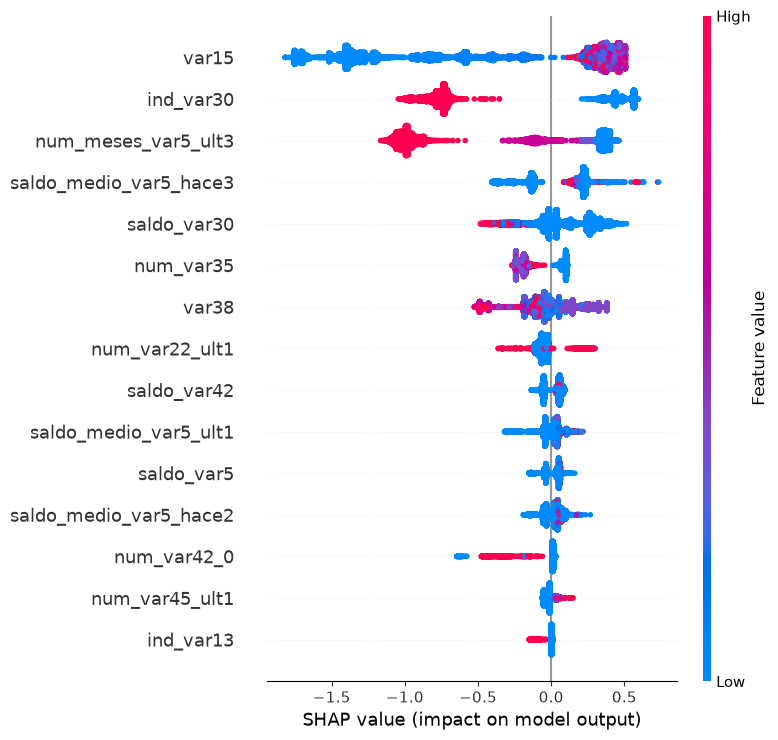

In [144]:
# ==========================================
# 23-3. SHAP Summary Plot
# ==========================================

plt.figure(
    figsize=(10, 7)
)

shap.summary_plot(
    shap_values_final,
    X_test_final,
    show=False
)

plt.tight_layout()
plt.show()

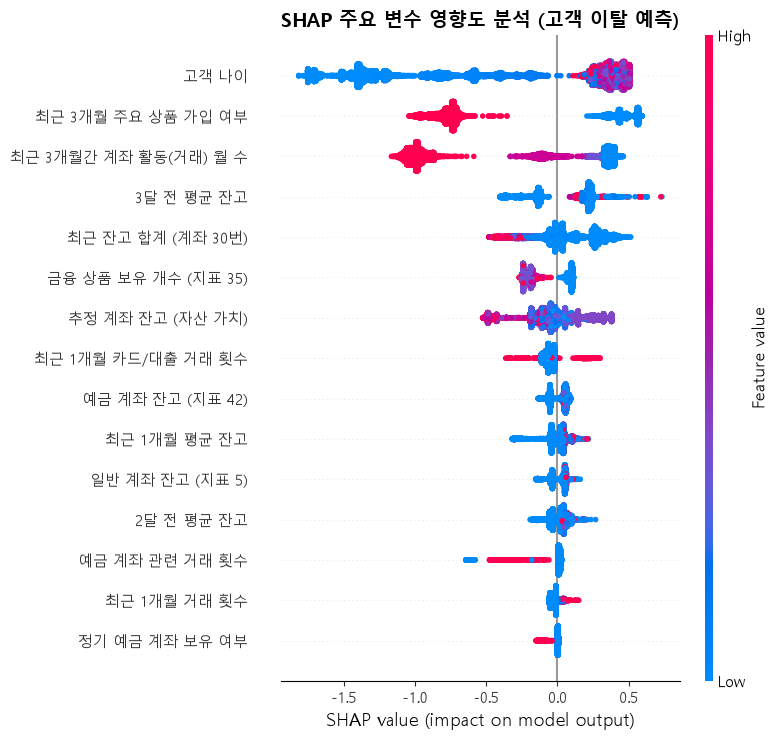

In [193]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

# 1. 한글 폰트 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 기존에 에러 없이 잘 나오던 방식 그대로 SHAP 플롯 그리기
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_final,
    X_test_final,
    show=False)  # 또는 기존에 쓰시던 변수명 그대로 사용

# 3. Y축에 그려진 영문 변수명들을 가져와서 한글로 교체하기
# 현재 그래프에 적힌 Y축 레이블들을 순서대로 읽어옵니다.
current_labels = [item.get_text() for item in plt.gca().get_yticklabels()]

# 각 영문 이름을 우리가 만든 get_korean_name 함수로 변환
korean_labels = [get_korean_name(label) for label in current_labels]

# 변환된 한글 이름으로 Y축 레이블을 다시 지정합니다.
plt.gca().set_yticklabels(korean_labels, fontsize=11)

# 타이틀 및 마무리
plt.title('SHAP 주요 변수 영향도 분석 (고객 이탈 예측)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP 요약 플롯 이미지 저장 완료: figures\shap_summary_plot.png


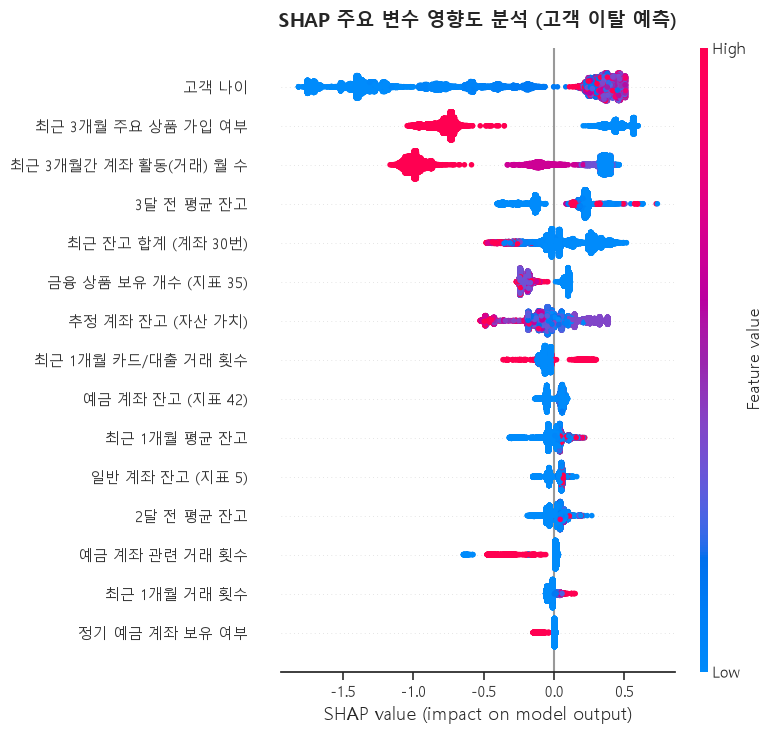

In [214]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap
import os

# 1. 폰트 및 마이너스 기호 깨짐 방지 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. SHAP 플롯 도화지 생성
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_final,
    X_test_final,
    show=False)  # show=False로 설정해야 도화지 제어 가능

# 4. Y축 영문 변수명들을 가져와서 한글로 교체하기
current_labels = [item.get_text() for item in plt.gca().get_yticklabels()]

# get_korean_name 함수를 이용해 한글명으로 변환
korean_labels = [get_korean_name(label) for label in current_labels]

# 변환된 한글 이름으로 Y축 레이블 재지정
plt.gca().set_yticklabels(korean_labels, fontsize=11)

# 타이틀 설정
plt.title('SHAP 주요 변수 영향도 분석 (고객 이탈 예측)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# 5. figures 폴더에 이미지 저장 (plt.show() 전에 실행!)
save_path = os.path.join(output_dir, 'shap_summary_plot.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"SHAP 요약 플롯 이미지 저장 완료: {save_path}")

# 6. 화면 출력
plt.show()

현재 프로젝트의 최종 흐름

313개 변수

→ 통계적 유의성 검정
→ 상관관계 기반 중복 제거
→ LASSO
→ Random Forest
→ XGBoost
→ 여러 방법의 공통 변수 검증
→ 최종 15개 변수

→ SMOTE로 학습 데이터 불균형 처리
→ Logistic Regression baseline
→ XGBoost baseline
→ Leakage-Free Hyperparameter Tuning
→ Tuned XGBoost

→ Threshold 최적화
→ 최종 Threshold = 0.70

→ Test 평가
→ ROC-AUC 0.8172 / PR-AUC 0.1496 / F1 0.2618

→ SHAP
→ 최종 모델의 주요 영향 변수 해석

===== 최종 분석 결과 =====

[1] 데이터 및 변수 선택
- 초기 변수: 313개
- 최종 변수: 15개
- 통계검정, LASSO, Random Forest, XGBoost를 이용한 다단계 변수 선택
- 4개 방법에서 공통적으로 선택된 변수: 13개

[2] 클래스 불균형 처리
- 원본 Train 불만족 비율: 약 3.96%
- SMOTE 적용 후 양/음성 클래스 균형화
- Validation/Test 데이터에는 SMOTE를 적용하지 않음

[3] 모델 성능
- Logistic Regression
  ROC-AUC: 0.7888
  PR-AUC : 0.1234

- Baseline XGBoost
  ROC-AUC: 0.8172
  PR-AUC : 0.1615

- Tuned XGBoost
  Validation ROC-AUC: 0.8208
  Validation PR-AUC : 0.1677

[4] 최종 Test 성능
- ROC-AUC: 0.8172
- PR-AUC : 0.1496
- Precision: 0.1877
- Recall: 0.4326
- F1-score: 0.2618
- 최종 Threshold: 0.70

[5] 모델 해석
- SHAP 분석을 통해 최종 15개 변수의 영향력 확인
- 주요 변수:
  var15
  ind_var30
  num_meses_var5_ult3
  saldo_medio_var5_hace3
  saldo_var30
  num_var35
  var38

본 분석에서는 고객의 불만족 가능성을 사전에 예측하기 위해 통계적 변수 선택과 머신러닝 기반 변수 선택을 단계적으로 수행하였다. 초기 313개의 변수를 15개의 핵심 변수로 축소한 후 SMOTE를 활용하여 클래스 불균형 문제를 완화하였다. Logistic Regression을 baseline으로 설정하고 XGBoost와 비교한 결과, XGBoost가 ROC-AUC와 PR-AUC 측면에서 더 우수한 판별 성능을 보였다. 이후 Leakage-Free 방식으로 하이퍼파라미터를 최적화하여 Validation ROC-AUC 0.8208, PR-AUC 0.1677을 달성하였다. 최종적으로 Test 데이터에서 ROC-AUC 0.8172, PR-AUC 0.1496을 기록하였다.

또한 기본 임계값 0.5를 그대로 사용하는 대신 Validation 데이터에서 threshold를 탐색하여 0.70을 최종 임계값으로 선정하였다. 이를 통해 Test 데이터에서 Precision 0.1877, Recall 0.4326, F1-score 0.2618을 달성하였다. 이는 전체 고객 중 소수인 불만족 고객을 대상으로 무작위로 대응하는 것보다 모델이 상대적으로 높은 불만족 가능성을 가진 고객을 우선적으로 식별하는 데 활용될 수 있음을 의미한다.

마지막으로 SHAP 분석을 통해 모델의 예측에 영향을 미치는 주요 변수를 확인하였다. 특히 var15, ind_var30, num_meses_var5_ult3가 높은 평균 절대 SHAP 값을 보여 최종 모델의 예측에 중요한 역할을 하는 것으로 나타났다. 따라서 본 모델은 단순한 예측 성능뿐만 아니라 어떤 변수들이 고객 불만족 예측에 중요한지를 함께 설명할 수 있다는 장점을 가진다

1. 불만족 클래스 자체가 약 4%로 매우 희소해서 PR-AUC가 ROC-AUC보다 낮게 나타남.
2. Threshold 0.70은 이번 데이터의 Validation 기준으로 결정된 값이므로 실제 운영 환경에서는 비용 구조에 따라 재조정해야 함.
3. SHAP은 예측에 대한 설명이지 인과관계를 의미하지 않음.

# 최종 모델 비교 및 결론

## 1. 모델 성능 비교

| 모델                  | ROC-AUC | PR-AUC | Precision | Recall | F1-score |
| ------------------- | ------: | -----: | --------: | -----: | -------: |
| Logistic Regression |  0.7888 | 0.1234 |    0.0864 | 0.7342 |   0.1546 |
| Baseline XGBoost    |  0.8172 | 0.1615 |    0.1678 | 0.4908 |   0.2501 |
| Tuned XGBoost       |  0.8172 | 0.1496 |    0.1877 | 0.4326 |   0.2618 |

Logistic Regression 대비 Baseline XGBoost는 ROC-AUC가 0.0284, PR-AUC가 0.0381 개선되었다. 이는 XGBoost가 불만족 고객과 만족 고객을 구분하는 데 Logistic Regression보다 우수한 성능을 보였음을 의미한다.

이후 Leakage-Free 방식으로 XGBoost의 하이퍼파라미터를 최적화한 결과 Validation 데이터에서 ROC-AUC 0.8208, PR-AUC 0.1677을 달성하였다. 최종 Test 데이터에서는 ROC-AUC 0.8172, PR-AUC 0.1496을 기록하였다.

최종 XGBoost는 Baseline XGBoost와 비교하여 Test 기준 Precision이 0.0199, F1-score가 0.0117 개선되었다. 반면 Recall은 감소하였다. 따라서 최종 모델은 모든 평가 지표가 동시에 개선된 것이 아니라, 높은 Precision과 F1-score를 확보하는 방향으로 예측 기준을 조정한 모델로 해석하는 것이 적절하다.

## 2. 최종 모델 선정

본 분석에서는 최종 모델로 Tuned XGBoost를 선정하였다.

XGBoost는 Logistic Regression보다 높은 ROC-AUC와 PR-AUC를 나타냈으며, 비선형적인 변수 관계와 변수 간 상호작용을 반영할 수 있다는 장점이 있다. 또한 SHAP 분석을 통해 모델의 예측에 영향을 미치는 주요 변수를 해석할 수 있어 단순한 예측 모델을 넘어 설명 가능한 분석이 가능하다.

최종 Test 데이터에서의 성능은 다음과 같다.

* ROC-AUC: 0.8172
* PR-AUC: 0.1496
* Precision: 0.1877
* Recall: 0.4326
* F1-score: 0.2618
* Accuracy: 0.9036

최종 Threshold는 Validation 데이터에서 F1-score를 기준으로 0.70으로 선정하였다.

## 3. 불만족 고객 식별 결과

최종 Test 데이터에서 실제 불만족 고객은 601명이었으며, Threshold 0.70을 적용한 결과 260명을 불만족 고객으로 정확하게 식별하였다.

동시에 1,125명의 만족 고객을 불만족으로 잘못 분류하였다. 따라서 본 모델은 모든 불만족 고객을 탐지하는 모델이라기보다는, 전체 고객 중 상대적으로 불만족 가능성이 높은 고객을 선별하여 우선적인 관리 대상으로 지정하는 용도로 활용하는 것이 적합하다.

## 4. 주요 변수 해석

SHAP 분석 결과 최종 모델의 예측에 가장 큰 영향을 미친 변수는 다음과 같다.

1. `var15`
2. `ind_var30`
3. `num_meses_var5_ult3`
4. `saldo_medio_var5_hace3`
5. `saldo_var30`
6. `num_var35`
7. `var38`

특히 `var15`, `ind_var30`, `num_meses_var5_ult3`는 다른 변수에 비해 평균 절대 SHAP 값이 크게 나타나 최종 모델의 예측에 중요한 역할을 하는 것으로 확인되었다.

다만 SHAP 값은 모델의 예측에 대한 기여도를 의미하므로, 해당 변수와 고객 불만족 사이의 인과관계를 의미하는 것은 아니다.

## 5. 최종 결론

본 분석은 313개의 초기 변수를 대상으로 통계적 유의성 검정, 상관관계 기반 중복 제거, LASSO, Random Forest, XGBoost를 단계적으로 적용하여 최종 15개의 변수를 선정하였다.

또한 약 4% 수준의 불만족 고객 비율로 인해 발생하는 심각한 클래스 불균형 문제를 SMOTE를 통해 학습 데이터에서 보완하였다. 이후 Logistic Regression을 baseline으로 설정하고 XGBoost와 비교하여 모델 성능을 검증하였다.

최종적으로 Tuned XGBoost는 Test 데이터에서 ROC-AUC 0.8172를 기록하여 만족 고객과 불만족 고객을 비교적 효과적으로 구분하였다. 또한 Threshold를 0.70으로 조정함으로써 Precision 0.1877, Recall 0.4326, F1-score 0.2618을 달성하였다.

따라서 본 모델은 고객 불만족 여부를 단순히 분류하는 것보다, 불만족 가능성이 높은 고객을 사전에 식별하고 해당 고객에게 우선적으로 관리 또는 예방적 대응을 수행하기 위한 분석 도구로 활용하는 것이 적절하다.


In [148]:
from lightgbm import LGBMClassifier

# 1. LightGBM 모델 객체 생성
# n_estimators, learning_rate 등은 필요에 따라 조절 가능합니다.
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 2. 모델 학습 (훈련 데이터 활용)
# early_stopping 등이 필요할 경우 eval_set을 추가할 수 있습니다.
lgb_model.fit(X_train, y_train)

# 3. 테스트 데이터에 대한 양성 클래스(1) 예측 확률 구하기
# (이후 ROC 곡선 및 AUC 점수 계산에 사용됩니다)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM 모델 학습 및 예측 완료!")

[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233
LightGBM 모델 학습 및 예측 완료!


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233


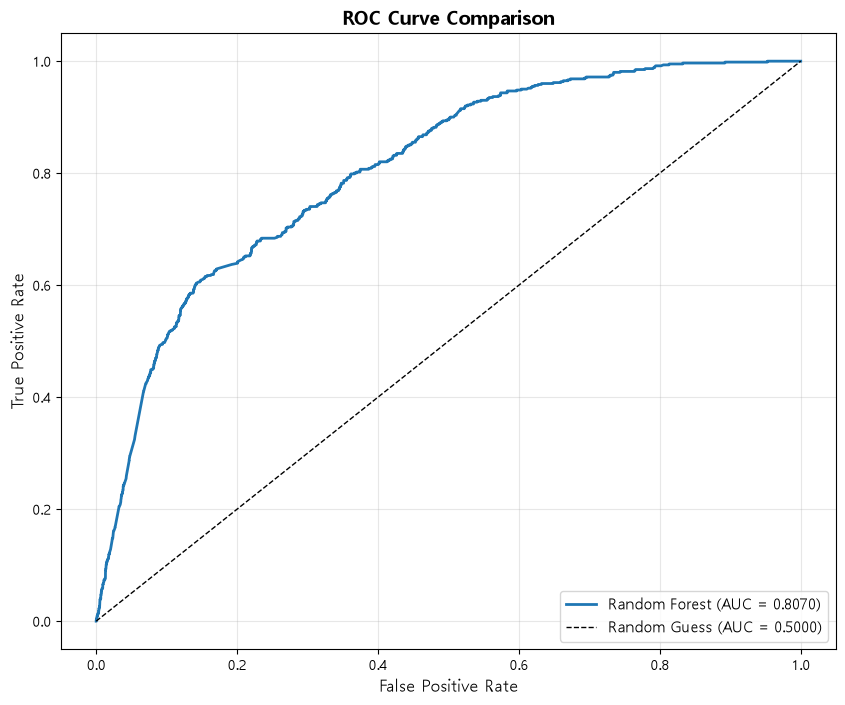

In [195]:

logistic_baseline.fit(X_train.values, y_train)
rf_model.fit(X_train.values, y_train)
xgb_model.fit(X_train.values, y_train)
lgb_model.fit(X_train.values, y_train)

# 2. 예측 확률 구할 때도 .values 사용하기
models = {
  
    'Random Forest': rf_model,
   
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # X_test 대신 X_test.values 사용
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233


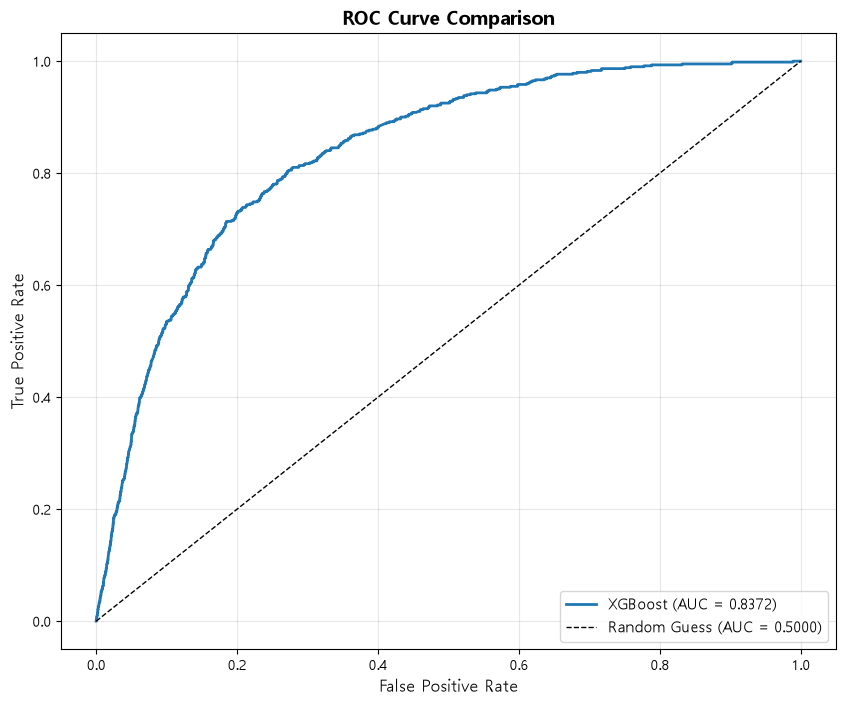

In [196]:
# XGBOOST

# 1. 모델 학습 시 .values를 붙여 컬럼 이름 종속성 없애기
logistic_baseline.fit(X_train.values, y_train)
rf_model.fit(X_train.values, y_train)
xgb_model.fit(X_train.values, y_train)
lgb_model.fit(X_train.values, y_train)

# 2. 예측 확률 구할 때도 .values 사용하기
models = {
    
    'XGBoost': xgb_model,
    
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # X_test 대신 X_test.values 사용
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045717 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233


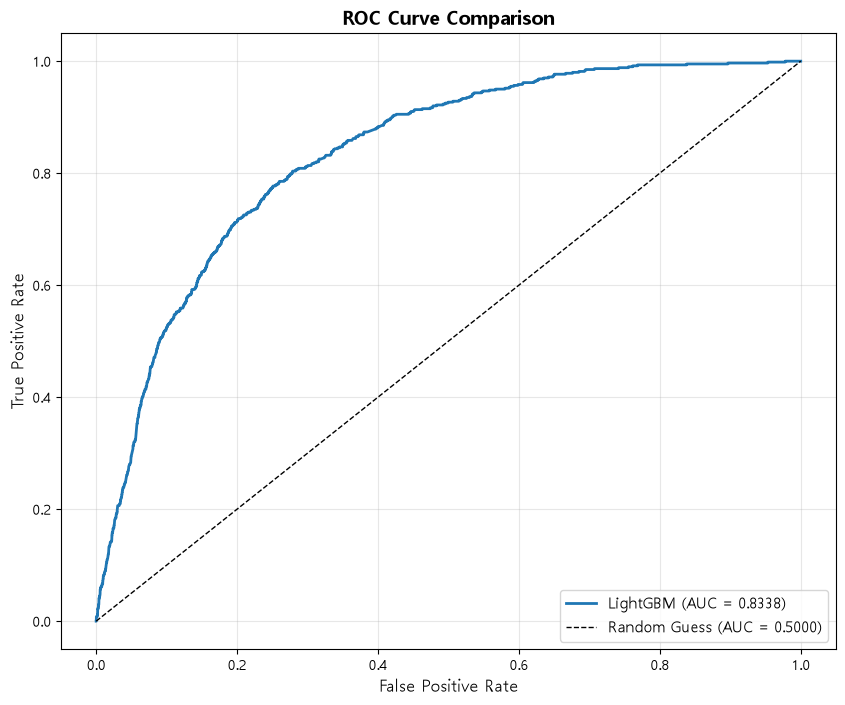

In [197]:
# lightGBM

# 1. 모델 학습 시 .values를 붙여 컬럼 이름 종속성 없애기
logistic_baseline.fit(X_train.values, y_train)
rf_model.fit(X_train.values, y_train)
xgb_model.fit(X_train.values, y_train)
lgb_model.fit(X_train.values, y_train)

# 2. 예측 확률 구할 때도 .values 사용하기
models = {
   
    'LightGBM': lgb_model
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # X_test 대신 X_test.values 사용
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233


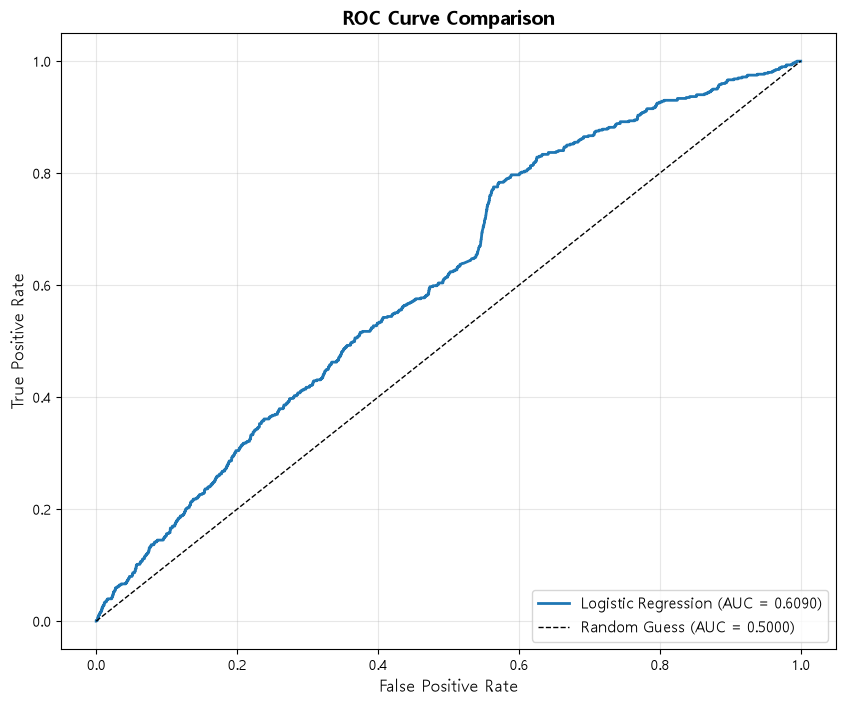

In [194]:
# 로지스틱

# 1. 모델 학습 시 .values를 붙여 컬럼 이름 종속성 없애기

logistic_baseline.fit(X_train.values, y_train)
rf_model.fit(X_train.values, y_train)
xgb_model.fit(X_train.values, y_train)
lgb_model.fit(X_train.values, y_train)

# 2. 예측 확률 구할 때도 .values 사용하기
models = {
    'Logistic Regression': logistic_baseline,
    
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # X_test 대신 X_test.values 사용
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1805, number of negative: 43807
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13539
[LightGBM] [Info] Number of data points in the train set: 45612, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039573 -> initscore=-3.189233
[LightGBM] [Info] Start training from score -3.189233


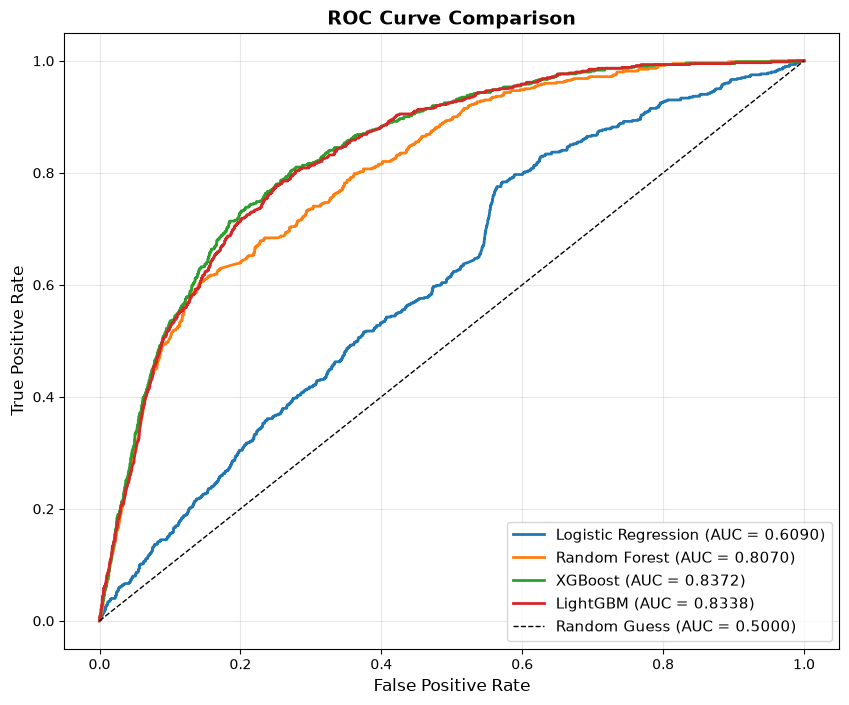

In [151]:
# 1. 모델 학습 시 .values를 붙여 컬럼 이름 종속성 없애기
logistic_baseline.fit(X_train.values, y_train)
rf_model.fit(X_train.values, y_train)
xgb_model.fit(X_train.values, y_train)
lgb_model.fit(X_train.values, y_train)

# 2. 예측 확률 구할 때도 .values 사용하기
models = {
    'Logistic Regression': logistic_baseline,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # X_test 대신 X_test.values 사용
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [168]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 폰트 설정
mpl.rc('font', family='Malgun Gothic') 
# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

In [176]:
# SHAP 중요도 및 추가 요청된 모든 변수 한글 매핑 사전
feature_name_mapping = {
    # 기존 변수들
    'var15': '고객 나이',
    'ind_var30': '최근 3개월 주요 상품 가입 여부',
    'num_meses_var5_ult3': '최근 3개월간 계좌 활동(거래) 월 수',
    'saldo_medio_var5_hace3': '3달 전 평균 잔고',
    'saldo_var30': '최근 잔고 합계 (계좌 30번)',
    'num_var35': '금융 상품 보유 개수 (지표 35)',
    'var38': '추정 계좌 잔고 (자산 가치)',
    'num_var22_ult1': '최근 1개월 카드/대출 거래 횟수',
    'num_var22_hace3': '과거 3개월 전 카드/대출 거래 횟수',
    'saldo_var42': '예금 계좌 잔고 (지표 42)',
    'saldo_medio_var5_ult1': '최근 1개월 평균 잔고',
    'saldo_var5': '일반 계좌 잔고 (지표 5)',
    'saldo_medio_var5_hace2': '2달 전 평균 잔고',
    'num_var42_0': '예금 계좌 관련 거래 횟수',
    'num_var45_ult1': '최근 1개월 거래 횟수',
    'ind_var13': '정기 예금 계좌 보유 여부',
    'num_var45_hace3': '3달 전 일반 거래 횟수',
    'num_var22_ult3': '최근 3개월 카드/대출 거래 횟수',
    'num_var45_hace2': '2달 전 일반 거래 횟수',
    'num_45_hace2': '2달 전 일반 거래 횟수',
    'imp_trans_var37_ult1': '최근 1개월 계좌 이체/거래 금액',
    'saldo_medio_var5_ult3': '최근 3개월 평균 잔고',
    
    # 새로 추가된 1년 증감률(delta) 변수들
    'delta_imp_aport_var13_1y3': '전년 대비 13번 계좌 납입 금액 증감률',
    'delta_num_aport_var13_1y3': '전년 대비 13번 계좌 납입 횟수 증감률',
    'delta_num_venta_var44_1y3': '전년 대비 44번 상품 판매 횟수 증감률',
    'delta_imp_venta_var44_1y3': '전년 대비 44번 상품 판매 금액 증감률',
    'delta_num_compra_var44_1y3': '전년 대비 44번 상품 매입 횟수 증감률',
    'delta_imp_compra_var44_1y3': '전년 대비 44번 상품 매입 금액 증감률',
    'delta_num_aport_var17_1y3': '전년 대비 17번 계좌 납입 횟수 증감률',
    'delta_imp_aport_var17_1y3': '전년 대비 17번 계좌 납입 금액 증감률',
    'delta_imp_reemb_var13_1y3': '전년 대비 13번 계좌 환급 금액 증감률',
    'delta_num_reemb_var13_1y3': '전년 대비 13번 계좌 환급 횟수 증감률'
}

# 변환 함수 정의
def get_korean_name(col_name):
    return feature_name_mapping.get(col_name, col_name)

===== 불만족 고객(1) vs 만족 고객(0) 평균 차이가 큰 주요 변수 Top 10 =====


,만족 (0),불만족 (1),평균 차이 (절대값)
전년 대비 13번 계좌 납입 금액 증감률,4.985482e+07,1.994681e+07,2.990801e+07
전년 대비 13번 계좌 납입 횟수 증감률,4.985482e+07,1.994681e+07,2.990801e+07
전년 대비 44번 상품 판매 횟수 증감률,5.752479e+06,0.000000e+00,5.752479e+06
전년 대비 44번 상품 판매 금액 증감률,5.752479e+06,0.000000e+00,5.752479e+06
전년 대비 44번 상품 매입 횟수 증감률,9.313537e+06,6.648936e+06,2.664601e+06
전년 대비 44번 상품 매입 금액 증감률,9.313537e+06,6.648936e+06,2.664601e+06
전년 대비 17번 계좌 납입 횟수 증감률,5.204624e+06,3.324468e+06,1.880156e+06
전년 대비 17번 계좌 납입 금액 증감률,5.204624e+06,3.324468e+06,1.880156e+06
전년 대비 13번 계좌 환급 금액 증감률,5.067660e+06,3.324468e+06,1.743192e+06
전년 대비 13번 계좌 환급 횟수 증감률,5.067660e+06,3.324468e+06,1.743192e+06


<Figure size 1200x600 with 0 Axes>

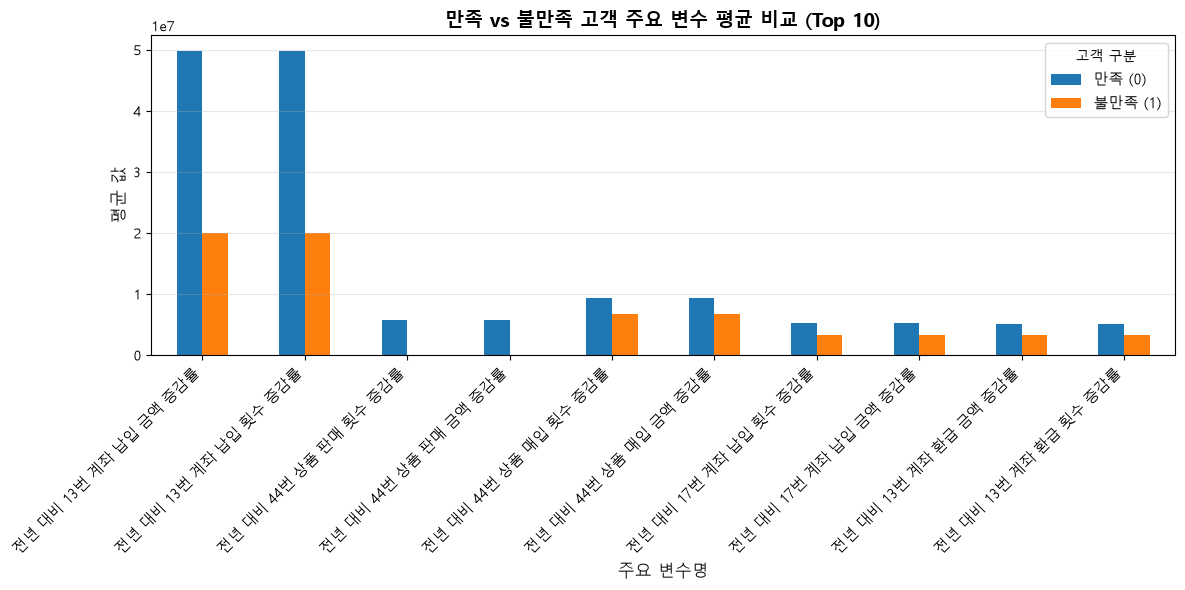

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 1. 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. TARGET별 평균값 비교
mean_by_target = df_clean.groupby('TARGET').mean()

# 만족(0)과 불만족(1) 간의 평균 차이가 가장 큰 상위 10개 변수 추출
mean_diff = (mean_by_target.loc[1] - mean_by_target.loc[0]).abs()
top_features = mean_diff.nlargest(10).index

# 3. 상위 10개 변수에 대한 그룹별 평균 비교 표 생성
comparison_df = mean_by_target[top_features].T
comparison_df.columns = ['만족 (0)', '불만족 (1)']
comparison_df['평균 차이 (절대값)'] = (comparison_df['불만족 (1)'] - comparison_df['만족 (0)']).abs()

# ★ 인덱스(영문 변수명)를 한글 이름으로 변환
comparison_df.index = [get_korean_name(col) for col in comparison_df.index]

print("===== 불만족 고객(1) vs 만족 고객(0) 평균 차이가 큰 주요 변수 Top 10 =====")
display(comparison_df.sort_values(by='평균 차이 (절대값)', ascending=False))

# 4. 시각화: 한글 레이블이 적용된 바 차트
plt.figure(figsize=(12, 6))
# pandas plot에 직접 한글 인덱스가 반영된 데이터프레임 전달
ax = comparison_df[['만족 (0)', '불만족 (1)']].plot(kind='bar', figsize=(12, 6))

plt.title('만족 vs 불만족 고객 주요 변수 평균 비교 (Top 10)', fontsize=14, fontweight='bold')
plt.ylabel('평균 값', fontsize=12)
plt.xlabel('주요 변수명', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='고객 구분', fontsize=11)
plt.tight_layout()
plt.show()

===== 불만족 고객(1) vs 만족 고객(0) 평균 차이가 큰 주요 변수 Top 10 =====


,만족 (0),불만족 (1),평균 차이 (절대값)
전년 대비 13번 계좌 납입 금액 증감률,4.985482e+07,1.994681e+07,2.990801e+07
전년 대비 13번 계좌 납입 횟수 증감률,4.985482e+07,1.994681e+07,2.990801e+07
전년 대비 44번 상품 판매 횟수 증감률,5.752479e+06,0.000000e+00,5.752479e+06
전년 대비 44번 상품 판매 금액 증감률,5.752479e+06,0.000000e+00,5.752479e+06
전년 대비 44번 상품 매입 횟수 증감률,9.313537e+06,6.648936e+06,2.664601e+06
전년 대비 44번 상품 매입 금액 증감률,9.313537e+06,6.648936e+06,2.664601e+06
전년 대비 17번 계좌 납입 횟수 증감률,5.204624e+06,3.324468e+06,1.880156e+06
전년 대비 17번 계좌 납입 금액 증감률,5.204624e+06,3.324468e+06,1.880156e+06
전년 대비 13번 계좌 환급 금액 증감률,5.067660e+06,3.324468e+06,1.743192e+06
전년 대비 13번 계좌 환급 횟수 증감률,5.067660e+06,3.324468e+06,1.743192e+06


평균 비교 바 차트 이미지 저장 완료: figures\eda_top10_mean_comparison_bar.png


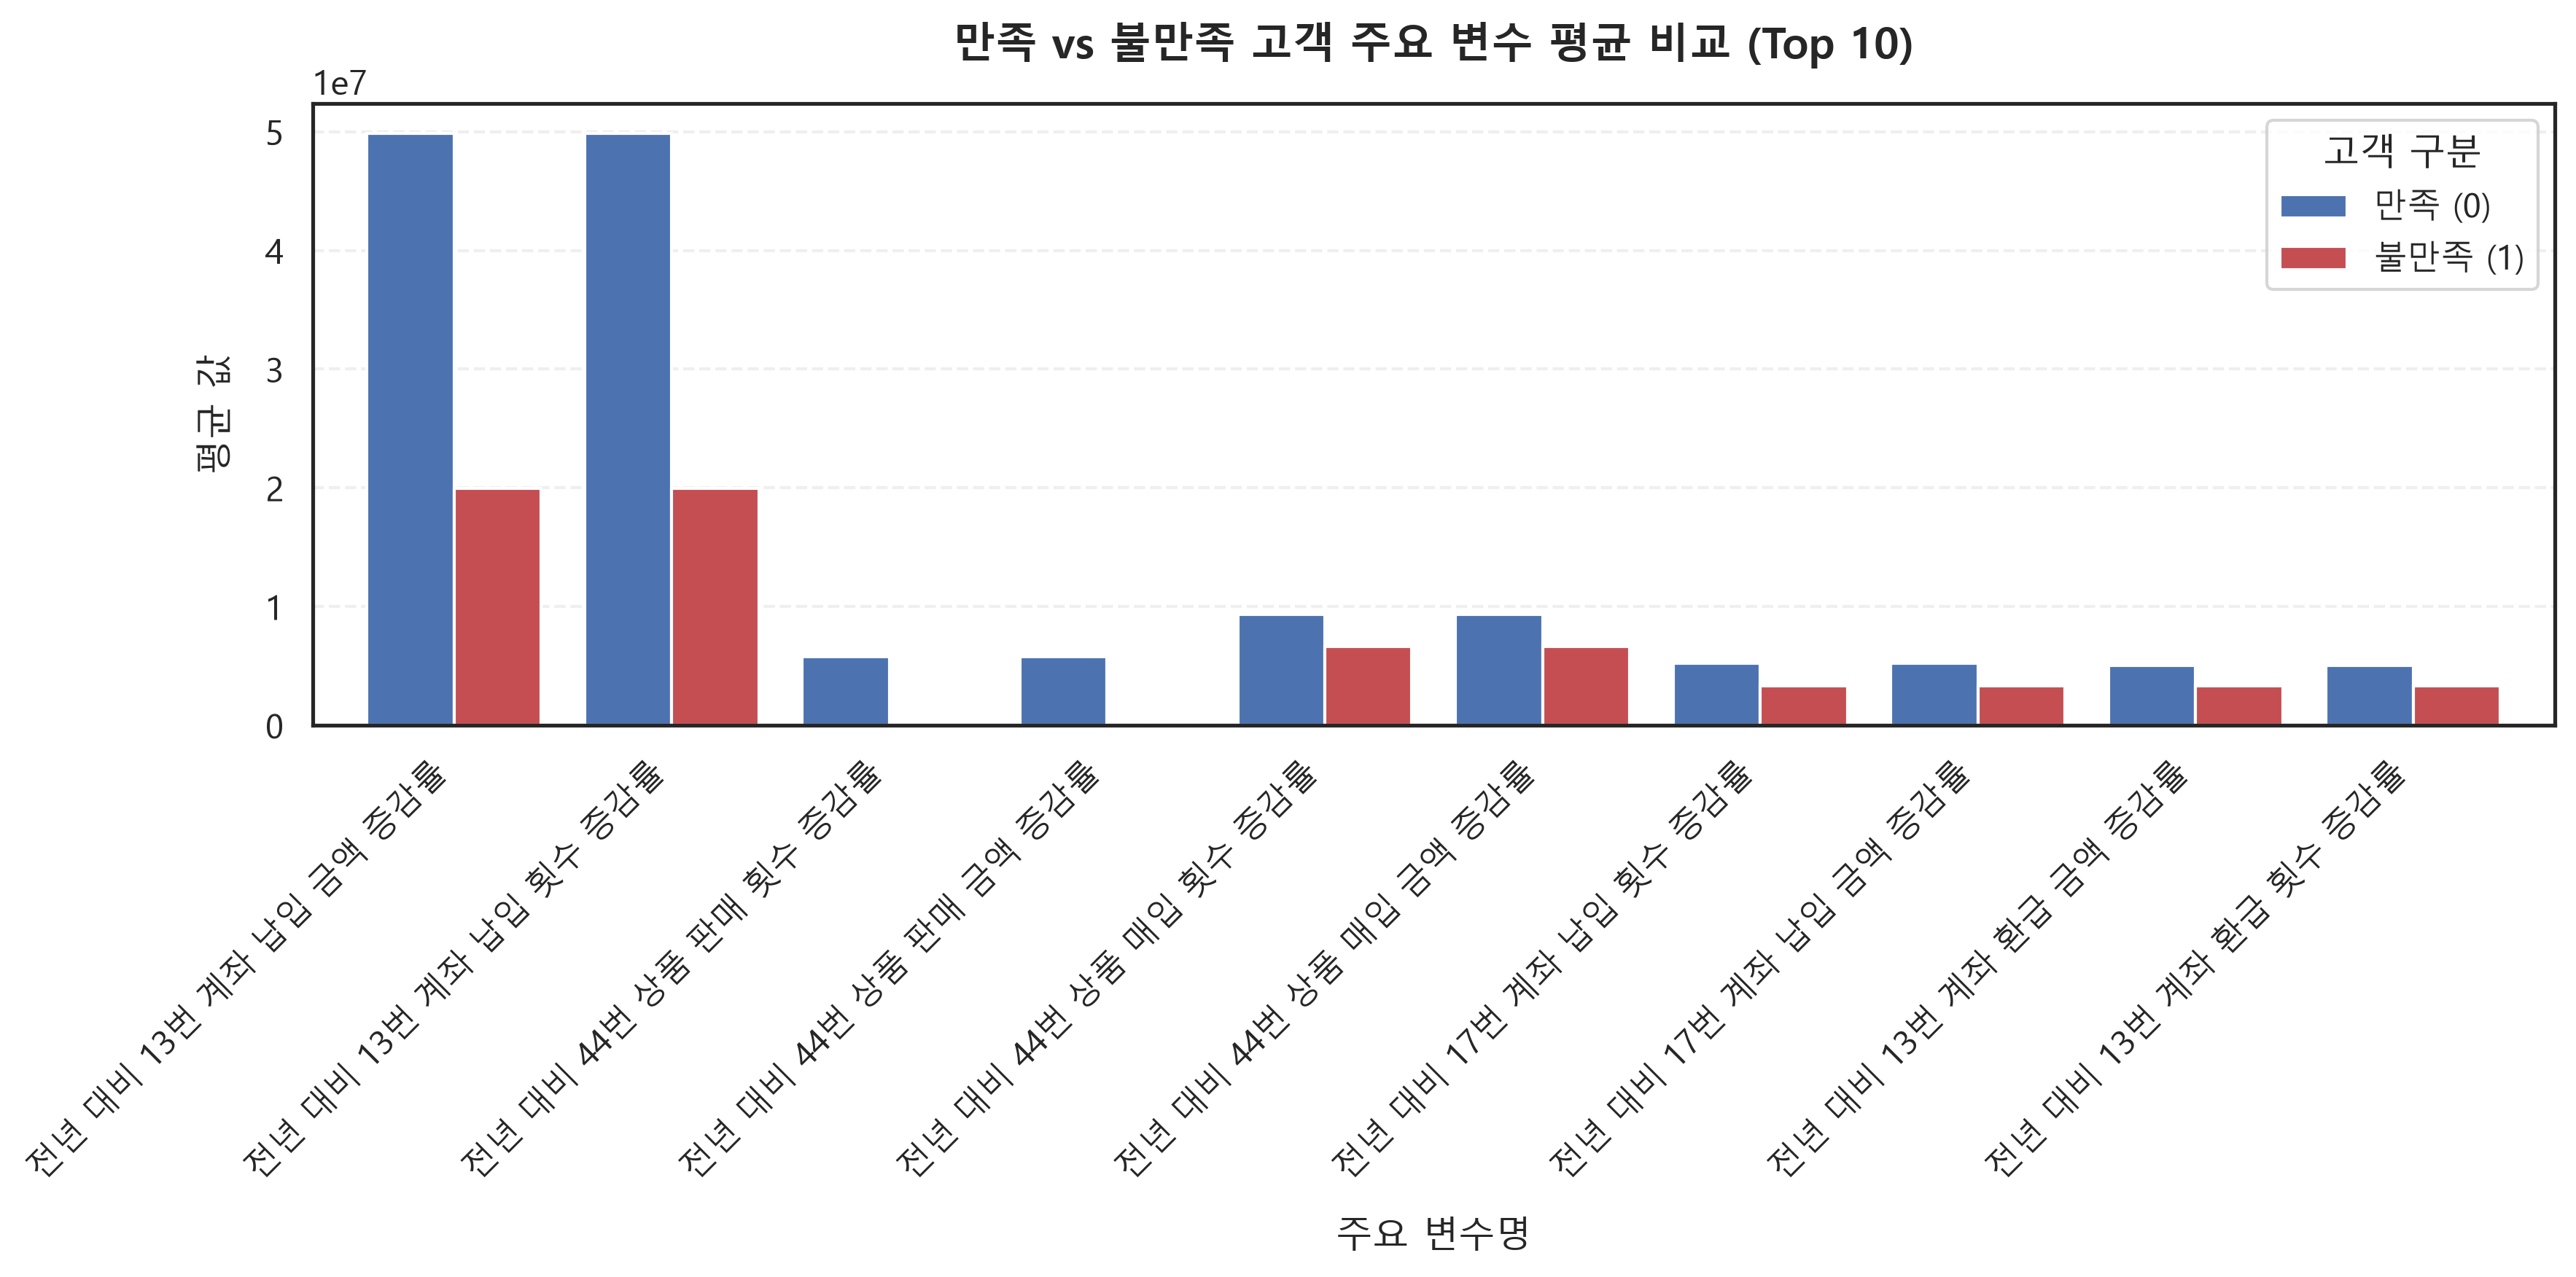

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

# 1. 폰트 및 마이너스 기호 깨짐 방지 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. TARGET별 평균값 비교 및 상위 10개 변수 추출
mean_by_target = df_clean.groupby('TARGET').mean()

# 만족(0)과 불만족(1) 간의 평균 차이가 가장 큰 상위 10개 변수 추출
mean_diff = (mean_by_target.loc[1] - mean_by_target.loc[0]).abs()
top_features = mean_diff.nlargest(10).index

# 4. 상위 10개 변수에 대한 그룹별 평균 비교 표 생성
comparison_df = mean_by_target[top_features].T
comparison_df.columns = ['만족 (0)', '불만족 (1)']
comparison_df['평균 차이 (절대값)'] = (comparison_df['불만족 (1)'] - comparison_df['만족 (0)']).abs()

# 인덱스(영문 변수명)를 한글 이름으로 변환
comparison_df.index = [get_korean_name(col) for col in comparison_df.index]

print("===== 불만족 고객(1) vs 만족 고객(0) 평균 차이가 큰 주요 변수 Top 10 =====")
display(comparison_df.sort_values(by='평균 차이 (절대값)', ascending=False))

# 5. 시각화: 한글 레이블이 적용된 바 차트 그리기
# pandas plot은 ax 객체를 반환하므로 이를 활용하여 figure를 제어합니다.
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

comparison_df[['만족 (0)', '불만족 (1)']].plot(
    kind='bar', 
    ax=ax, 
    color=['#4C72B0', '#C44E52'], # 만족(블루), 불만족(레드) 색상 매칭
    width=0.8
)

# 타이틀 및 축 레이블 설정
ax.set_title('만족 vs 불만족 고객 주요 변수 평균 비교 (Top 10)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('평균 값', fontsize=12, labelpad=10)
ax.set_xlabel('주요 변수명', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(11)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(title='고객 구분', fontsize=11, frameon=True)

# 6. figures 폴더에 고해상도 이미지 저장 (plt.show() 전 실행)
save_path = os.path.join(output_dir, 'eda_top10_mean_comparison_bar.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"평균 비교 바 차트 이미지 저장 완료: {save_path}")

# 7. 화면 출력
plt.tight_layout()
plt.show()

예를 들어 delta_imp_aport_var13_1y3는 특정 상품(계좌)에 대한 1년 전 대비 최근의 납입(aport) 금액 변화율을 뜻한다.

이 변수들은 데이터의 특성상 은행 시스템에서 거래가 거의 없거나 특정 이벤트가 발생하지 않은 대다수 고객에게 매우 큰 값(예: 999999 등 결측/무한대 대치 코드나 극단적인 스케일)이 기본값으로 들어가 있는 경우가 많다.

2. 만족(0) vs 불만족(1) 그룹 비교
수치적 차이의 의미:

delta_imp_aport_var13_1y3 등의 변수에서 만족 고객(0)은 평균값이 약 4,985만인 반면, 불만족 고객(1)은 약 1,994만으로 큰 차이를 보인다.

이는 불만족 고객들이 특정 금융 상품(예: 예금, 펀드, 채권 등)의 거래 이력이나 변동 추이에서 만족 고객들과는 다른 패턴(거래를 아예 안 하거나, 반대로 급격히 줄이는 등의 행동 양상)을 보이고 있다.

In [153]:
# 분석해보고 싶은 특정 변수 지정 (예시로 'var38' 사용, 다른 변수로 변경 가능)
target_feature = 'var38' 

if target_feature in df_clean.columns:
    # 데이터를 분위수(Quantile) 기준으로 5개 구간으로 나누어 불만족 비율 확인
    df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')
    
    # 구간별 불만족 고객(TARGET=1)의 비율 계산
    bin_stat = df_clean.groupby('bin')['TARGET'].agg(
        Total_Count='count',
        Unsatisfied_Count=lambda x: (x == 1).sum(),
        Unsatisfied_Ratio=lambda x: (x == 1).mean()
    )
    
    print(f"===== '{target_feature}' 구간별 불만족 고객 비율 통계 =====")
    display(bin_stat)
    
    # 임시로 만든 'bin' 컬럼 삭제
    df_clean.drop(columns=['bin'], inplace=True)
else:
    print(f"'{target_feature}' 변수가 데이터프레임에 존재하지 않습니다.")

===== 'var38' 구간별 불만족 고객 비율 통계 =====


C:\Users\mega\AppData\Local\Temp\ipykernel_16716\2994758962.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stat = df_clean.groupby('bin')['TARGET'].agg(


,Total_Count,Unsatisfied_Count,Unsatisfied_Ratio
bin,,,
"(5163.749, 61496.916]",15204,883,0.058077
"(61496.916, 88571.67]",15204,664,0.043673
"(88571.67, 117310.979]",26161,981,0.037499
"(117310.979, 132859.344]",4247,123,0.028962
"(132859.344, 22034738.76]",15204,357,0.023481


출력 결과를 보면 var38 값이 낮을수록(5163 ~ 61496 구간) 불만족 고객 비율이 약 5.8%로 가장 높고, 값이 커질수록 불만족 비율이 점차 줄어드는(0.023까지) 뚜렷한 경향을 확인할 수 있다.

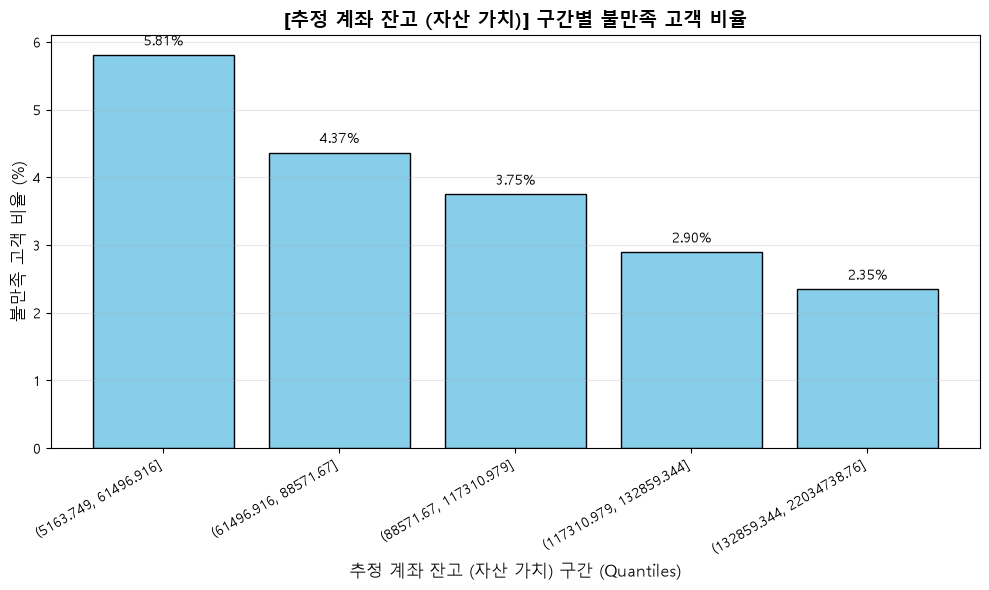

In [179]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 분석할 특정 변수 지정 (예: 'var38')
target_feature = 'var38'
korean_feature_name = get_korean_name(target_feature) # 한글 이름 가져오기

# 3. 구간별 통계 계산
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 4. 시각화 (구간별 불만족 고객 비율)
plt.figure(figsize=(10, 6))
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = plt.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='skyblue', edgecolor='black')

# 그래프 타이틀 및 축 레이블에 한글 반영
plt.title(f'[{korean_feature_name}] 구간별 불만족 고객 비율', fontsize=14, fontweight='bold')
plt.xlabel(f'{korean_feature_name} 구간 (Quantiles)', fontsize=12)
plt.ylabel('불만족 고객 비율 (%)', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3)

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 5. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

구간별 비율 분석 이미지 저장 완료: figures\eda_bin_ratio_var38.png


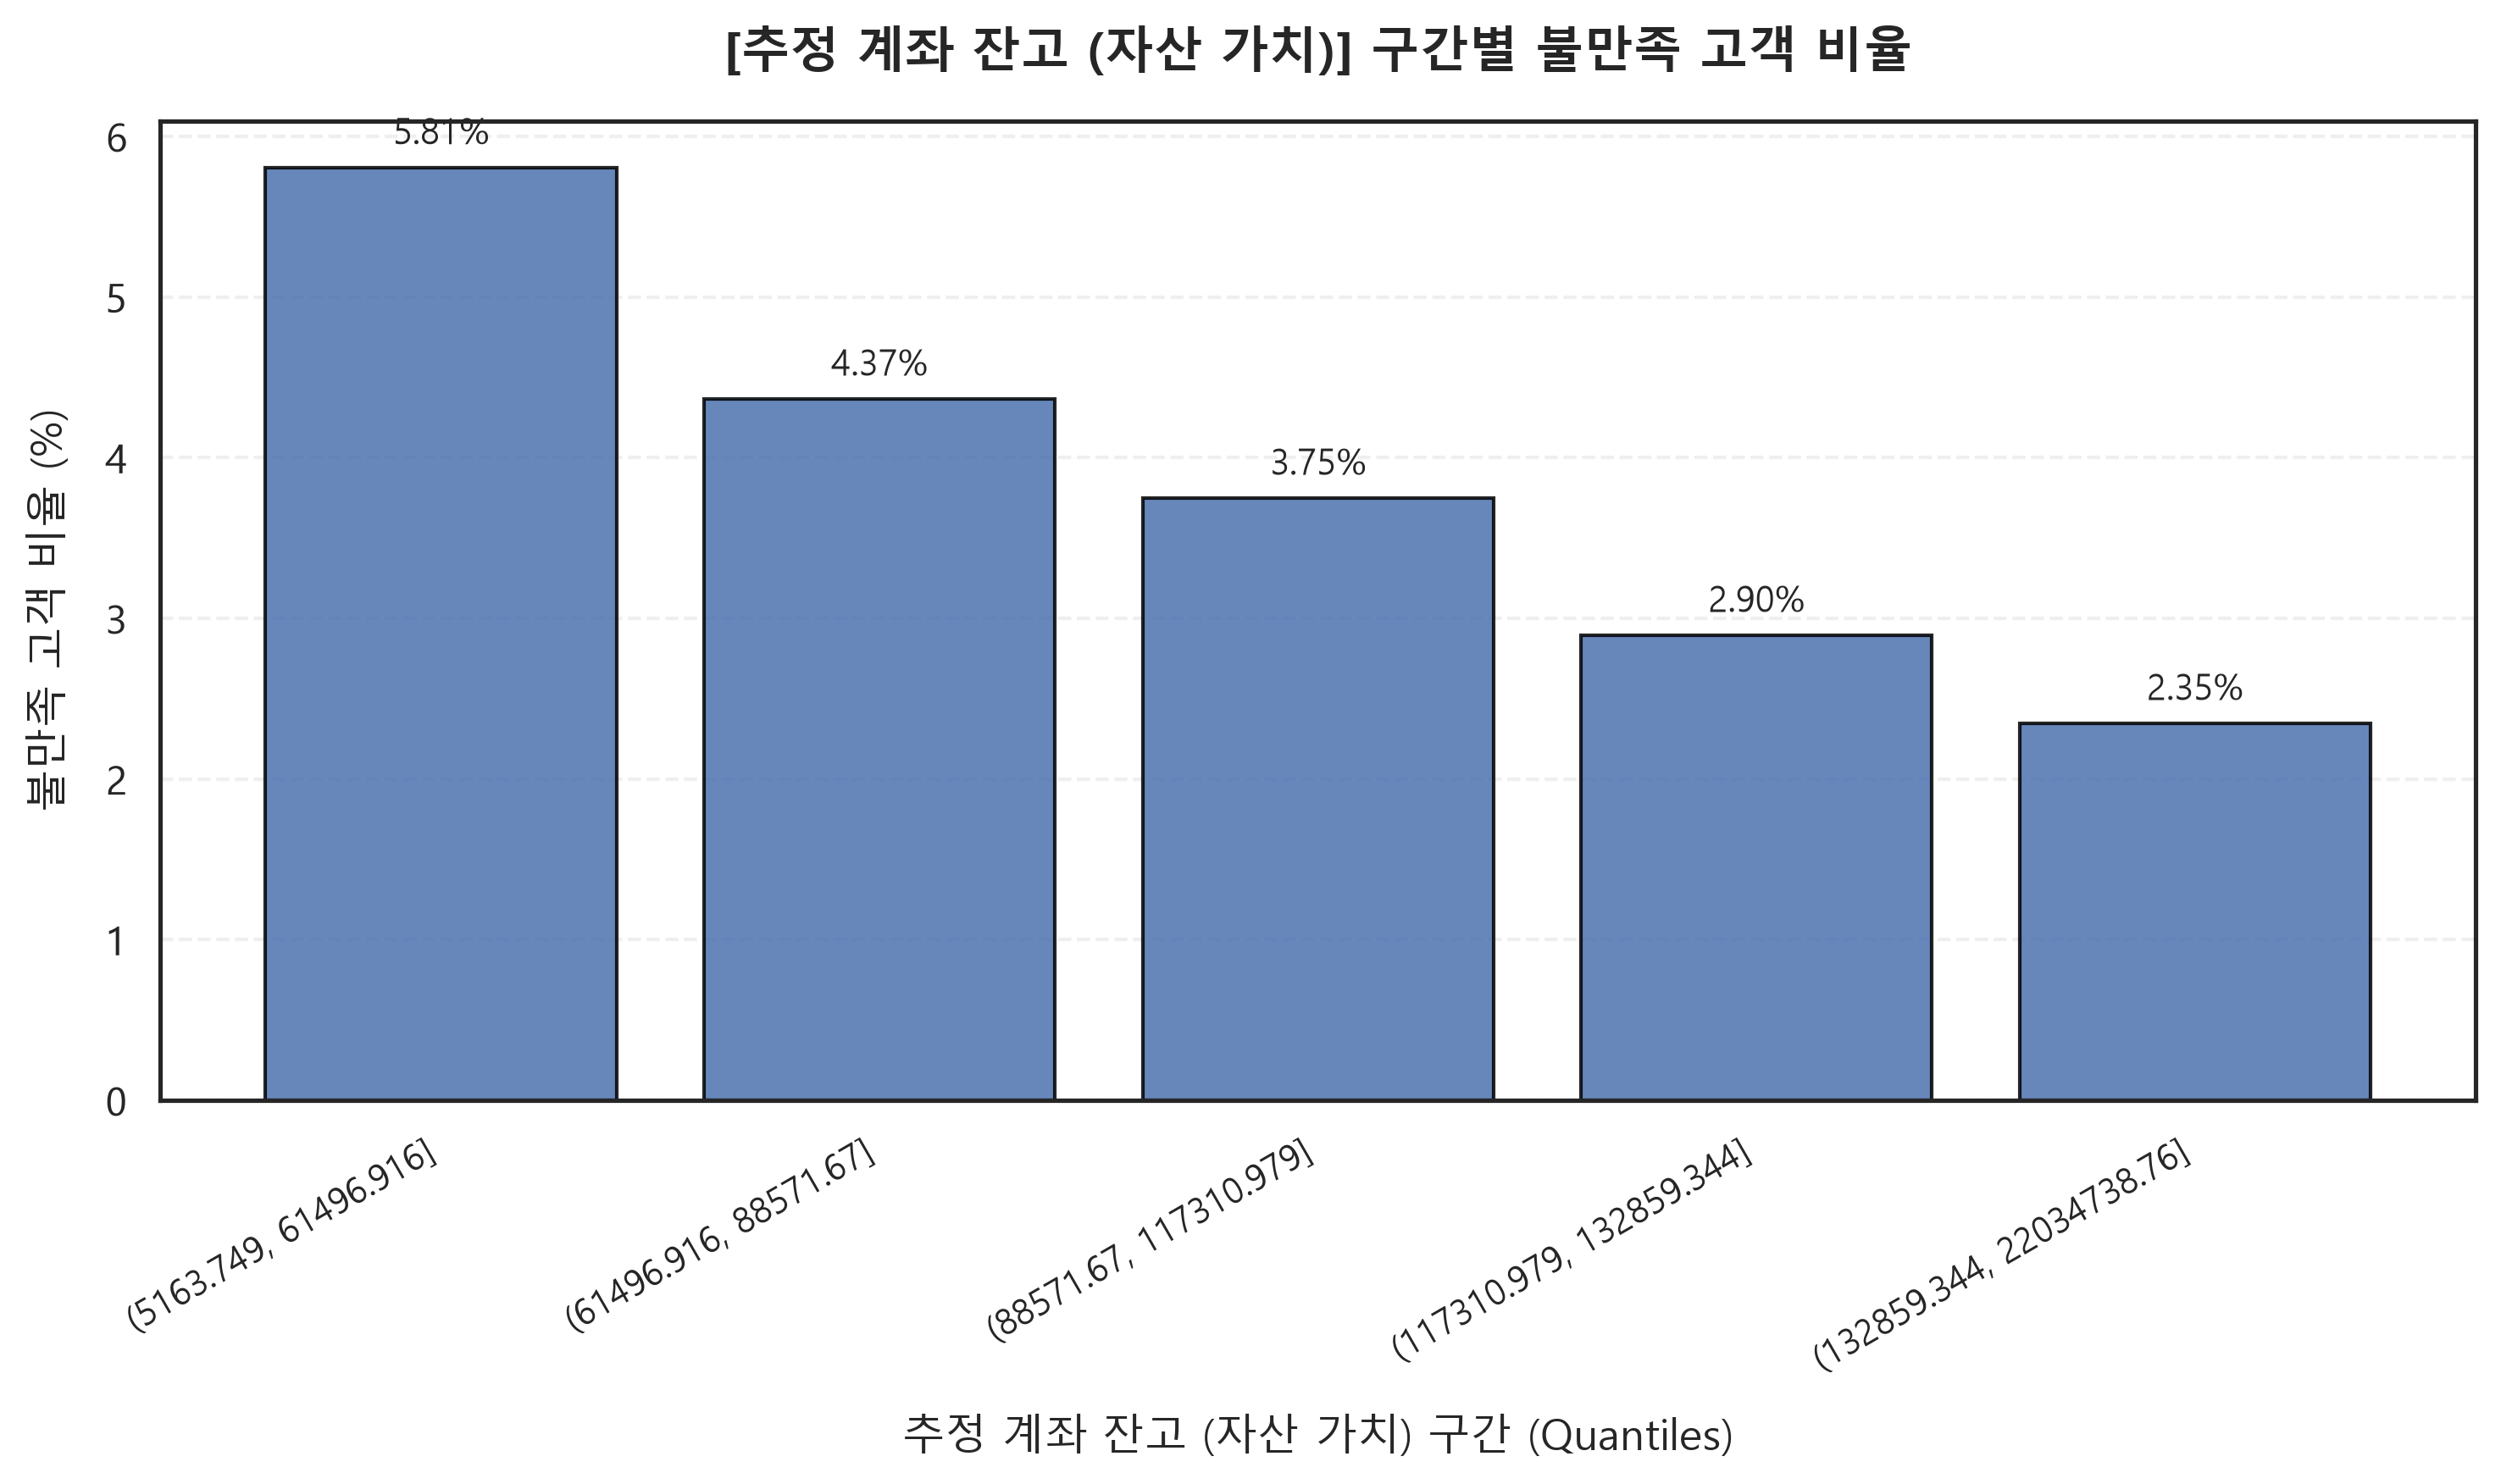

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

# 1. 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 분석할 특정 변수 지정 (예: 'var38')
target_feature = 'var38'
korean_feature_name = get_korean_name(target_feature) # 한글 이름 가져오기

# 4. 구간별 통계 계산
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 5. 시각화 (구간별 불만족 고객 비율) - 객체 지향형 구조로 변경
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = ax.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='#4C72B0', edgecolor='black', alpha=0.85)

# 그래프 타이틀 및 축 레이블 설정
ax.set_title(f'[{korean_feature_name}] 구간별 불만족 고객 비율', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'{korean_feature_name} 구간 (Quantiles)', fontsize=12, labelpad=10)
ax.set_ylabel('불만족 고객 비율 (%)', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(10)

ax.grid(axis='y', alpha=0.3, linestyle='--')

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

# 6. figures 폴더에 고해상도 이미지 저장 (plt.show() 전 실행)
# 파일명에 변수명을 포함시켜 여러 변수를 분석할 때 덮어씌워지지 않게 관리합니다.
save_path = os.path.join(output_dir, f'eda_bin_ratio_{target_feature}.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"구간별 비율 분석 이미지 저장 완료: {save_path}")

# 7. 화면 출력
plt.tight_layout()
plt.show()

# 8. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

In [155]:
# 분석해보고 싶은 특정 변수 지정 (예시로 'var38' 사용, 다른 변수로 변경 가능)
target_feature = 'var15' 

if target_feature in df_clean.columns:
    # 데이터를 분위수(Quantile) 기준으로 5개 구간으로 나누어 불만족 비율 확인
    df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')
    
    # 구간별 불만족 고객(TARGET=1)의 비율 계산
    bin_stat = df_clean.groupby('bin')['TARGET'].agg(
        Total_Count='count',
        Unsatisfied_Count=lambda x: (x == 1).sum(),
        Unsatisfied_Ratio=lambda x: (x == 1).mean()
    )
    
    print(f"===== '{target_feature}' 구간별 불만족 고객 비율 통계 =====")
    display(bin_stat)
    
    # 임시로 만든 'bin' 컬럼 삭제
    df_clean.drop(columns=['bin'], inplace=True)
else:
    print(f"'{target_feature}' 변수가 데이터프레임에 존재하지 않습니다.")

===== 'var15' 구간별 불만족 고객 비율 통계 =====


C:\Users\mega\AppData\Local\Temp\ipykernel_16716\946882006.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stat = df_clean.groupby('bin')['TARGET'].agg(


,Total_Count,Unsatisfied_Count,Unsatisfied_Ratio
bin,,,
"(4.999, 23.0]",21382,150,0.007015
"(23.0, 25.0]",10449,134,0.012824
"(25.0, 32.0]",15061,700,0.046478
"(32.0, 43.0]",14896,1041,0.069885
"(43.0, 105.0]",14232,983,0.069070


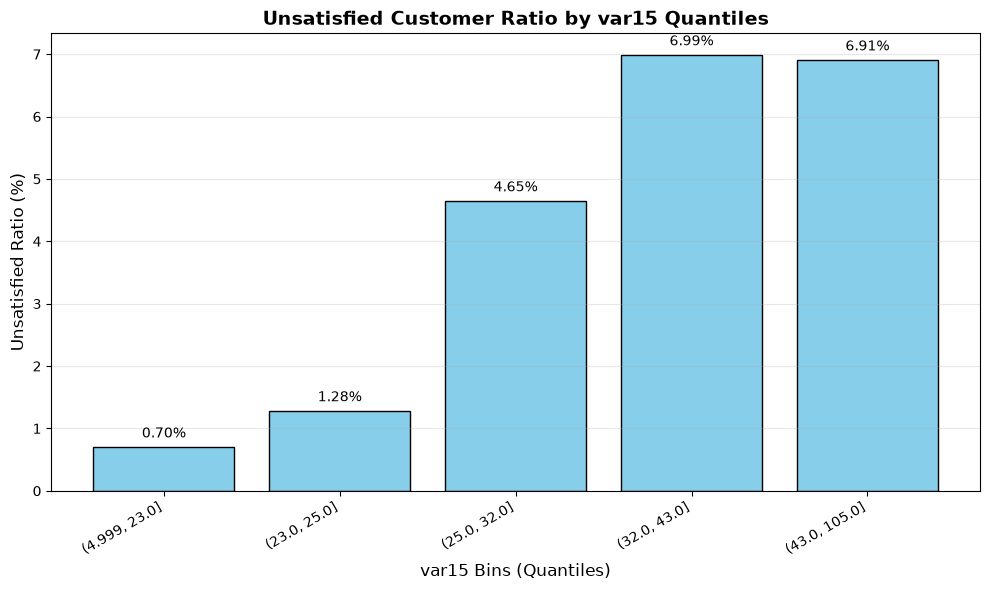

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 구간별 통계 다시 계산 (FutureWarning 해결을 위해 observed=True 추가)
target_feature = 'var15'
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 2. 시각화 (구간별 불만족 고객 비율)
plt.figure(figsize=(10, 6))
# 구간 객체를 문자열로 변환하여 X축 레이블 가독성 높이기
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = plt.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='skyblue', edgecolor='black')

# 그래프 꾸미기
plt.title(f'Unsatisfied Customer Ratio by {target_feature} Quantiles', fontsize=14, fontweight='bold')
plt.xlabel(f'{target_feature} Bins (Quantiles)', fontsize=12)
plt.ylabel('Unsatisfied Ratio (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 3. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

구간별 비율 분석 이미지 저장 완료: figures\eda_bin_ratio_var15.png


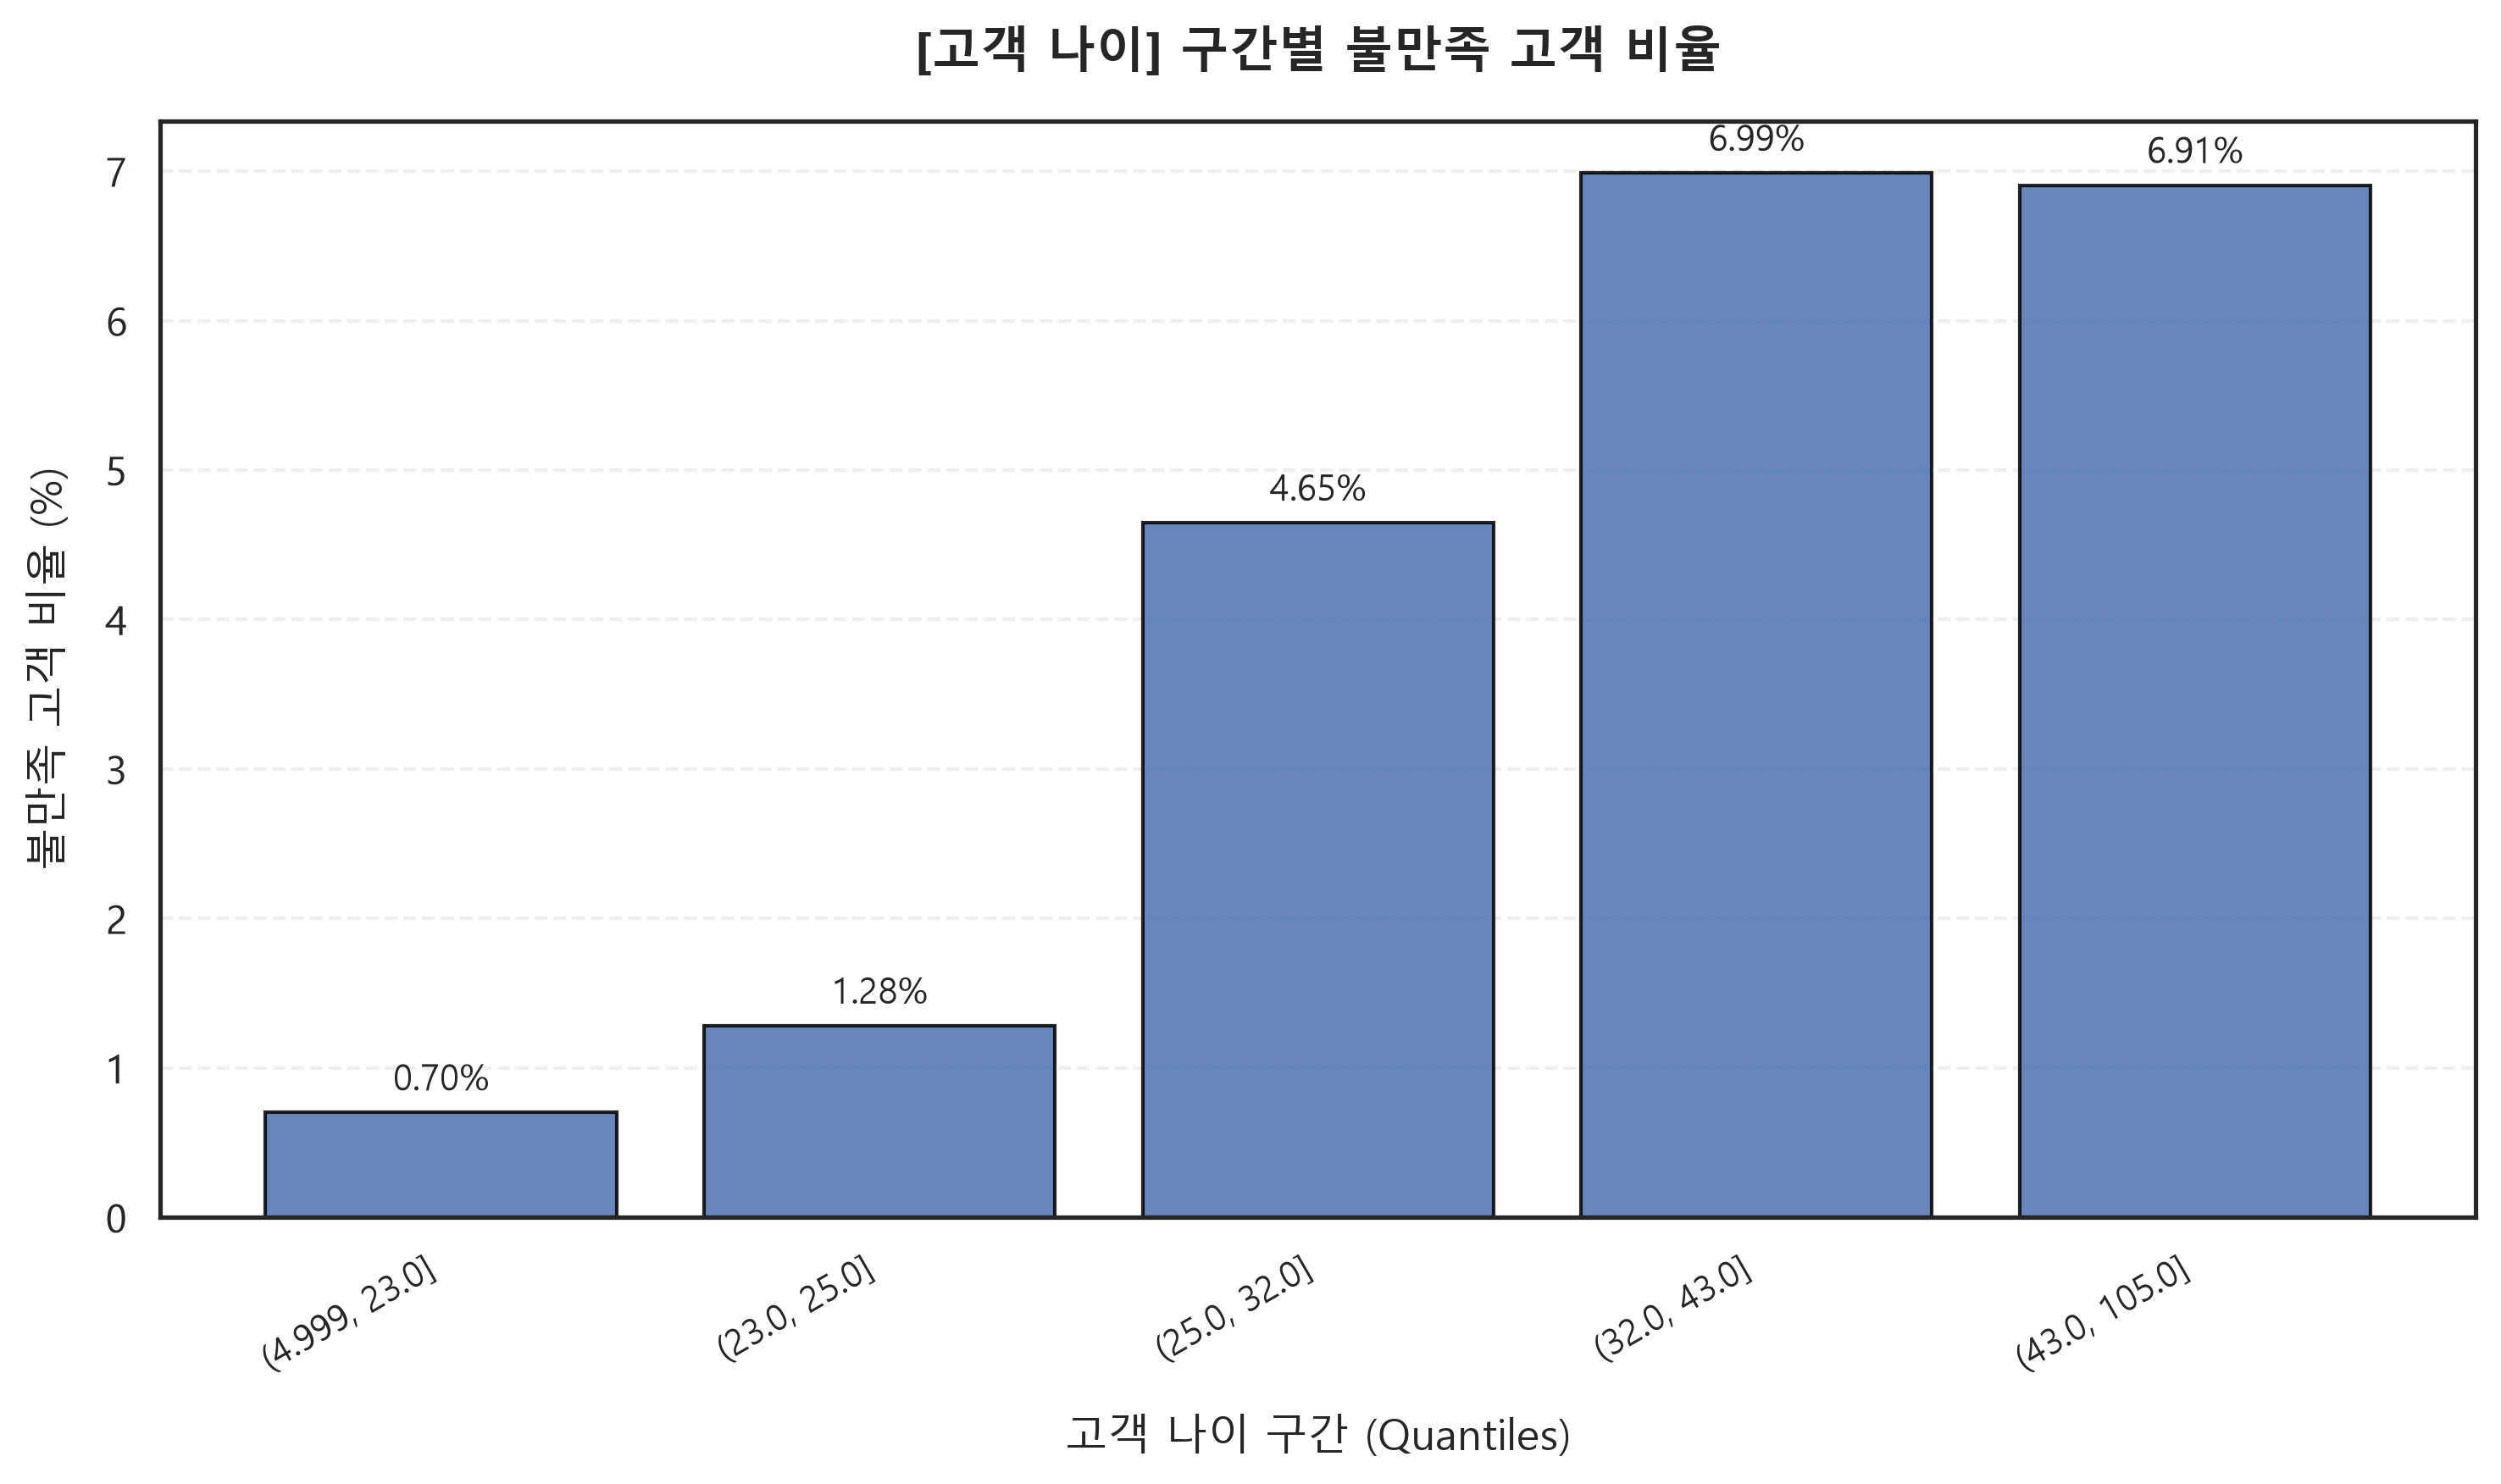

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

# 1. 한글 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 분석할 변수 지정 및 한글 이름 가져오기
target_feature = 'var15'
korean_feature_name = get_korean_name(target_feature) # '고객 나이(var15)' 등 한글명 변환

# 4. 구간별 통계 계산 (observed=True로 FutureWarning 해결)
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 5. 시각화 (구간별 불만족 고객 비율) - 객체 지향형 구조 적용
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = ax.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='#4C72B0', edgecolor='black', alpha=0.85)

# 그래프 타이틀 및 축 레이블 한글 반영
ax.set_title(f'[{korean_feature_name}] 구간별 불만족 고객 비율', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'{korean_feature_name} 구간 (Quantiles)', fontsize=12, labelpad=10)
ax.set_ylabel('불만족 고객 비율 (%)', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(10)

ax.grid(axis='y', alpha=0.3, linestyle='--')

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

# 6. figures 폴더에 고해상도 이미지 저장 (plt.show() 전 실행)
save_path = os.path.join(output_dir, f'eda_bin_ratio_{target_feature}.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"구간별 비율 분석 이미지 저장 완료: {save_path}")

# 7. 화면 출력
plt.tight_layout()
plt.show()

# 8. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

In [157]:
# 분석해보고 싶은 특정 변수 지정 (예시로 'var38' 사용, 다른 변수로 변경 가능)
target_feature = 'num_meses_var5_ult3' 

if target_feature in df_clean.columns:
    # 데이터를 분위수(Quantile) 기준으로 5개 구간으로 나누어 불만족 비율 확인
    df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')
    
    # 구간별 불만족 고객(TARGET=1)의 비율 계산
    bin_stat = df_clean.groupby('bin')['TARGET'].agg(
        Total_Count='count',
        Unsatisfied_Count=lambda x: (x == 1).sum(),
        Unsatisfied_Ratio=lambda x: (x == 1).mean()
    )
    
    print(f"===== '{target_feature}' 구간별 불만족 고객 비율 통계 =====")
    display(bin_stat)
    
    # 임시로 만든 'bin' 컬럼 삭제
    df_clean.drop(columns=['bin'], inplace=True)
else:
    print(f"'{target_feature}' 변수가 데이터프레임에 존재하지 않습니다.")

===== 'num_meses_var5_ult3' 구간별 불만족 고객 비율 통계 =====


C:\Users\mega\AppData\Local\Temp\ipykernel_16716\4081330762.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stat = df_clean.groupby('bin')['TARGET'].agg(


,Total_Count,Unsatisfied_Count,Unsatisfied_Ratio
bin,,,
"(-0.001, 2.0]",33182,2221,0.066934
"(2.0, 3.0]",42838,787,0.018372


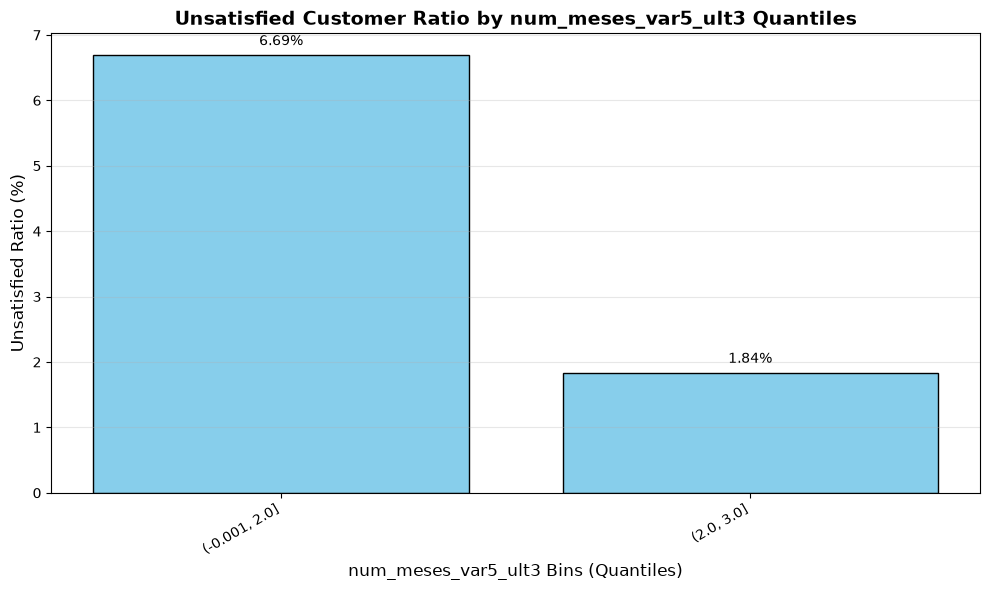

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 구간별 통계 다시 계산 (FutureWarning 해결을 위해 observed=True 추가)
target_feature = 'num_meses_var5_ult3'
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 2. 시각화 (구간별 불만족 고객 비율)
plt.figure(figsize=(10, 6))
# 구간 객체를 문자열로 변환하여 X축 레이블 가독성 높이기
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = plt.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='skyblue', edgecolor='black')

# 그래프 꾸미기
plt.title(f'Unsatisfied Customer Ratio by {target_feature} Quantiles', fontsize=14, fontweight='bold')
plt.xlabel(f'{target_feature} Bins (Quantiles)', fontsize=12)
plt.ylabel('Unsatisfied Ratio (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 3. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

구간별 비율 분석 이미지 저장 완료: figures\eda_bin_ratio_num_meses_var5_ult3.png


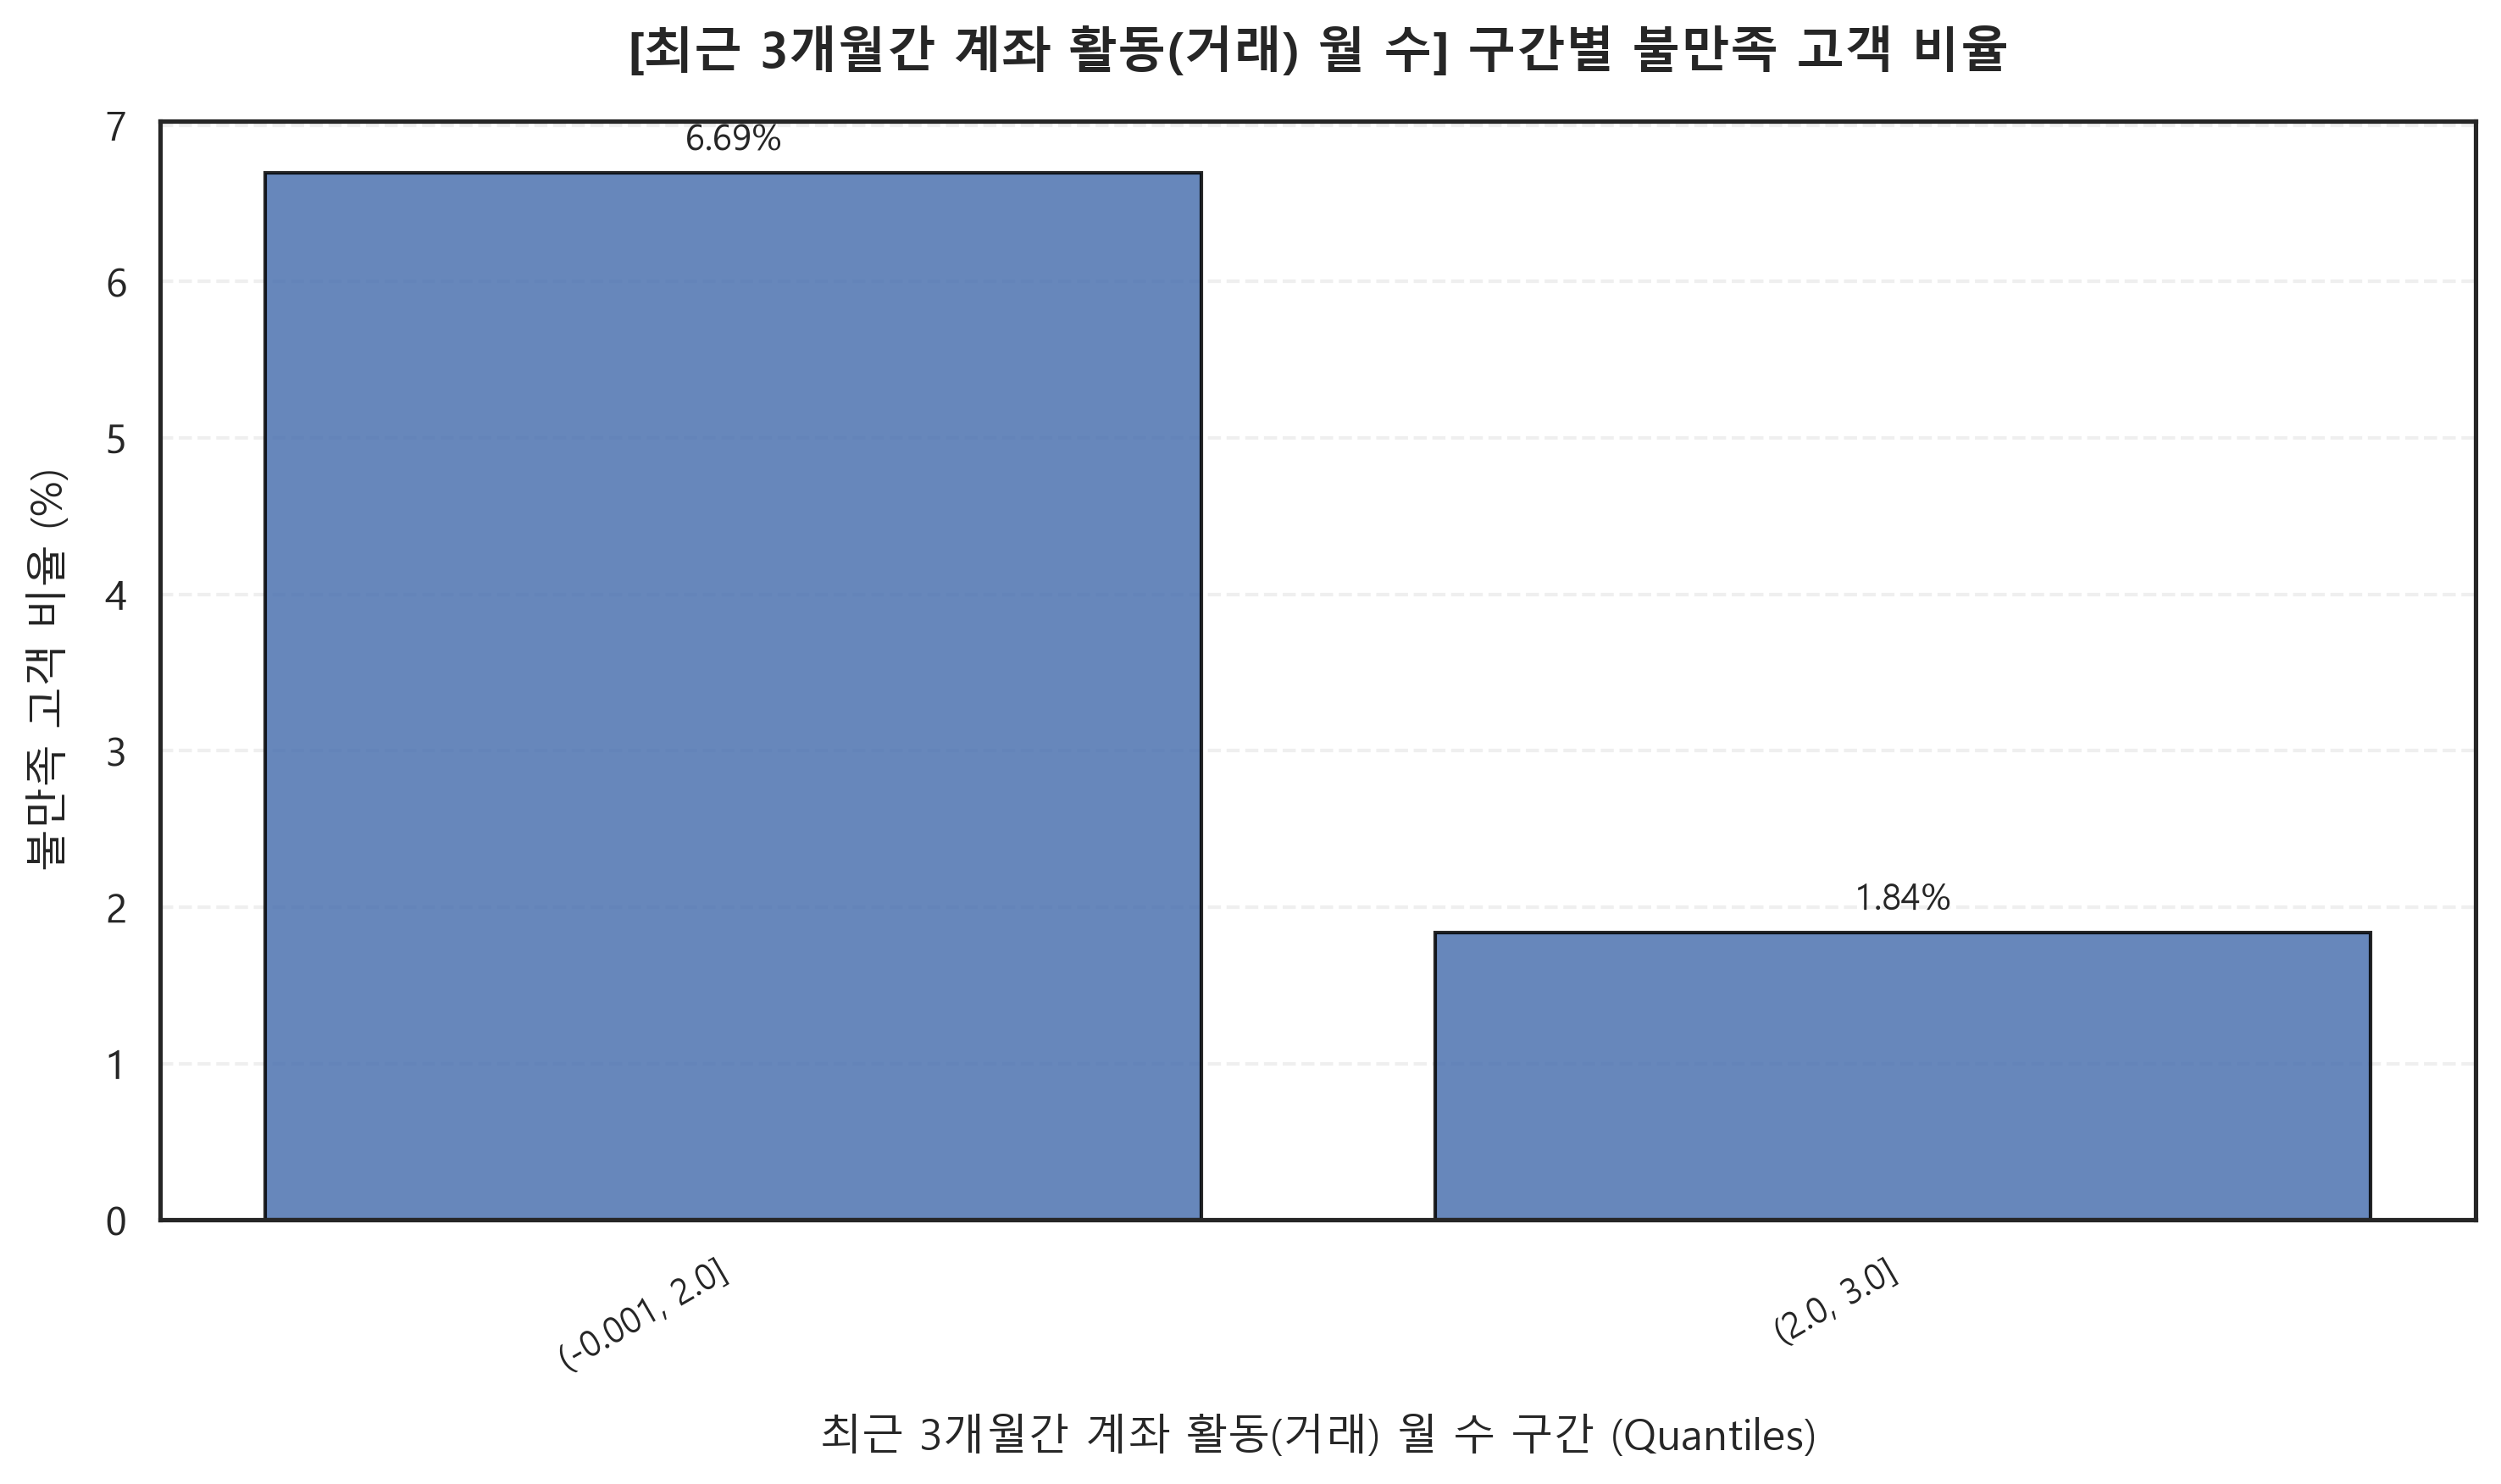

In [218]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

# 1. 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 분석할 변수 지정 및 한글 이름 가져오기
target_feature = 'num_meses_var5_ult3'
# get_korean_name 함수가 정의되어 있다고 가정합니다.
korean_feature_name = get_korean_name(target_feature) 

# 4. 구간별 통계 계산
df_clean['bin'] = pd.qcut(df_clean[target_feature], q=5, duplicates='drop')

bin_stat = df_clean.groupby('bin', observed=True)['TARGET'].agg(
    Total_Count='count',
    Unsatisfied_Count=lambda x: (x == 1).sum(),
    Unsatisfied_Ratio=lambda x: (x == 1).mean()
).reset_index()

# 5. 시각화 - 객체 지향형 구조 적용
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x_labels = [str(interval) for interval in bin_stat['bin']]

bars = ax.bar(x_labels, bin_stat['Unsatisfied_Ratio'] * 100, color='#4C72B0', edgecolor='black', alpha=0.85)

# 그래프 타이틀 및 축 레이블 한글 반영
ax.set_title(f'[{korean_feature_name}] 구간별 불만족 고객 비율', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'{korean_feature_name} 구간 (Quantiles)', fontsize=12, labelpad=10)
ax.set_ylabel('불만족 고객 비율 (%)', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(10)

ax.grid(axis='y', alpha=0.3, linestyle='--')

# 막대 위에 비율 숫자 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

# 6. figures 폴더에 고해상도 이미지 저장
save_path = os.path.join(output_dir, f'eda_bin_ratio_{target_feature}.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"구간별 비율 분석 이미지 저장 완료: {save_path}")

# 7. 화면 출력
plt.tight_layout()
plt.show()

# 8. 임시로 만든 'bin' 컬럼 삭제
df_clean.drop(columns=['bin'], inplace=True)

In [159]:
import pandas as pd

# LightGBM 또는 XGBoost 모델 기준으로 중요도가 높은 상위 10개 변수 추출
# (lgb_model 또는 xgb_model 중 학습된 모델 사용)
feature_importances = lgb_model.feature_importances_

# X_train의 컬럼 이름과 중요도 매칭
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("===== 모델이 선택한 가장 중요한 변수 Top 10 =====")
display(feature_imp_df.head(10))

===== 모델이 선택한 가장 중요한 변수 Top 10 =====


,Feature,Importance
334,var38,354
1,var15,276
296,saldo_medio_var5_hace3,205
298,saldo_medio_var5_ult3,141
295,saldo_medio_var5_hace2,124
164,saldo_var30,106
292,num_var45_hace3,96
294,num_var45_ult3,82
297,saldo_medio_var5_ult1,78
249,num_var22_ult3,76


C:\Users\mega\AppData\Local\Temp\ipykernel_16716\821214310.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=feature, data=df_clean, ax=axes[i], palette='Set2')
C:\Users\mega\AppData\Local\Temp\ipykernel_16716\821214310.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=feature, data=df_clean, ax=axes[i], palette='Set2')
C:\Users\mega\AppData\Local\Temp\ipykernel_16716\821214310.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=feature, data=df_clean, ax=axes[i], palette='Set2')
C:\Users\mega

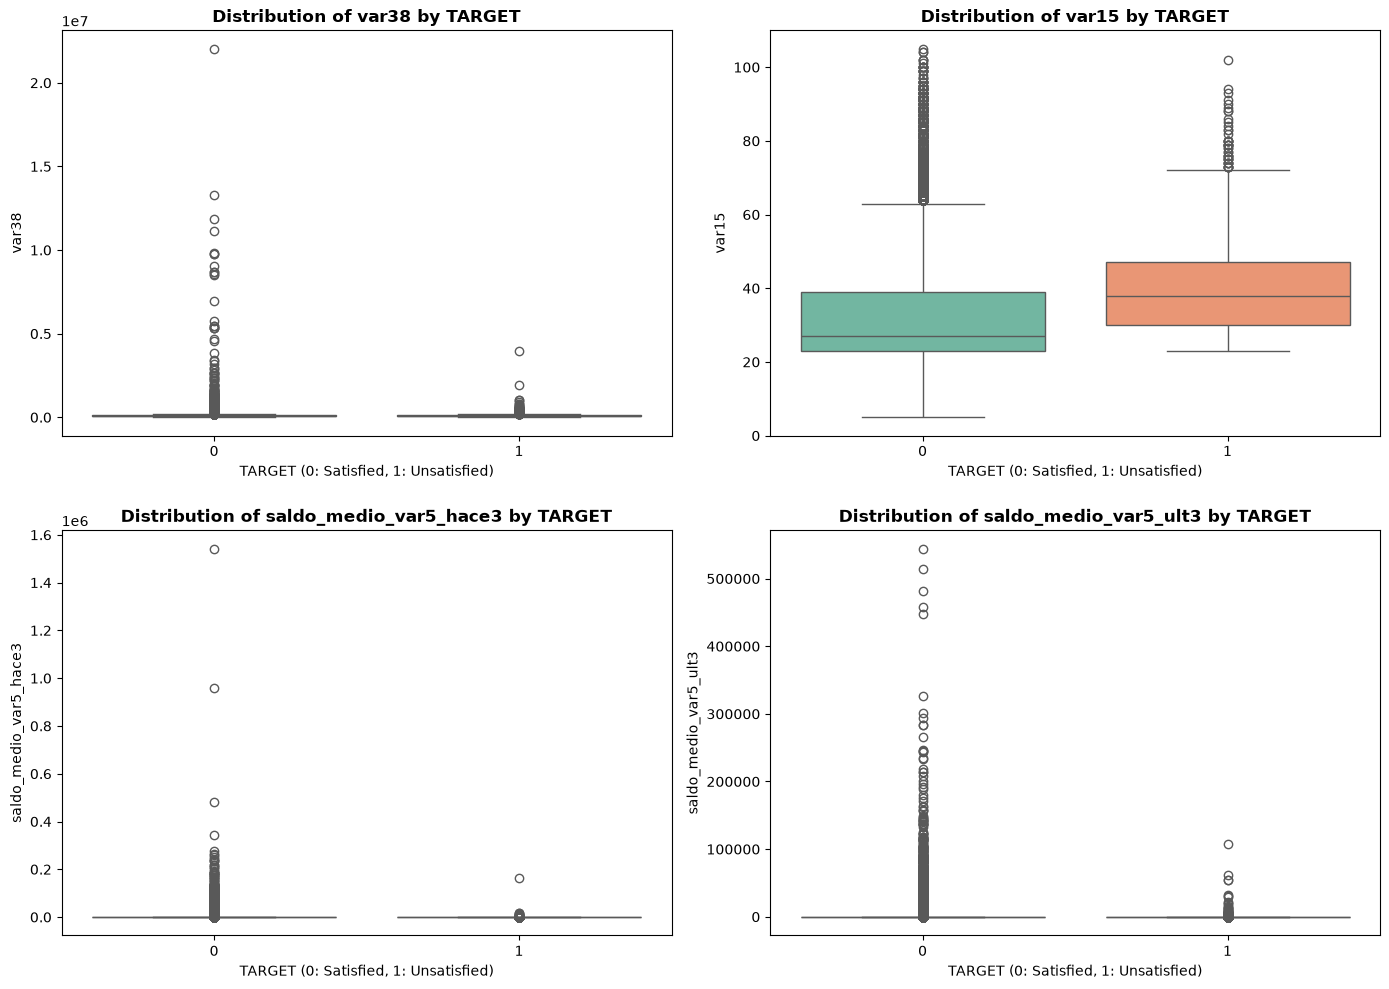

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상위 4개 중요 변수 이름 가져오기
top_4_features = feature_imp_df['Feature'].head(4).tolist()

# 2x2 서브플롯 설정
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_4_features):
    # 데이터가 너무 크면 시각화가 오래 걸리므로 일부 샘플링하거나 전체로 그리기
    sns.boxplot(x='TARGET', y=feature, data=df_clean, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature} by TARGET', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('TARGET (0: Satisfied, 1: Unsatisfied)', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

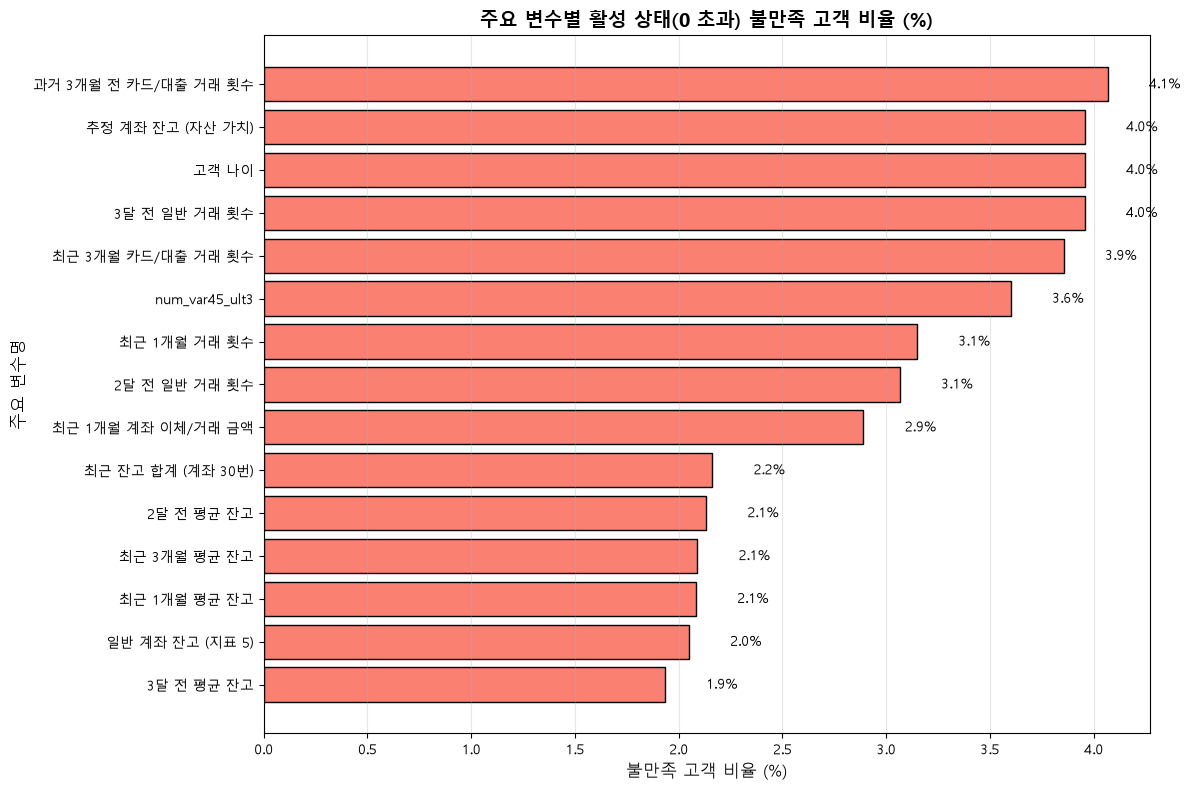

In [181]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 모델의 Feature Importance 상위 15개 가져오기
top_features = feature_imp_df['Feature'].head(15).tolist()

# 3. 각 주요 변수에서 '값이 0보다 큰 경우' 불만족(TARGET=1) 비율 계산
unsat_ratios = []
for feat in top_features:
    non_zero_df = df_clean[df_clean[feat] > 0]
    if len(non_zero_df) > 0:
        ratio = (non_zero_df['TARGET'] == 1).mean() * 100
    else:
        ratio = 0
    unsat_ratios.append(ratio)

# 데이터프레임으로 정리
ratio_df = pd.DataFrame({
    'Feature': top_features,
    'Unsatisfied_Ratio_When_Active': unsat_ratios
}).sort_values(by='Unsatisfied_Ratio_When_Active', ascending=True) # 오름차순 정렬 (가로 바차트용)

# ★ Y축 레이블(영문 변수명)을 한글 이름으로 변환
korean_labels = [get_korean_name(feat) for feat in ratio_df['Feature']]

# 4. 시각화 (가로 막대그래프)
plt.figure(figsize=(12, 8))
plt.barh(korean_labels, ratio_df['Unsatisfied_Ratio_When_Active'], color='salmon', edgecolor='black')

# 타이틀 및 축 이름 한글 반영
plt.title('주요 변수별 활성 상태(0 초과) 불만족 고객 비율 (%)', fontsize=14, fontweight='bold')
plt.xlabel('불만족 고객 비율 (%)', fontsize=12)
plt.ylabel('주요 변수명', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# 막대 오른쪽 끝에 퍼센트 수치 표시
for index, value in enumerate(ratio_df['Unsatisfied_Ratio_When_Active']):
    plt.text(value + 0.2, index, f'{value:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

활성 상태 비율 분석 이미지 저장 완료: figures\model_feature_active_ratio.png


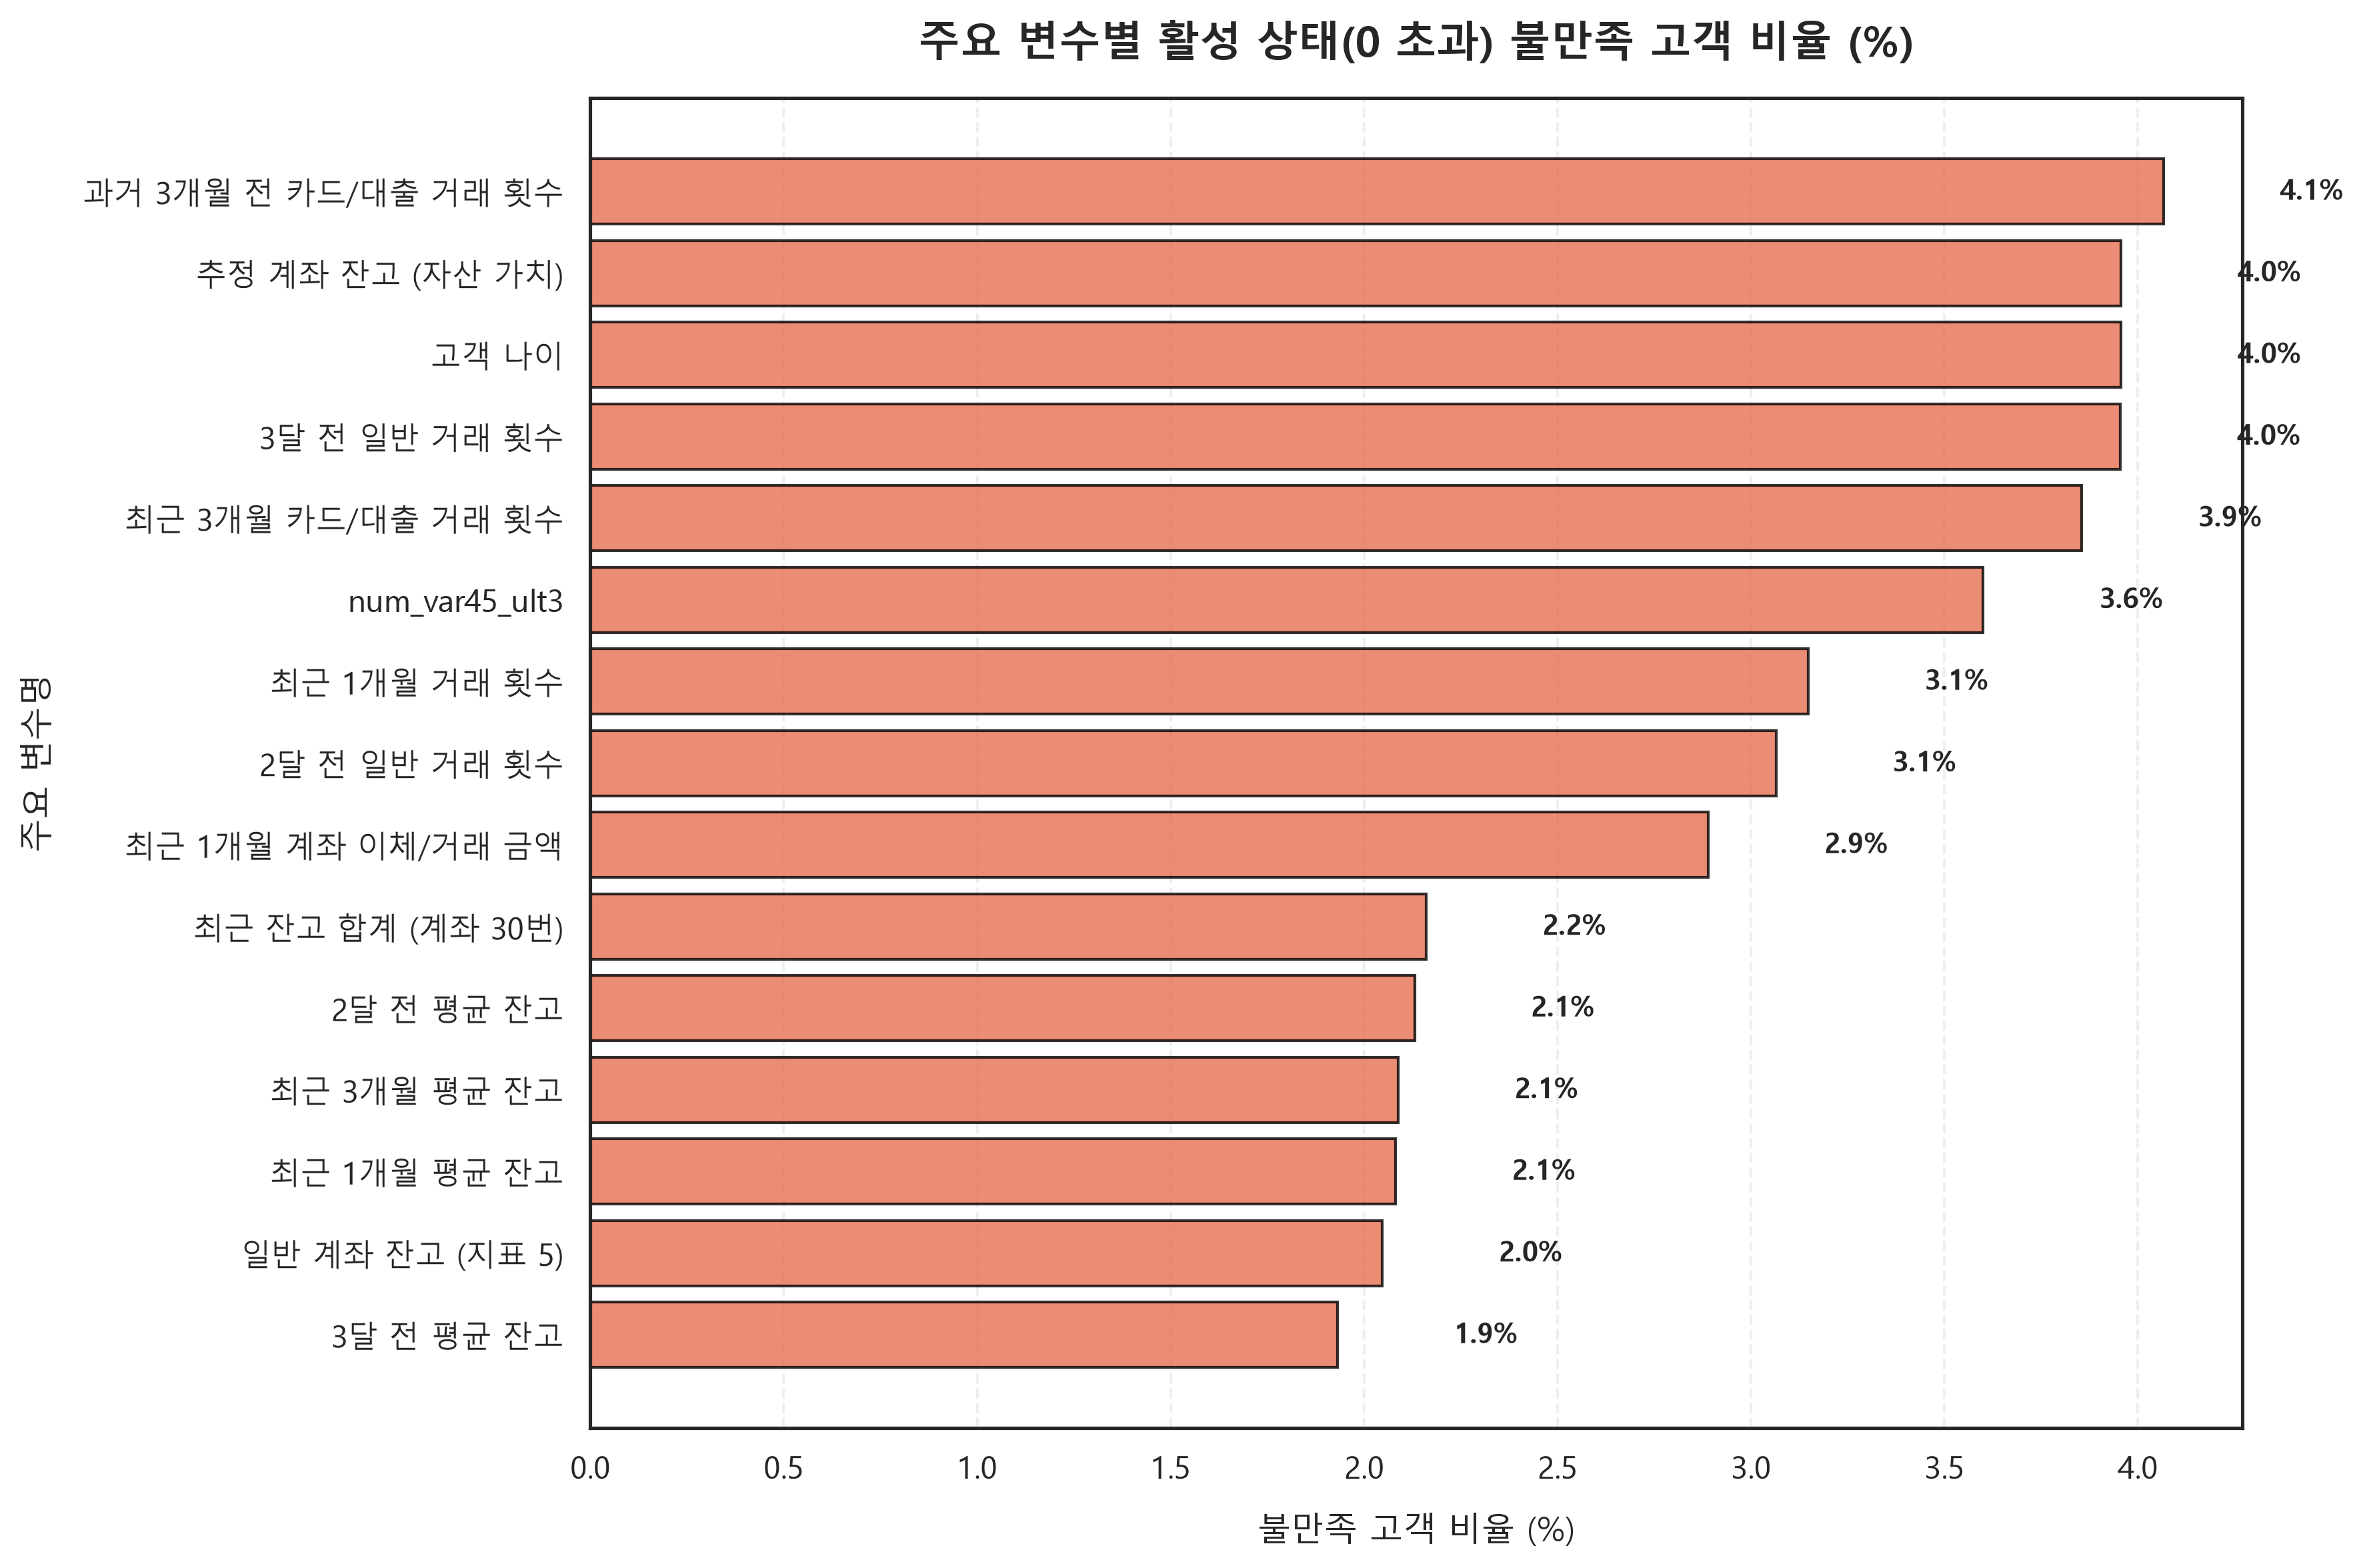

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 1. 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 데이터 준비
top_features = feature_imp_df['Feature'].head(15).tolist()

unsat_ratios = []
for feat in top_features:
    non_zero_df = df_clean[df_clean[feat] > 0]
    if len(non_zero_df) > 0:
        ratio = (non_zero_df['TARGET'] == 1).mean() * 100
    else:
        ratio = 0
    unsat_ratios.append(ratio)

ratio_df = pd.DataFrame({
    'Feature': top_features,
    'Unsatisfied_Ratio_When_Active': unsat_ratios
}).sort_values(by='Unsatisfied_Ratio_When_Active', ascending=True)

# 4. 시각화 - 객체 지향형 구조 적용
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

korean_labels = [get_korean_name(feat) for feat in ratio_df['Feature']]
bars = ax.barh(korean_labels, ratio_df['Unsatisfied_Ratio_When_Active'], color='#E76F51', edgecolor='black', alpha=0.8)

# 타이틀 및 축 레이블 설정
ax.set_title('주요 변수별 활성 상태(0 초과) 불만족 고객 비율 (%)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('불만족 고객 비율 (%)', fontsize=12, labelpad=10)
ax.set_ylabel('주요 변수명', fontsize=12, labelpad=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# 막대 오른쪽 끝에 퍼센트 수치 표시
for index, value in enumerate(ratio_df['Unsatisfied_Ratio_When_Active']):
    ax.text(value + 0.3, index, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')

# 5. figures 폴더에 고해상도 이미지 저장
save_path = os.path.join(output_dir, 'model_feature_active_ratio.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"활성 상태 비율 분석 이미지 저장 완료: {save_path}")

# 6. 화면 출력
plt.tight_layout()
plt.show()

In [164]:
# 가장 중요한 상위 5개 변수 추출
top_5_features = feature_imp_df['Feature'].head(5).tolist()

# TARGET 그룹별 평균 비교
summary_table = df_clean.groupby('TARGET')[top_5_features].mean().T
summary_table.columns = ['Satisfied (0)', 'Unsatisfied (1)']
summary_table['Gap (Unsat - Sat)'] = summary_table['Unsatisfied (1)'] - summary_table['Satisfied (0)']

print("===== [핵심 요약] 만족 vs 불만족 고객의 주요 변수 평균 비교 =====")
display(summary_table)

===== [핵심 요약] 만족 vs 불만족 고객의 주요 변수 평균 비교 =====


,Satisfied (0),Unsatisfied (1),Gap (Unsat - Sat)
var38,117959.156918,99678.280590,-18280.876327
var15,32.946406,39.680519,6.734113
saldo_medio_var5_hace3,923.548332,110.213467,-813.334865
saldo_medio_var5_ult3,1080.422776,282.659362,-797.763415
saldo_medio_var5_hace2,1628.647567,377.343830,-1251.303737


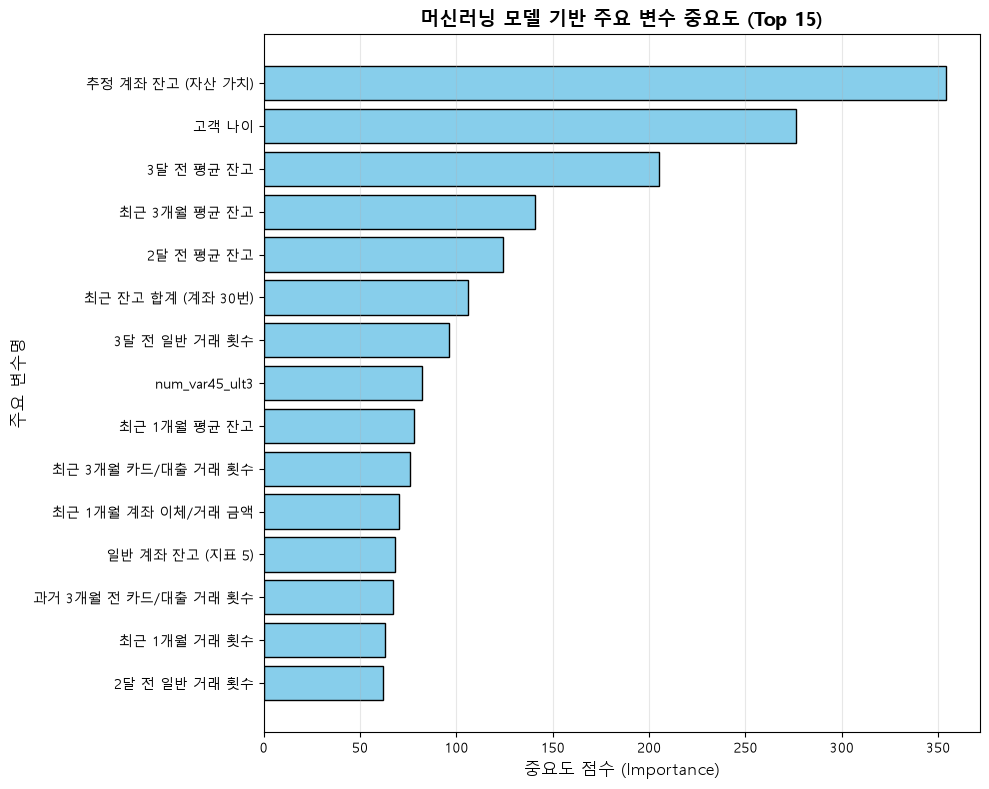

In [191]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# 1. 한글 폰트 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 모델의 Feature Importance 데이터프레임이 있다고 가정 (예: feature_imp_df)
# 컬럼명이 'Feature'와 'Importance'라고 할 때, 상위 15개를 가져옵니다.
top_imp = feature_imp_df.head(15).copy()

# ★ 영문 변수명을 한글 이름으로 변환
top_imp['Korean_Feature'] = top_imp['Feature'].apply(get_korean_name)

# 3. 시각화 (가로 바 차트 - 점수 높은 순으로 위에서 아래로 정렬)
top_imp = top_imp.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_imp['Korean_Feature'], top_imp['Importance'], color='skyblue', edgecolor='black')

plt.title('머신러닝 모델 기반 주요 변수 중요도 (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('중요도 점수 (Importance)', fontsize=12)
plt.ylabel('주요 변수명', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

변수 중요도 이미지 저장 완료: figures\model_feature_importance.png


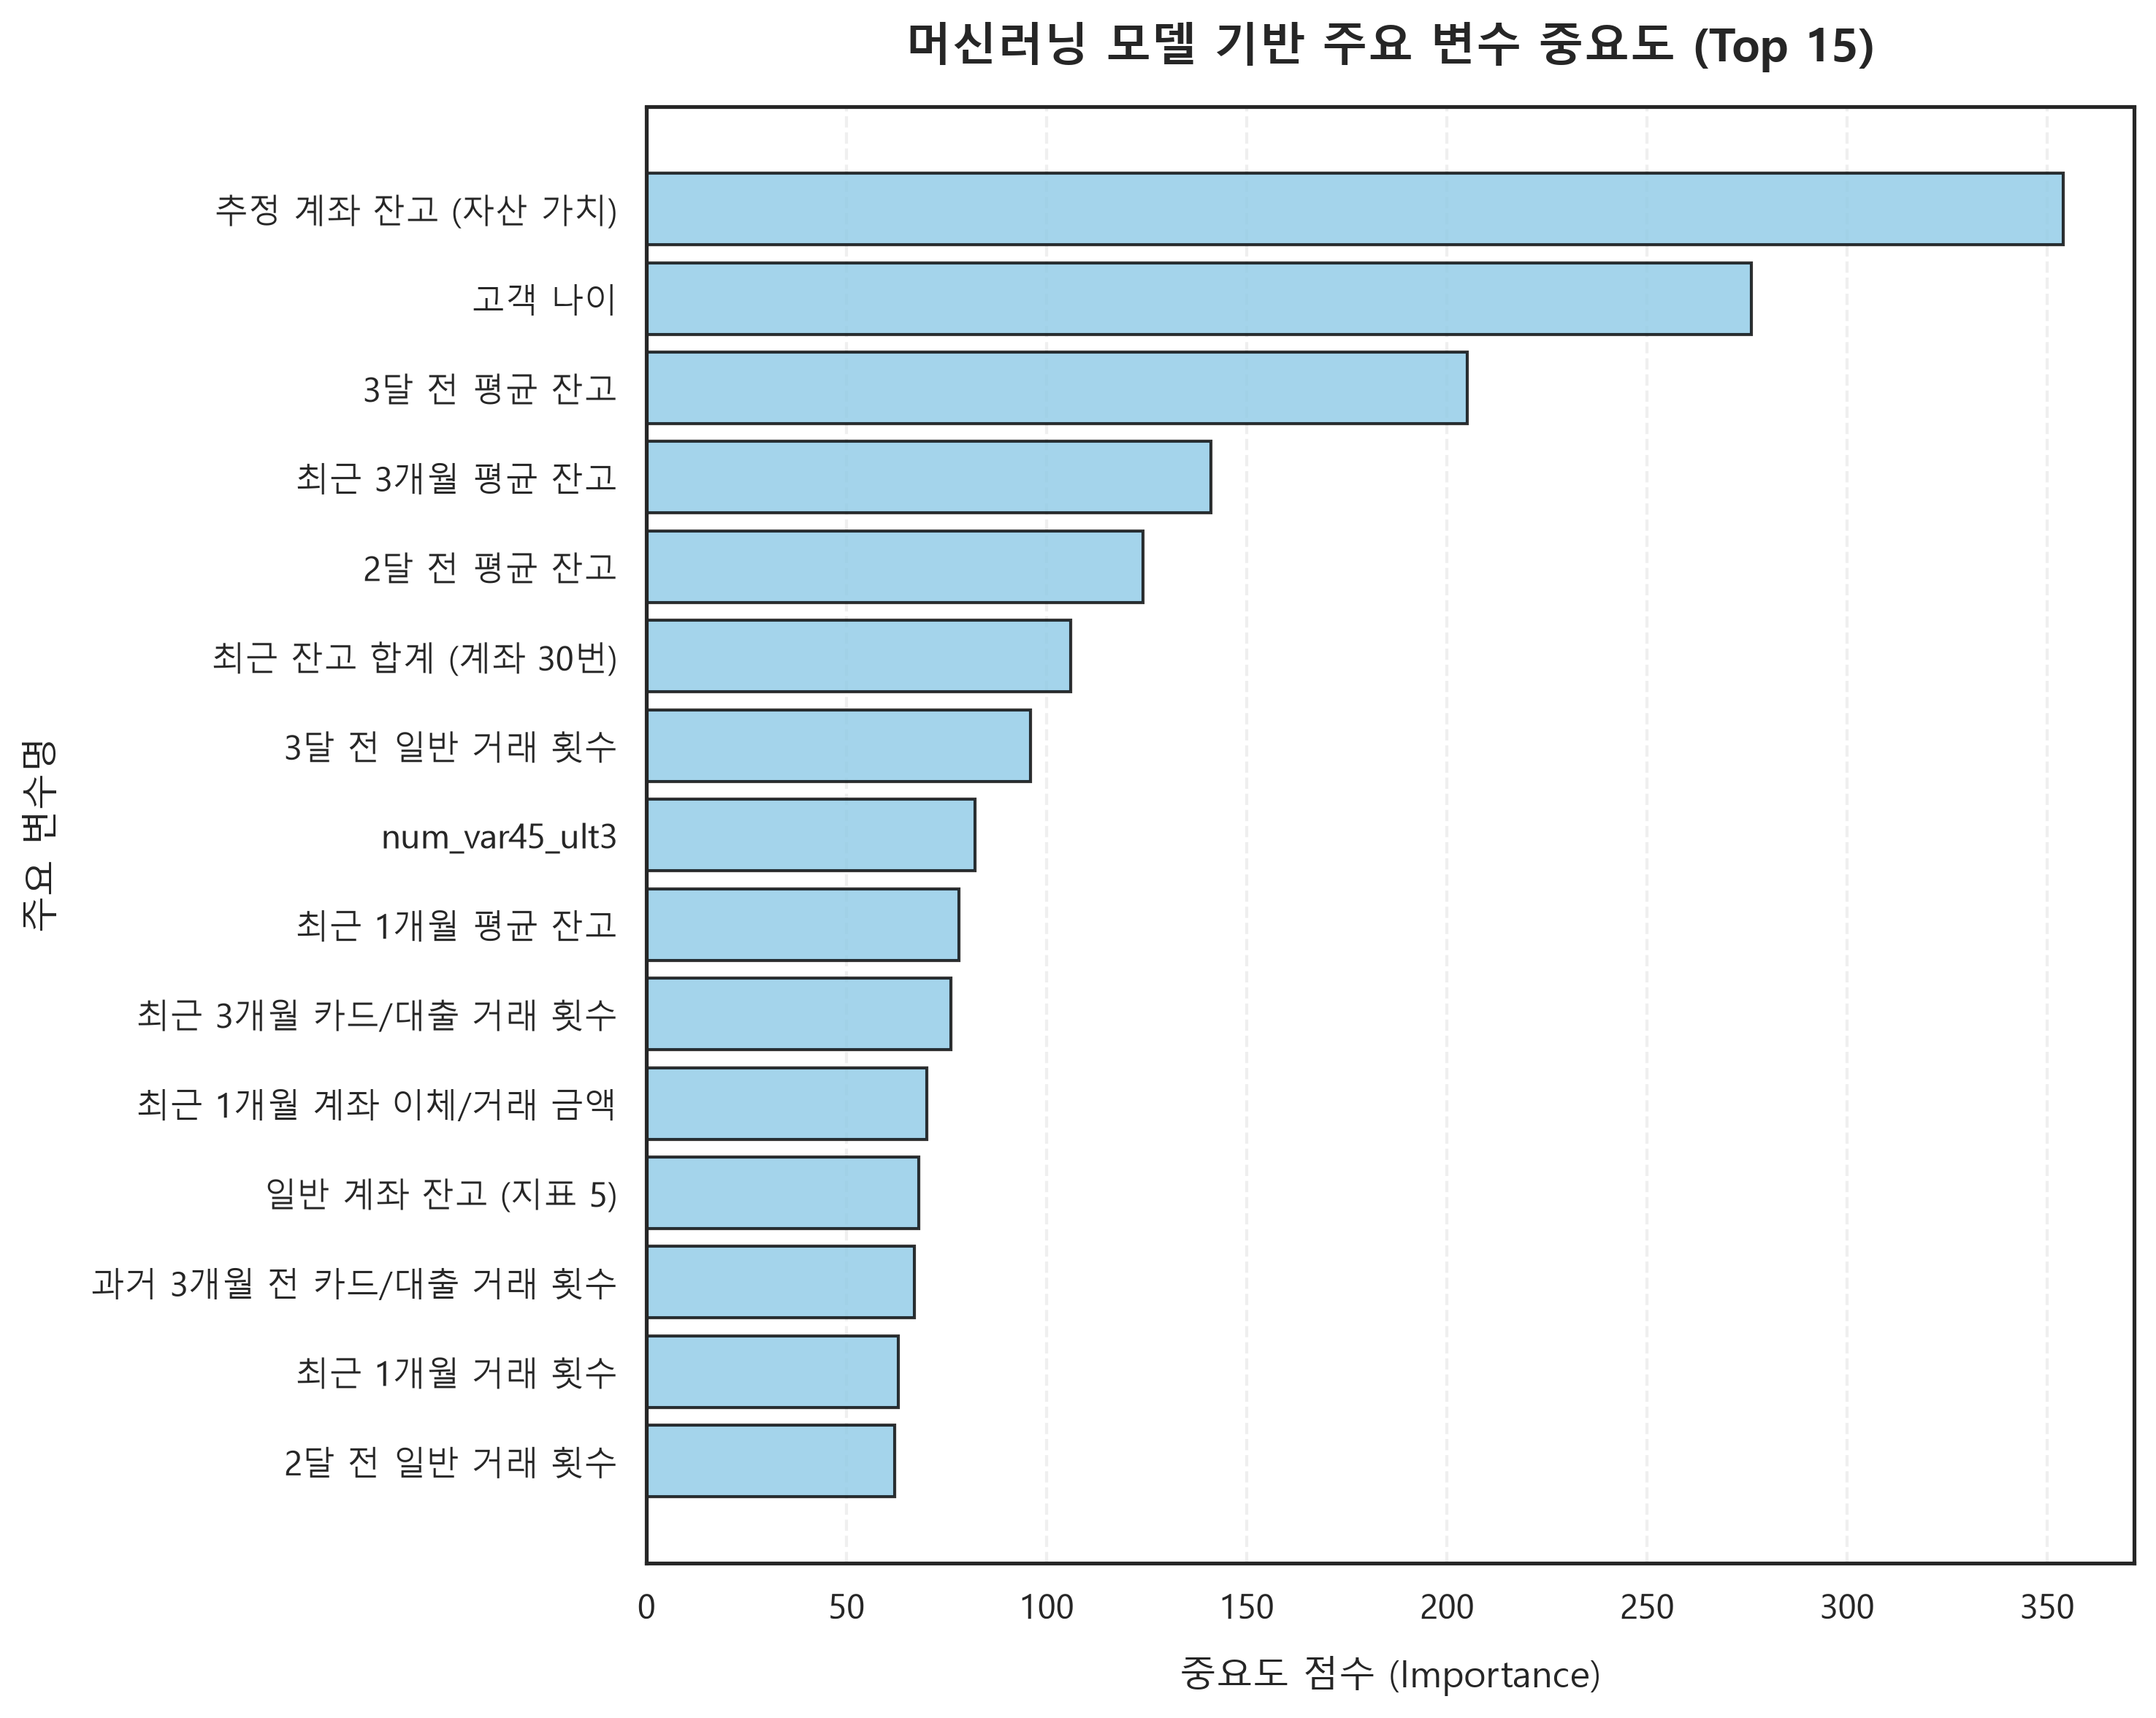

In [220]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 1. 폰트 및 마이너스 기호 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 데이터 준비 (상위 15개)
top_imp = feature_imp_df.head(15).copy()

# 한글 변수명 변환
top_imp['Korean_Feature'] = top_imp['Feature'].apply(get_korean_name)

# 중요도 순으로 정렬 (가로 바 차트는 ascending=True로 해야 위에서부터 큰 값이 옴)
top_imp = top_imp.sort_values(by='Importance', ascending=True)

# 4. 시각화 - 객체 지향형 구조 적용
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

bars = ax.barh(top_imp['Korean_Feature'], top_imp['Importance'], color='#8ECAE6', edgecolor='black', alpha=0.8)

# 타이틀 및 축 레이블 설정
ax.set_title('머신러닝 모델 기반 주요 변수 중요도 (Top 15)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('중요도 점수 (Importance)', fontsize=12, labelpad=10)
ax.set_ylabel('주요 변수명', fontsize=12, labelpad=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# 5. figures 폴더에 고해상도 이미지 저장 (plt.show() 전 실행)
save_path = os.path.join(output_dir, 'model_feature_importance.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"변수 중요도 이미지 저장 완료: {save_path}")

# 6. 화면 출력
plt.tight_layout()
plt.show()

C:\Users\mega\AppData\Local\Temp\ipykernel_16716\4180800949.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='TARGET', palette='Blues_d') # 혹은 기존 그리던 방식 사용


이미지 저장 완료: figures\eda_target_distribution.png


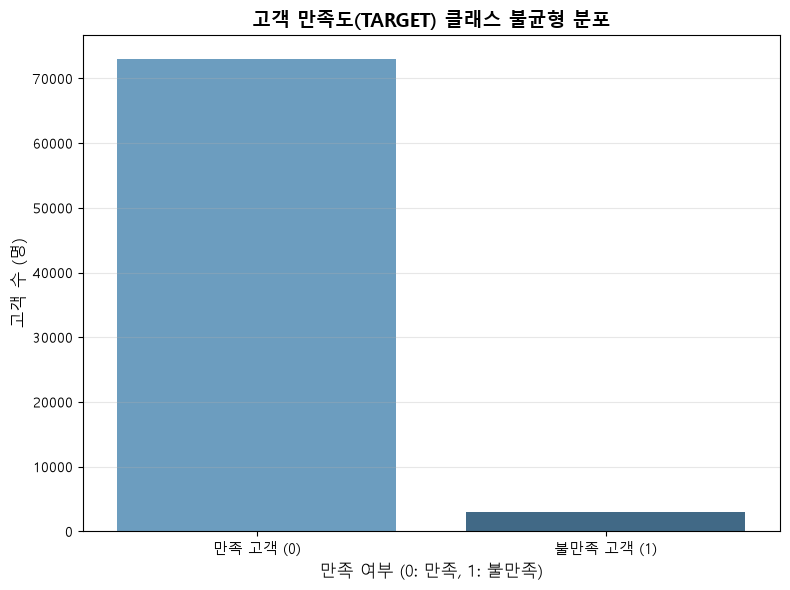

In [198]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 1. 한글 폰트 설정
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 저장할 폴더(figures) 자동 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 그래프 그리기
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_clean, x='TARGET', palette='Blues_d') # 혹은 기존 그리던 방식 사용

# 타이틀 및 축 레이블 한글 반영
plt.title('고객 만족도(TARGET) 클래스 불균형 분포', fontsize=14, fontweight='bold')
plt.xlabel('만족 여부 (0: 만족, 1: 불만족)', fontsize=12)
plt.ylabel('고객 수 (명)', fontsize=12)
plt.xticks([0, 1], ['만족 고객 (0)', '불만족 고객 (1)'], fontsize=11)
plt.grid(axis='y', alpha=0.3)

# 4. figures 폴더에 이미지 저장 (plt.show() 전에 반드시 실행!)
save_path = os.path.join(output_dir, 'eda_target_distribution.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"이미지 저장 완료: {save_path}")

# 5. 화면에 출력
plt.tight_layout()
plt.show()

ROC 곡선 이미지 저장 완료: figures\model_logistic_roc_curve.png


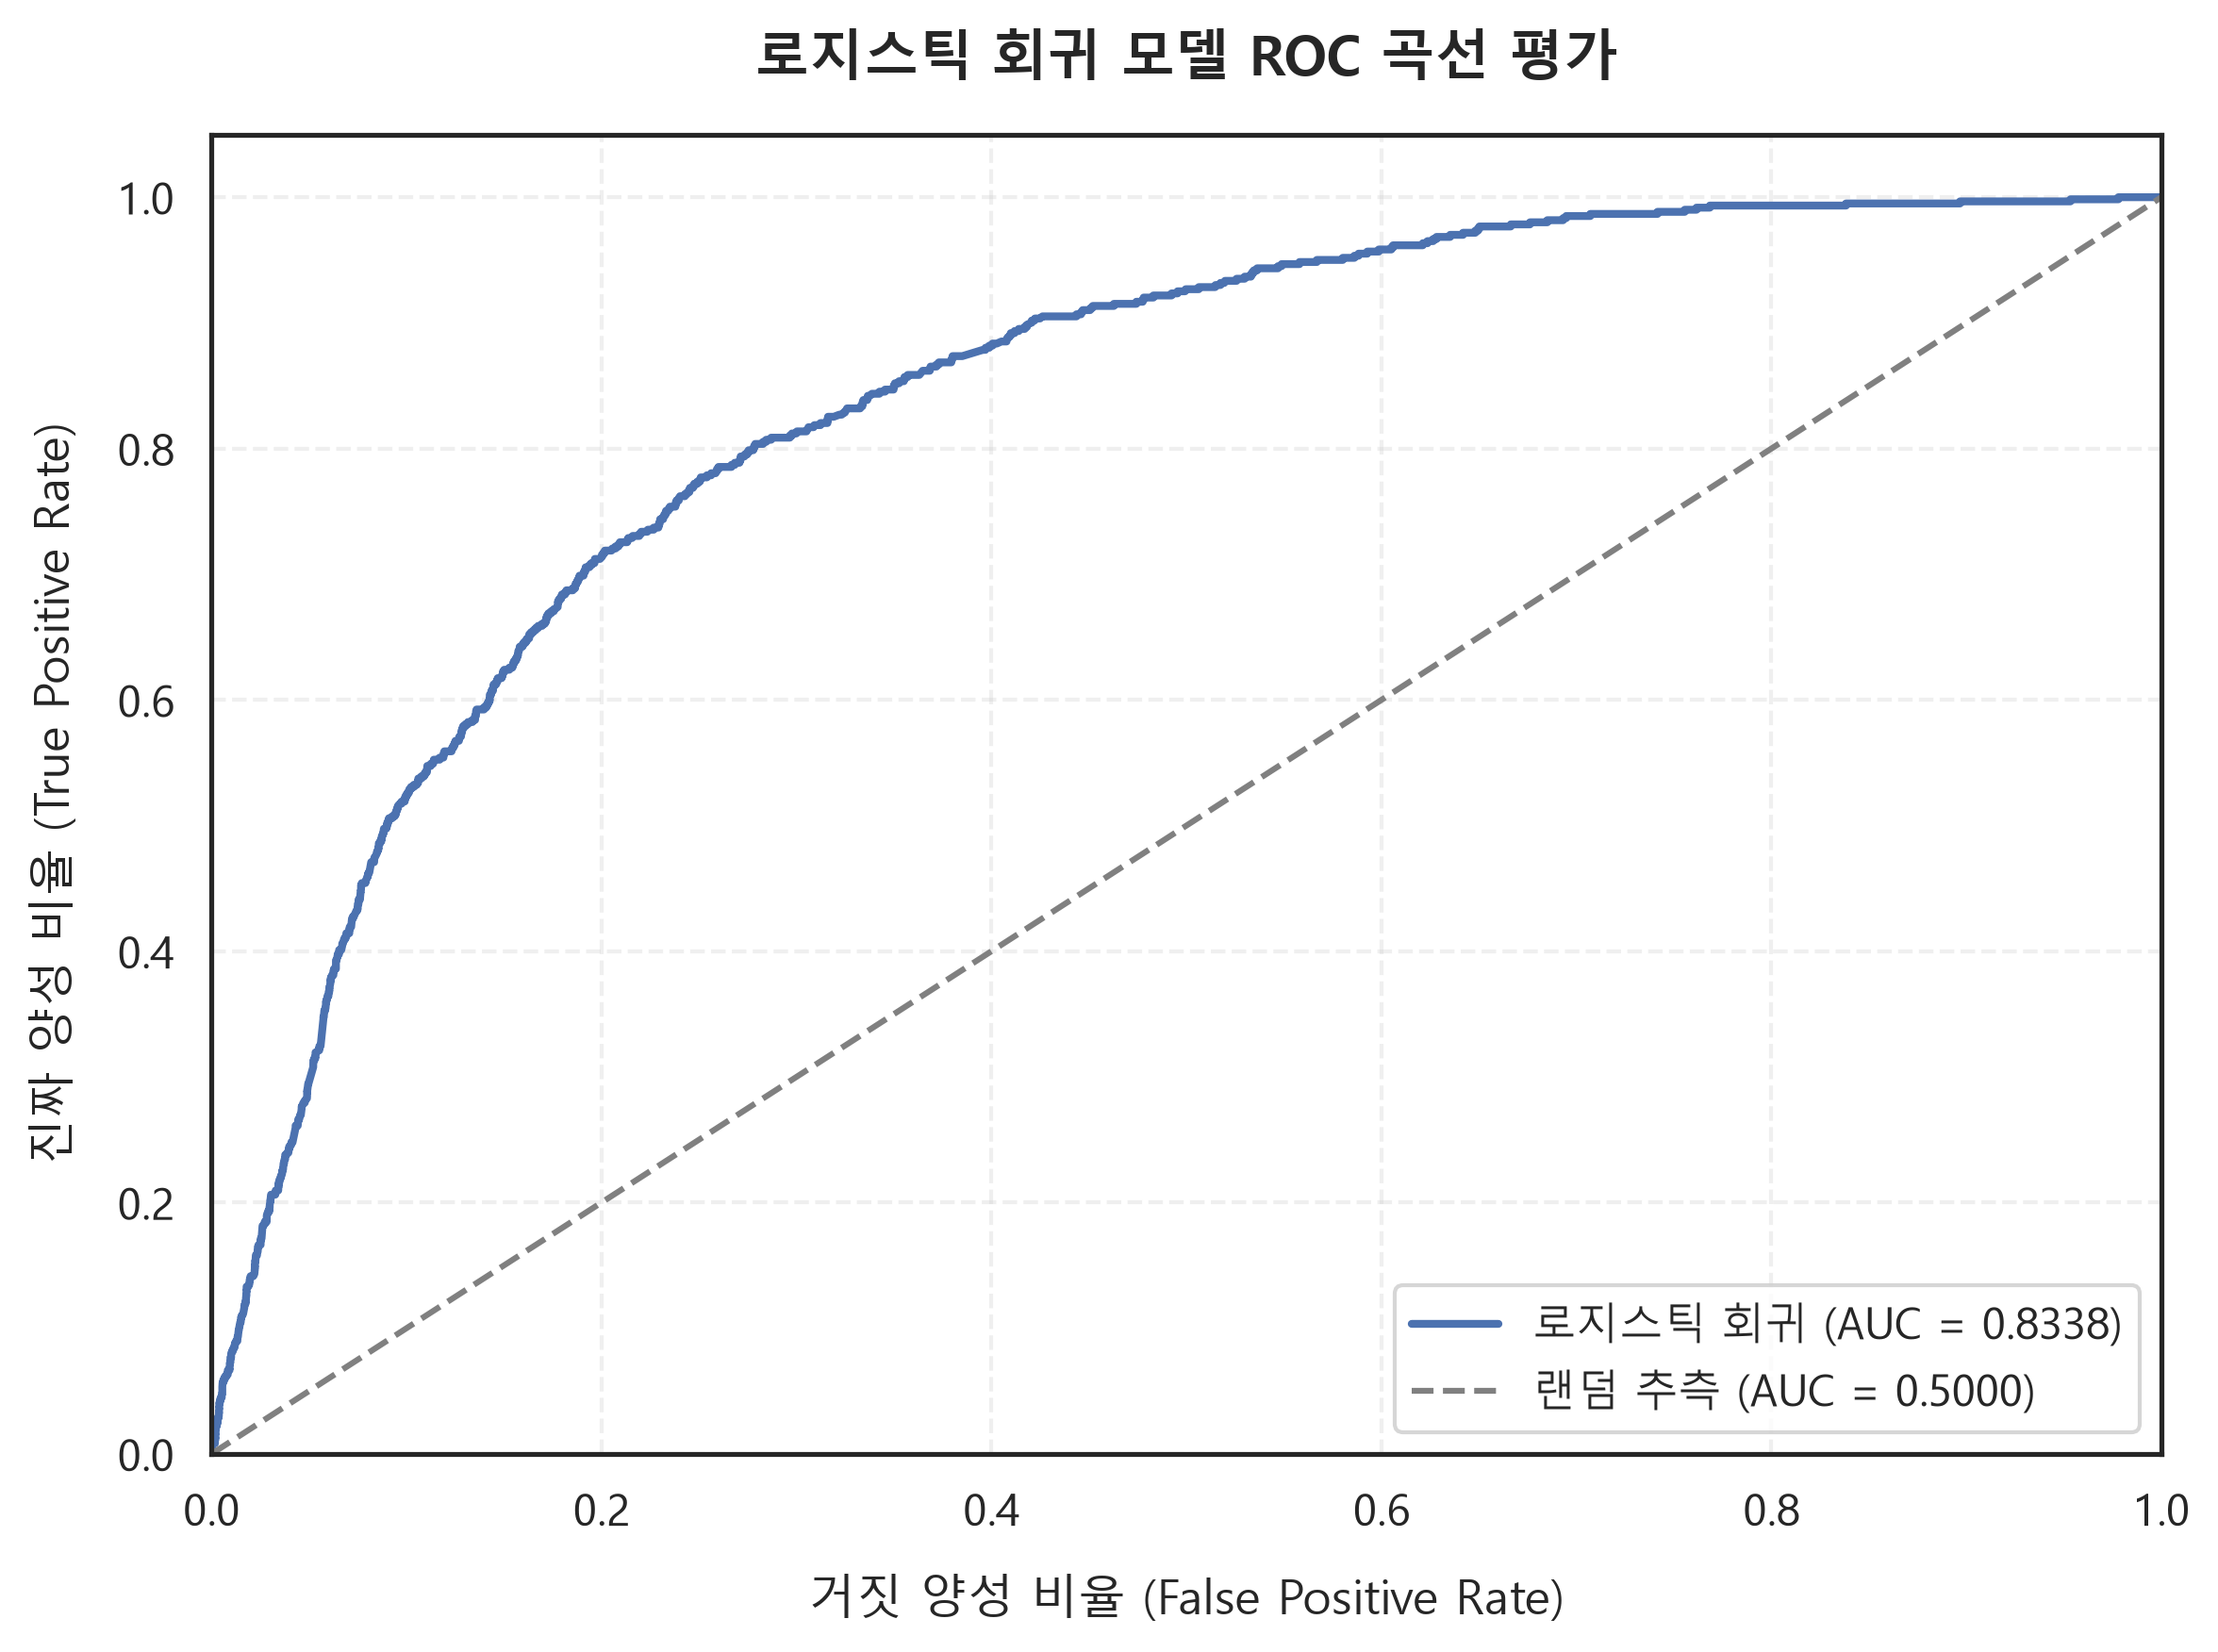

In [207]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import os

# 1. 폰트 및 마이너스 기호 깨짐 방지 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 로지스틱 회귀 모델의 예측 확률(Probability) 계산
# y_test: 실제 정답 (0 또는 1)
# y_pred_proba: 모델이 예측한 불만족(1) 클래스의 확률 값 (예: model.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 4. ROC 곡선 도화지 생성
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# ROC 곡선 그리기 (파란색 선)
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'로지스틱 회귀 (AUC = {roc_auc:.4f})')

# 대각선 기준선 (랜덤 예측 모델, 회색 점선)
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='랜덤 추측 (AUC = 0.5000)')

# 그래프 디자인 다듬기
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('거짓 양성 비율 (False Positive Rate)', fontsize=12, labelpad=10)
ax.set_ylabel('진짜 양성 비율 (True Positive Rate)', fontsize=12, labelpad=10)
ax.set_title('로지스틱 회귀 모델 ROC 곡선 평가', fontsize=14, fontweight='bold', pad=15)

# 범례 표시 (우측 하단)
ax.legend(loc="lower right", fontsize=11, frameon=True)
ax.grid(alpha=0.3, linestyle='--')

# 5. figures 폴더에 고해상도 저장
save_path = os.path.join(output_dir, 'model_logistic_roc_curve.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"ROC 곡선 이미지 저장 완료: {save_path}")

plt.tight_layout()
plt.show()

모델 비교 ROC 곡선 이미지 저장 완료: figures\model_comparison_roc_curve.png


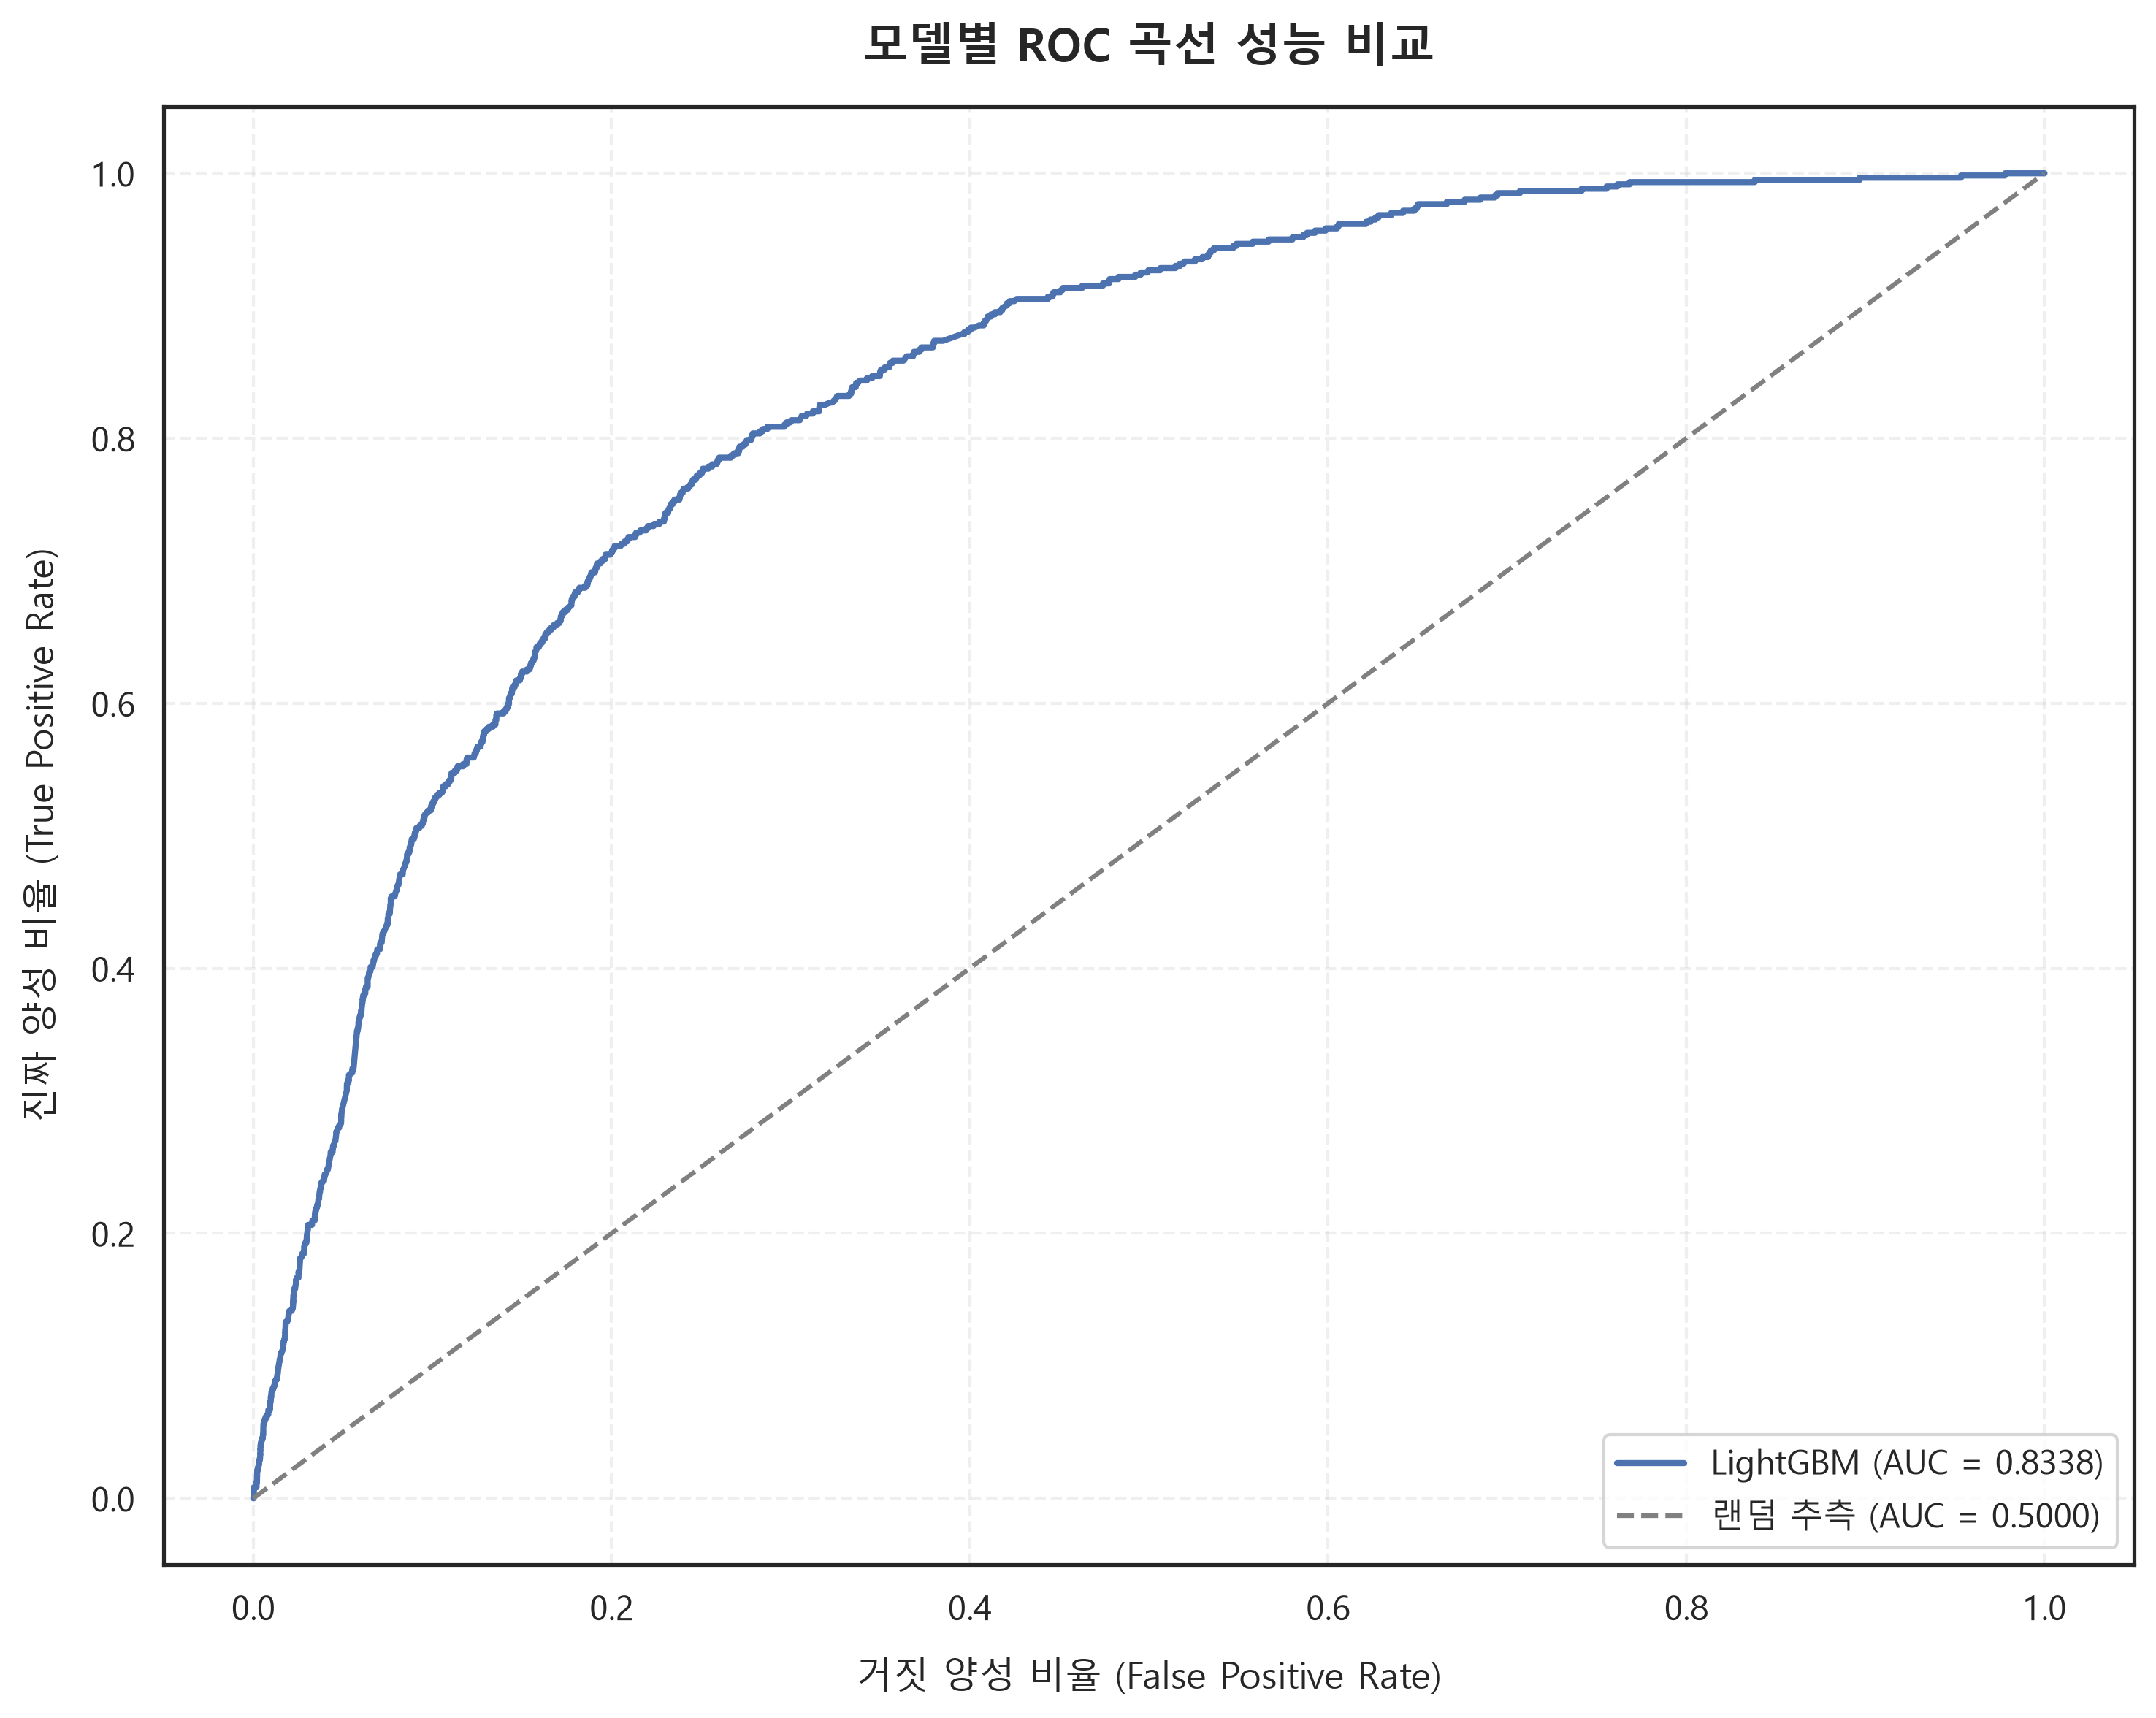

In [213]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import os

# 1. 폰트 및 마이너스 기호 깨짐 방지 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 2. figures 폴더 생성
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# 3. 비교할 모델 딕셔너리 구성 (학습이 완료된 모델들을 넣어줍니다)
models = {
    # '로지스틱 회귀 (Logistic Regression)': logistic_baseline,
    # '랜덤 포레스트 (Random Forest)': rf_model,      # 필요시 주석 해제하여 추가
    # 'XGBoost': xgb_model,                          # 필요시 주석 해제하여 추가
    'LightGBM': lgb_model                          # 필요시 주석 해제하여 추가
}

# 4. ROC 곡선 다중 비교 도화지 생성
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test.values)
        
    auc_score = roc_auc_score(y_test, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    # 그래프 그리기
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

# 랜덤 추측 기준선
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='랜덤 추측 (AUC = 0.5000)', linewidth=1.5)

# 디자인 및 한글 레이블 설정
ax.set_xlabel('거짓 양성 비율 (False Positive Rate)', fontsize=12, labelpad=10)
ax.set_ylabel('진짜 양성 비율 (True Positive Rate)', fontsize=12, labelpad=10)
ax.set_title('모델별 ROC 곡선 성능 비교', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True)
ax.grid(alpha=0.3, linestyle='--')

# 5. figures 폴더에 이미지 저장
save_path = os.path.join(output_dir, 'model_comparison_roc_curve.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"모델 비교 ROC 곡선 이미지 저장 완료: {save_path}")

plt.tight_layout()
plt.show()

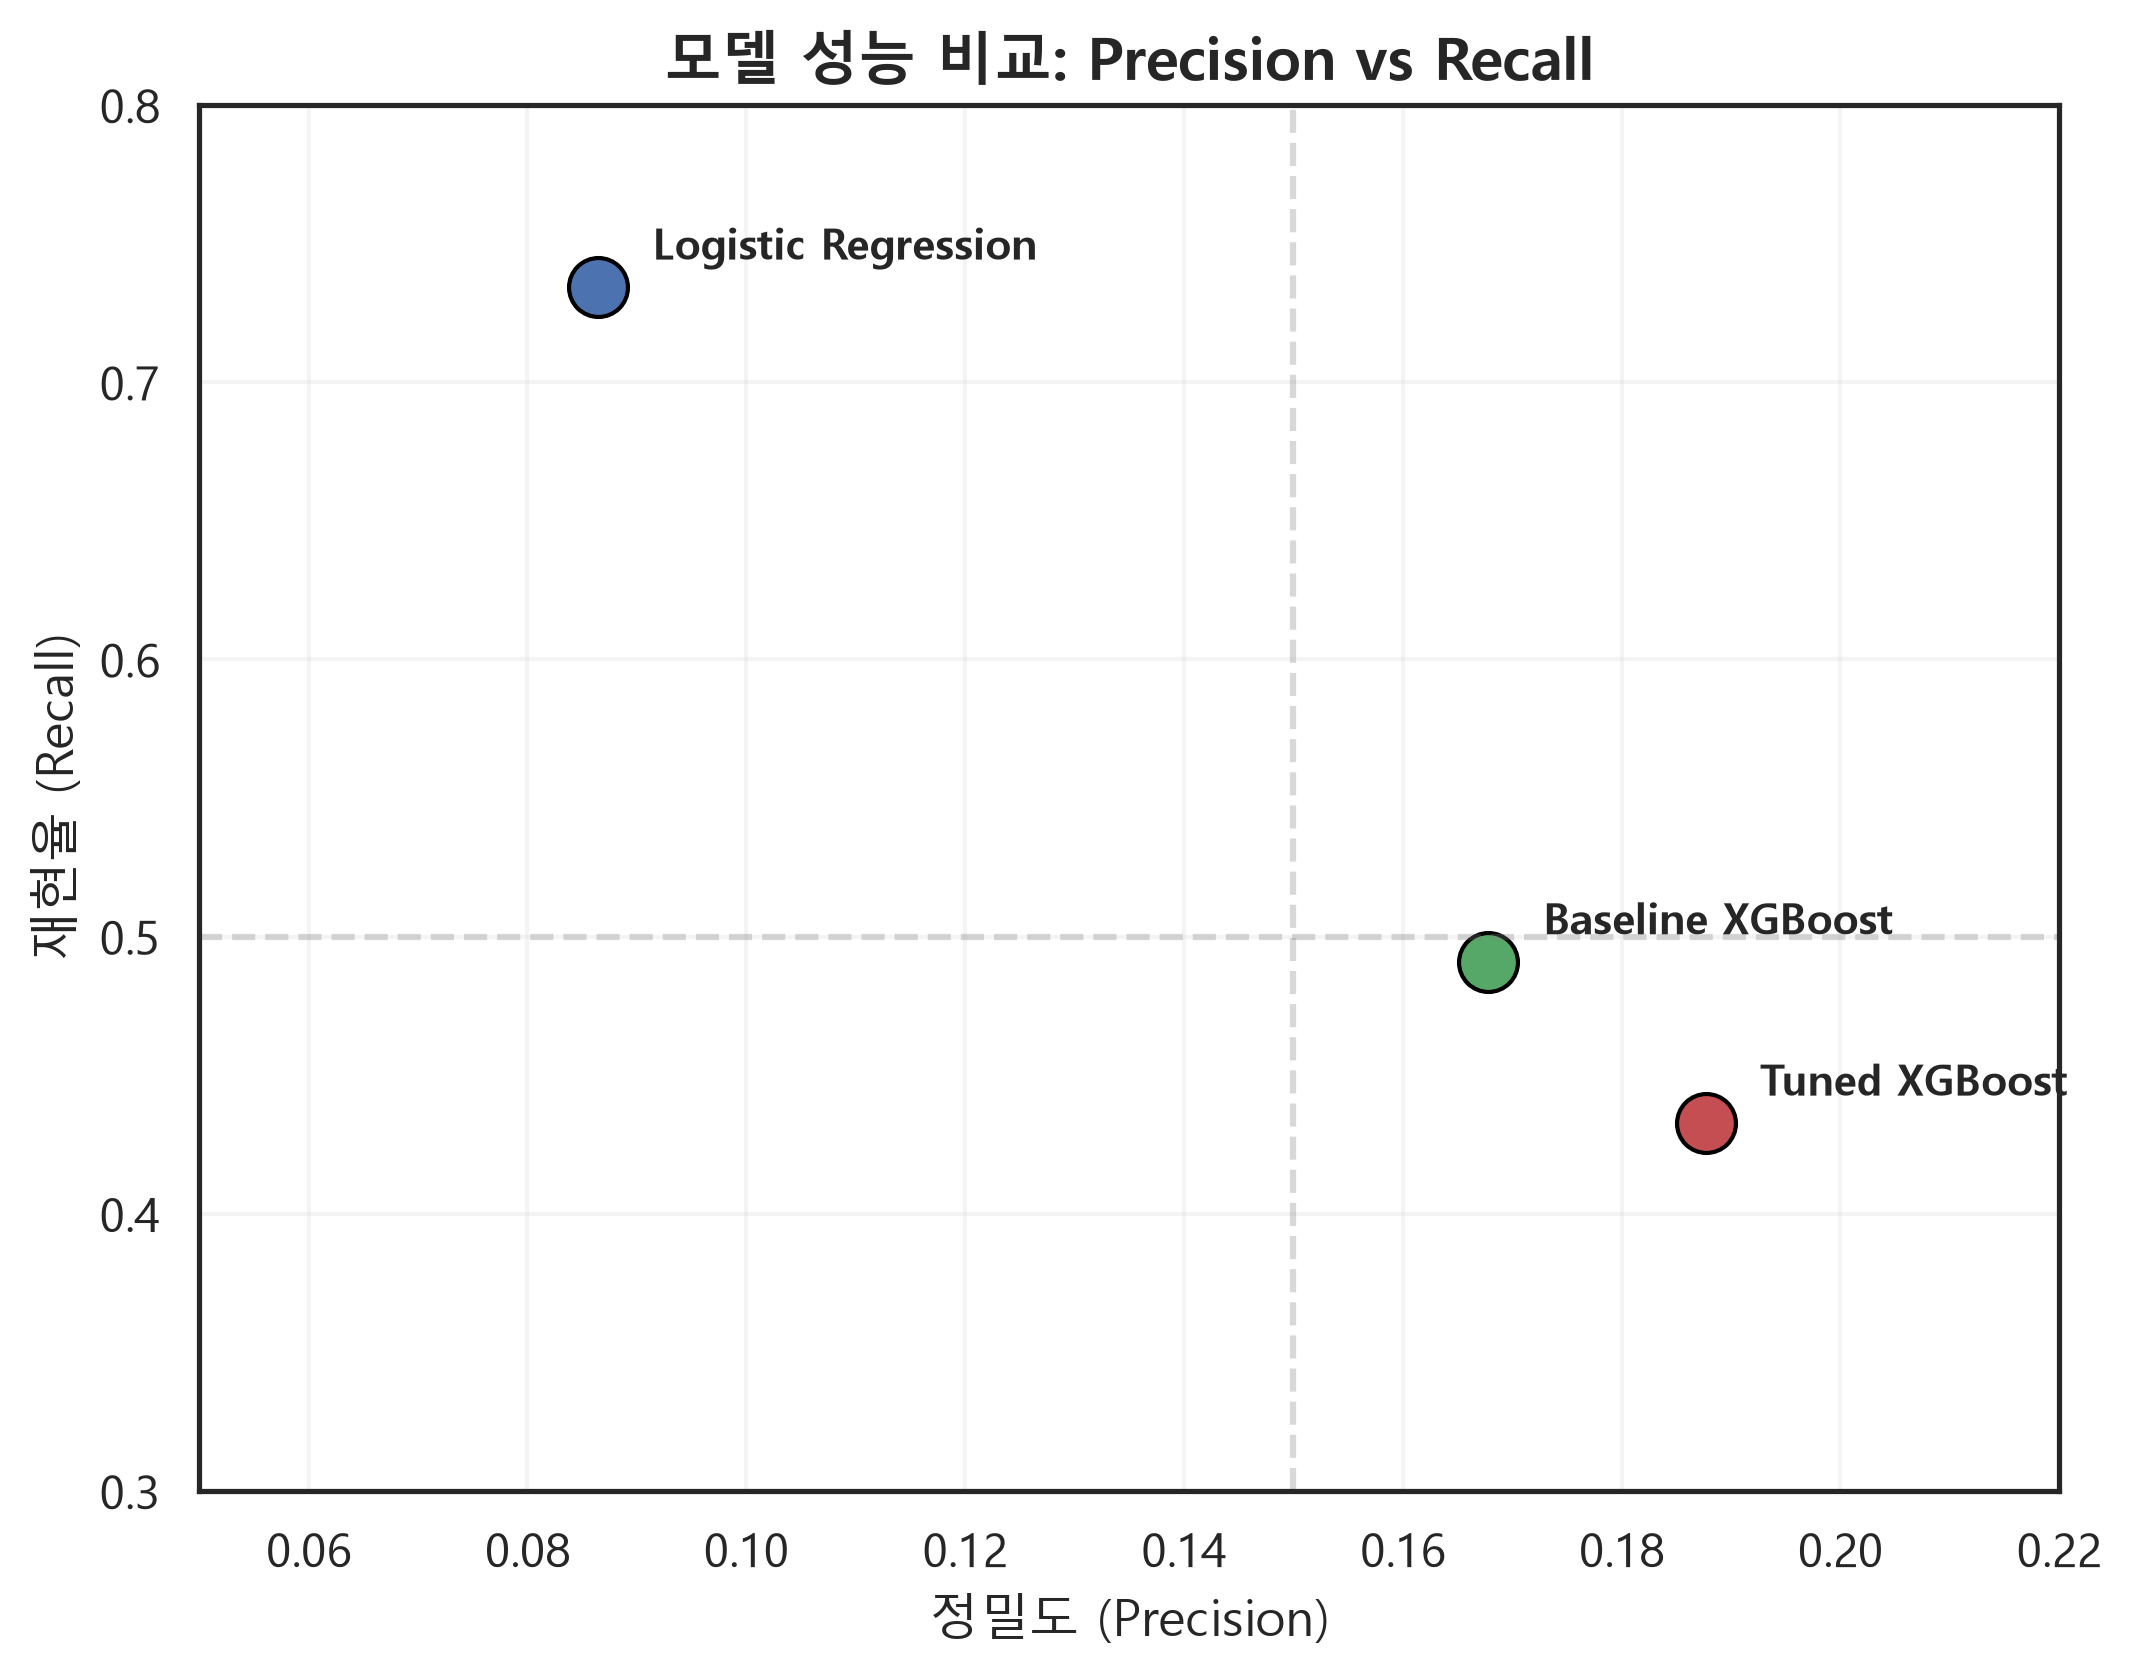

In [224]:
import matplotlib.pyplot as plt
import os

# 데이터 정의
models = ['Logistic Regression', 'Baseline XGBoost', 'Tuned XGBoost']
precisions = [0.0864, 0.1678, 0.1877]
recalls = [0.7342, 0.4908, 0.4326]

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# 산점도 그리기
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, model in enumerate(models):
    ax.scatter(precisions[i], recalls[i], s=200, label=model, color=colors[i], edgecolors='black')
    ax.text(precisions[i]+0.005, recalls[i]+0.01, model, fontsize=10, fontweight='bold')

# 가이드라인 (중앙값 기준)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0.15, color='gray', linestyle='--', alpha=0.3)

# 레이블 및 꾸미기
ax.set_title('모델 성능 비교: Precision vs Recall', fontsize=14, fontweight='bold')
ax.set_xlabel('정밀도 (Precision)', fontsize=12)
ax.set_ylabel('재현율 (Recall)', fontsize=12)
ax.grid(alpha=0.2)
ax.set_xlim([0.05, 0.22])
ax.set_ylim([0.3, 0.8])

# 저장
plt.savefig('figures/model_precision_recall_scatter.png', bbox_inches='tight', dpi=300)
plt.show()